# Capture-Rate Put — Contract Design, Pricing and Equilibrium

Stage 4, step 3. Designs a monthly capture-rate put for the Bologna reference
plant, prices it on the simulated paths, backtests it on history, and then prices
it again as a three-agent market equilibrium.

## Objective
Answer whether a producer exposed to solar cannibalisation can hedge it with a
traded claim, and at what price.

The notebook is in two parts:

- **Part I — actuarial.** The contract pays `max(K_y - CR_m, 0)` on a monthly
  settlement index, with an annual strike schedule struck off the forward capture
  rate. Priced at expectation, applied to the plant's revenue, and assessed on
  variance reduction, tail risk and drawdown.
- **Part II — equilibrium.** The same claim priced by market clearing between
  three agents with different risk aversion, following Lee and Oren (2009). The
  actuarial premium is the zero-risk-aversion limit of that price, so the gap
  between them is the risk premium the market charges.

## Pipeline Position

| Inputs | This notebook | Outputs |
|---|---|---|
| `Data/Simulated/mc_physical_variables_{pen}.parquet` | Settlement index -> strike schedule -> premium -> hedged revenue -> risk metrics -> equilibrium price | `Data/Results/_hedge_checkpoint.pkl` (Part I -> Part II handoff) |
| `Data/Results/ri_annual_results_multiscenario.parquet` | | |
| `Data/Results/ri_annual_results_hist.parquet` | | |
| `Data/Modelled/df_{cr,solar,temperature}_modelled.parquet` | | |
| `Data/Cleaned/df_energy_cleaned.parquet` (GME prices) | | |
| `Code/Models/Temperature/noct_uplift_params.pkl` | | |

## Decision Log

| # | Decision | Alternatives | Rationale | Impact |
|---|---|---|---|---|
| D-N1 | Notional is **seasonally shaped** to the P50 irradiance profile | A flat monthly volume carrying the same annual total | The capture rate is seasonally lowest in winter, so a flat notional buys the most protection in the months that produce least and the least in the high-exposure summer months | Reported as an explicit comparison below, not asserted: the flat shape costs materially more premium for slightly *less* variance reduction. The two are volume-neutral by construction, so the comparison isolates shape |
| D-N2 | Strike is a **forward-struck annual schedule**, `K_y = 0.95 * F_y` | One fixed strike; a trailing schedule struck off realised history | `F_y` is the deterministic conditional mean of the capture-rate model, knowable at trade date and independent of the realised paths. A schedule holds `K/F` constant at 0.95 in every year | A single strike drifts into the money as the forward declines, so premiums are not comparable across the horizon. A trailing strike insures a different product: seasonal and stochastic shortfall, but not the cannibalisation trend |
| D-N3 | `P_FIXED_EUR = 110 EUR/MWh` for 2026-2050 | A forward curve, or an inflation path | No forward curve beyond a few years exists for the NORD zone, and inventing a path would add an assumption the study cannot support | The same weakness as the revenue index's price assumption. Every EUR level scales linearly in it; every *ratio* metric (variance reduction, correlation, effectiveness) is invariant to it |
| D-N4 | Settlement index is a **production-weighted** monthly capture rate, with weights from **irradiance alone** | An equal-weighted mean of daily ratios; weights from full production | A capture rate is a ratio of sums over the settlement period, not a mean of daily ratios: low-CR days are high-production days, which is what cannibalisation *is*, so equal weighting under-weights exactly the days that carry the economics. Irradiance weights keep the index independently verifiable, where production weights would embed plant-specific technology and the temperature scenario, so two counterparties would compute different index values from identical weather | The residual gap between irradiance and production weighting is the `f_temp` factor, about 0.0001, roughly 3% of the correction that weighting makes in the first place. It is accepted, measured basis |
| D-N5 | Plant size and contract size are separate constants (`PLANT_MW`, `LOT_MW`) | One size for both | The producer's decision variable is the hedge *quantity*, not the contract size. Holding them equal made the two impossible to vary independently | Every per-kWp and percentage result is scale-invariant; only euro levels move. In Part II the ratio matters, because risk aversion is in absolute inverse-M€ |
| D-N6 | Premiums are cross-fitted across `N_PRICE_FOLDS` folds | Price and evaluate on the same paths | Pricing and evaluating on one set of paths understates premium-estimation risk | With equal folds the mean out-of-sample net P&L is still zero by symmetry, so the *mean* cannot expose this; the dispersion can, and is reported as a bootstrap standard error |
| D-N7 | Every tail statistic is paired with a **paired bootstrap** interval | Point estimates | VaR95 is interpolated between two order statistics and CVaR95 averages only the roughly 5% of paths below it, so both carry far more sampling error than a point estimate suggests | Bootstraps resample paths, and hedged and unhedged are always resampled with the same indices because they share common random numbers |

## Setup and Contract Terms

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path
import warnings
import sys
import calendar
import gc
import pickle


sys.path.append(str(Path("..").resolve()))
from model_utils import find_project_root, G_STC, T_STC, GAMMA, PR

BASE = find_project_root()
sys.path.append(str(BASE / "Code"))
import risk_metrics as rm

# ── Strike rule (D-N2) ────────────────────────────────────────────────────────
# A single constant strike cannot work against an underlying that trends from
# ~0.93 to ~0.66: K=0.75 never once triggered in 252 months of history, yet is in
# the money ~12/12 months by 2040. Moneyness must therefore be re-based over the
# tenor, and the question is what it is re-based ON.
#
# FORWARD-STRUCK (the active rule). The contract carries an ANNUAL STRIKE
# SCHEDULE fixed at trade date:
#
#     K_y = FWD_MULT * F_y ,   F_y = irradiance-weighted mean of mu_CR over year y
#
# F_y is the forward capture rate for the agreed penetration scenario -- the
# deterministic conditional mean of the CR model, knowable at inception and
# independent of which path realises. A schedule rather than one flat strike is
# what holds moneyness constant: a single strike over a multi-year tenor drifts
# into the money as the forward declines (measured: K/F 0.939 -> 0.963 across one
# 3-year block, premium up 7x). With K_y = m*F_y, K/F is exactly m in every year,
# so premiums and risk loadings are comparable across the horizon. Multi-year
# PPAs already carry escalator schedules; this is the same device.
#
# The two TRAILING rules are retained as comparison cases, not as candidates.
# Both re-strike on realised history, which changes what is insured: a strike
# tracking last year's realised CR no longer covers the cannibalisation TREND,
# because a plant sliding steadily downward re-strikes lower every year and is
# never paid for the slide. What remains covered is the deviation of a month from
# its own recent level, i.e. seasonal and stochastic shortfall. That is a
# different product, and its premium is correspondingly lower.
STRIKE_RULE    = "forward"   # "forward" | "rolling" | "fixed"
assert STRIKE_RULE in {"forward", "rolling", "fixed"}, f"unknown STRIKE_RULE: {STRIKE_RULE!r}"
FWD_MULT       = 0.95        # forward-struck moneyness K/F
ROLL_MULT      = 0.90        # trailing rules only, kept for comparison
LOOKBACK_YEARS = 1
RESET_YEARS    = 1

K_CR         = 0.75   # incumbent fixed strike — retained as the Step 9 baseline
ROLL_MONTHS  = 36
TARGET_YEARS = [2030, 2040, 2050]

# ── Scenarios ─────────────────────────────────────────────────────────────────
# Same triples the multi-scenario revenue notebook uses. NOTE: CR_sim depends only
# on the PENETRATION axis, so every hedge-payoff difference across these scenarios
# is cannibalisation-driven; the temperature axis moves revenue alone.
SCENARIOS = {
    "Best case":  ("current_trend", "ssp126"),
    "Baseline":   ("pniec",         "baseline"),
    "Worst case": ("entso_e",       "ssp585"),
}
BASE_PEN, BASE_TEMP = SCENARIOS["Baseline"]
SCENARIOS_LABEL_BASE = "Baseline"


def sim_file_for(pen):
    return BASE / f"Data/Simulated/mc_physical_variables_{pen}.parquet"


# The seasonal notional is a CONTRACT TERM fixed at inception, so it is built once
# from the baseline scenario and held across scenarios by design (GHI does not vary
# with the penetration axis in any case).
SIM_FILE  = sim_file_for(BASE_PEN)
RI_FILE   = BASE / "Data/Results/ri_annual_results_multiscenario.parquet"
CR_HIST   = BASE / "Data/Modelled/df_cr_modelled.parquet"
SOLAR_HIST = BASE / "Data/Modelled/df_solar_modelled.parquet"
TEMP_HIST  = BASE / "Data/Modelled/df_temperature_modeled.parquet"
NOCT_FILE  = BASE / "Code/Models/Temperature/noct_uplift_params.pkl"
RI_HIST   = BASE / "Data/Results/ri_annual_results_hist.parquet"
GME_FILE  = BASE / "Data/Cleaned/df_energy_cleaned.parquet"

# Figure output, defined with every other path rather than re-derived
# cwd-relative ninety lines further down -- the precise failure the
# project-root finder exists to prevent.
out_dir   = BASE / "Data/Results"
out_dir.mkdir(parents=True, exist_ok=True)

# ── Settlement index: how the monthly capture rate is aggregated ──────────────
# A capture rate is a RATIO OF SUMS over the settlement period, not a mean of
# daily ratios. The two differ systematically: low-CR days are high-production
# days — that is what cannibalisation is — so equal weighting under-weights
# exactly the days that carry the economics.
#
# It also matters for basis: RI_annual is built from the daily product P(t)·CR(t)
# and is therefore already output-weighted. Settling on an EQUAL-weighted index
# would mean hedging one quantity with a claim written on a different one — a
# definitional basis risk on top of the index-vs-plant wedge. Weighting by
# irradiance closes most of that gap while keeping the index objective; the small
# remainder (the f_temp factor) is genuine, accepted basis, quantified in Step 9b.
#
# "equal" is retained so that definitional basis can be quantified as a
# sensitivity rather than merely asserted.
CR_WEIGHTING = "weighted"   # "weighted" | "equal"

# Which quantity supplies the weights. This is a CONTRACT DESIGN choice, not a
# modelling convenience:
#   "ghi"        — irradiance only. Observable, publishable, technology-agnostic,
#                  and identical across every penetration and temperature
#                  scenario, because those axes move CR and T but never GHI.
#   "production" — GHI x f_temp x PR. Aligns marginally better with revenue, but
#                  embeds plant-specific technology (gamma, PR, NOCT) AND the
#                  temperature scenario, so two counterparties would compute
#                  different index values from identical weather.
#
# A settlement index must be independently verifiable, so "ghi" is used. The cost
# is small and measured: the two differ by ~0.0001, about 3% of the correction
# that equal-vs-weighted makes in the first place. Since G_STC and PR are
# constants they cancel in any weighted mean, so the ONLY difference between the
# two bases is the f_temp factor.
CR_WEIGHT_BASIS = "ghi"   # "ghi" | "production"

# Physical constants for the production weights come from model_utils, the same
# source 03_revenue_index_historical and 04_revenue_index_scenarios use, so the
# settlement weights and the exposure they hedge are derived identically. They
# were re-declared here, which is how a third value of GAMMA entered the repo.

with open(NOCT_FILE, "rb") as _f:
    _noct = pickle.load(_f)
uplift_by_doy = _noct["uplift_by_doy"]
_uplift_mean  = float(np.mean(list(uplift_by_doy.values())))

# ── Notional parameters ───────────────────────────────────────────────────────
# PLANT_MW is the physical asset and sets the REVENUE basis. LOT_MW is the
# contract denomination and sets the NOTIONAL basis. They were the same number
# before, which made the contract size and the asset size impossible to vary
# independently — and hid the fact that the hedge quantity, not the contract
# size, is the producer's actual decision variable.
#
# 20 MW is a medium utility-scale plant for the Bologna / NORD zone, where the
# Po valley's land constraints make the 100 MW+ projects seen in the south
# unrepresentative. Every per-kWp and percentage result is scale-invariant, so
# this changes euro amounts only — except in Part II, where risk aversion is in
# absolute M€^-1 and the SPP's book size relative to the ESO's is meaningful.
PLANT_MW       = 20       # MW — physical plant (revenue basis)
LOT_MW         = 1        # MW — one contract; quantity is the decision variable
NOTIONAL_MW    = LOT_MW   # the notional schedule is priced PER LOT
# Every EUR figure downstream is either PER LOT (NOTIONAL_MW=LOT_MW basis --
# e.g. the Part II Gamma_I / mom / eq objects) or for the FULL N_CONTRACTS_CAP
# position (step5_apply_hedge and everything built on ri_sim). Anything labelled
# in MW must name PLANT_MW or N_CONTRACTS_CAP*LOT_MW -- NEVER NOTIONAL_MW, which
# is one lot and was the source of a 20x scale bug in three cells before this fix.
# PR comes from model_utils alongside GAMMA/G_STC/T_STC (D-N5).
P_FIXED_EUR    = 110.0    # EUR/MWh — forward price assumption 2026–2050 (D-N3)
NOTIONAL_SWEEP = [10, 20, 50, 100]    # MW of PLANT — sensitivity analysis

# A full hedge is one lot per MW of plant. Lender and treasury policy normally
# caps hedging at 100% of physical exposure, so this is the practical maximum
# even though the variance-minimising count sits ~20% above it.
N_CONTRACTS_CAP = int(PLANT_MW / LOT_MW)     # 20 lots = 100% of exposure

# ── EUR basis ─────────────────────────────────────────────────────────────────
# RI_annual has units [kWh/kWp · CR] (see Simulation/revenue_index.ipynb) — it is
# an energy-yield index, NOT a price. Converting it to money therefore needs a
# capacity and a price, not an energy notional:
#     revenue [EUR] = RI_annual [kWh/kWp·CR] × CAPACITY_KWP [kWp] / 1000 × P_REF [EUR/MWh]
# Multiplying RI_annual by N_MWh_annual instead is dimensionally
# energy×energy with no price, and overstates revenue ~10.9×.
CAPACITY_KWP = PLANT_MW * 1000           # revenue follows the PLANT, not the lot
P_REF        = P_FIXED_EUR               # EUR/MWh reference price
REV_PER_RI   = CAPACITY_KWP / 1000 * P_REF   # EUR per unit of RI_annual

# ── Discounting ───────────────────────────────────────────────────────────────
# What is being valued here is a strip of HEDGE cash flows, not the equity of the
# project, so they are discounted at a risk-free EUR rate rather than a project
# WACC. Premiums grow ~1,500x from 2026 to 2050, so leaving the horizon
# undiscounted materially overstates late-horizon hedge value.
# NOTE: Part II's B1 = exp(r_b) with r_b = 0.03 is a separate object -- the euro
# riskless carry rate inside the equilibrium pricing relation, not a project cost
# of capital (see Part II, block 3). It differs from R_FREE=0.025 above because the
# two serve different purposes: R_FREE discounts a strip of HEDGE cash flows here
# in Part I, while r_b is a common numeraire shared by all three Part II agents.
# The two-basis-point gap between them is immaterial to either result.
BASE_YEAR       = 2026
R_FREE          = 0.025                       # EUR risk-free, headline
DISCOUNT_RATES  = [0.0, 0.015, 0.025, 0.035]  # reported as a sensitivity

# ── Historical backtest ───────────────────────────────────────────────────────
# A rolling strike imposes TWO nested lookbacks on the backtest:
#   1. a strike for year Y needs LOOKBACK_YEARS of prior CR  -> strikes from 2008
#      (history begins 2005-01)
#   2. a rolling premium for year Y needs ROLL_MONTHS of prior PAYOFF, which in
#      turn needs strikes back to Y-3                        -> premiums from 2011
# So 2011 is the first year the backtest is fully defined. Under a fixed strike
# only (1) binds and 2008 would suffice; 2011 is used for both so the two strike
# rules are compared over an identical window.
BACKTEST_START  = 2011
BACKTEST_END    = 2025

# Cross-fitting folds for out-of-sample premium estimation (see step1c).
N_PRICE_FOLDS   = 2

# ── Sampling uncertainty ──────────────────────────────────────────────────────
# VaR95 is interpolated between two order statistics and CVaR95 averages only the
# ~5% of paths below it, so both carry far more sampling error than a point
# estimate suggests. Every tail statistic reported below is therefore paired with
# a bootstrap interval. Bootstraps resample PATHS, and hedged/unhedged are always
# resampled with the same indices (they share common random numbers).
N_BOOT      = 1000    # target-year tables
N_BOOT_TS   = 300     # 25-year time series (per year, per series)
BOOT_SEED   = 20260817

# ── Rehearsal knob ─────────────────────────────────────────────────────────
# None = all simulated paths (the only setting valid for publication). An int
# gives a low-memory rehearsal for CODE PATHS ONLY -- every number this notebook
# prints is a Monte Carlo estimate, so a rehearsal run's VALUES must never be
# quoted, only used to confirm the notebook executes cleanly end to end.
N_PATHS = None

# ── Notional shape (D-N1) ─────────────────────────────────────────────────────
# "seasonal": N_MWh(m) = NOTIONAL_MW x P50_GHI(m) x PR / 1000 -- the contracted
#             volume follows the P50 irradiance profile, so the hedge is weighted
#             to the months that actually produce.
# "flat"    : the SAME annual volume spread evenly across the twelve months.
#
# The switch is volume-neutral by construction (asserted below), so the two
# shapes are directly comparable: only the distribution changes, not the total.
#
# Headline results use "seasonal". "flat" is not an alternative design but the
# comparison case that demonstrates why energy contracts are seasonally shaped,
# and the two are reported side by side in the notional-shape comparison below
# rather than left as a claim in a comment. The mechanism: the capture rate is
# seasonally lowest in winter, so a flat notional buys more protection in the
# expensive, low-production months and less in the cheap, high-exposure summer
# ones.
NOTIONAL_SHAPE = "seasonal"   # "seasonal" | "flat"  -- headline basis
assert NOTIONAL_SHAPE in {"seasonal", "flat"}, \
    f"unknown NOTIONAL_SHAPE: {NOTIONAL_SHAPE!r}"

# guards against the two capacities being crossed — a single mis-assignment
# silently rescales one leg of the hedge and nothing else would catch it
assert np.isclose(REV_PER_RI, PLANT_MW * P_REF), \
    f"REV_PER_RI {REV_PER_RI} inconsistent with PLANT_MW {PLANT_MW}"
assert 0 < LOT_MW <= PLANT_MW, "lot larger than the plant"
assert N_CONTRACTS_CAP * LOT_MW == PLANT_MW, "contract cap is not 100% of plant"

def assert_brackets(name, grid, baseline, strict=True):
    """A one-at-a-time sensitivity sweep that does not contain its own baseline
    describes a parameter region the model no longer occupies. Call this on
    every grid at the point it is defined, not after the sweep runs.
    """
    lo, hi = min(grid), max(grid)
    assert lo <= baseline <= hi, (
        f"{name}: grid [{lo:g}, {hi:g}] does not bracket baseline {baseline:g}")
    if strict:
        assert lo < baseline < hi, (
            f"{name}: baseline {baseline:g} sits at a grid EDGE -- "
            f"the sweep is one-sided")


def one_row(df, **where):
    """Exactly-one-row lookup. Replaces bare .iloc[0], which silently returns a
    misleading singleton (or raises an opaque IndexError) on an empty frame --
    the failure mode that hit contour-2030-standalone when its reference point
    was not a node in the sweep grid."""
    m = df
    for k, v in where.items():
        m = m[np.isclose(m[k], v)] if isinstance(v, float) else m[m[k] == v]
    assert len(m) == 1, f"expected exactly 1 row for {where}, got {len(m)}"
    return m.iloc[0]


# ── N_PATHS row filter, applied to every SIM_FILE read in this notebook ──────
_sim_id_filter = None if N_PATHS is None else [("sim_id", "<", int(N_PATHS))]

_ghi         = pd.read_parquet(SIM_FILE, columns=["sim_id", "year", "month", "GHI_sim"],
                              filters=_sim_id_filter)
_monthly_ghi = _ghi.groupby(["sim_id", "year", "month"])["GHI_sim"].sum().reset_index()
_p50_ghi     = _monthly_ghi.groupby("month")["GHI_sim"].quantile(0.5)   # Wh/m2/month
del _ghi, _monthly_ghi


def notional_schedule(shape):
    """Monthly contracted volume, in MWh per LOT, for either notional shape.

    Both shapes carry the SAME annual volume; only its distribution across the
    twelve months differs. Returning them from one function is what lets the
    comparison below re-price the contract under each without duplicating the
    construction.
    """
    seasonal = _p50_ghi * PR / 1000 * NOTIONAL_MW     # MWh per calendar month
    if shape == "seasonal":
        out = seasonal
    elif shape == "flat":
        out = pd.Series(seasonal.sum() / 12, index=seasonal.index)
    else:
        raise ValueError(f"unknown NOTIONAL_SHAPE: {shape!r}")

    frame = out.rename("N_MWh").reset_index()
    assert np.isclose(frame["N_MWh"].sum(), seasonal.sum()), \
        "notional shape must be volume-neutral"
    if shape == "flat":
        assert frame["N_MWh"].nunique() == 1, "flat notional is not flat"
    return frame


NOTIONAL_SCHEDULES = {s: notional_schedule(s) for s in ("seasonal", "flat")}
n_mwh_by_month = NOTIONAL_SCHEDULES[NOTIONAL_SHAPE]

_n_total = n_mwh_by_month["N_MWh"].sum()
cf_check = _n_total / (NOTIONAL_MW * 8760)
print(f"Monthly notional N_MWh @ {NOTIONAL_MW} MW, PR={PR}, shape={NOTIONAL_SHAPE}:")
print(n_mwh_by_month.to_string(index=False, float_format="{:.0f}".format))
print(f"\nAnnual total {_n_total:,.0f} MWh   |   implied capacity factor {cf_check:.1%}")
print(f"Both shapes built and volume-matched: "
      f"{ {s: round(f['N_MWh'].sum(), 1) for s, f in NOTIONAL_SCHEDULES.items()} }")

Monthly notional N_MWh @ 1 MW, PR=0.8, shape=seasonal:
 month  N_MWh
     1     38
     2     56
     3     95
     4    122
     5    148
     6    166
     7    173
     8    151
     9    109
    10     70
    11     41
    12     34

Annual total 1,203 MWh   |   implied capacity factor 13.7%
Both shapes built and volume-matched: {'seasonal': np.float64(1202.8), 'flat': np.float64(1202.8)}


### Strike schedules and hedge application

The contract's strike is a **schedule**, not a constant. These helpers build it and
apply it, and everything downstream — premiums, backtest, hedged revenue, Part II's
`Gamma_I` — consumes them, so Part I and Part II cannot end up pricing different
contracts.

The defining constraint is **no look-ahead**: each block's strike may only use data
from years strictly before that block. This is asserted during construction, not
merely assumed, because the constraint is easy to violate silently -- for instance
by taking the median CR of the *same* simulated year, which is unobservable at
inception.

In [2]:
def daily_production(ghi, t_amb, doy):
    """Daily energy yield per kWp: Q = (GHI/G_STC)·f_temp·PR,
    f_temp = 1 + γ(T_eff − T_STC), T_eff = T_amb + uplift(doy).

    This is the plant's OUTPUT. It is the right quantity for revenue, but not
    for a settlement index — see settlement_weight.
    """
    # float32: this runs over the full 45M-row simulation table, and every
    # intermediate here is a second full-length array -- float64 doubles the
    # working set for no precision this settlement index needs.
    ghi = np.asarray(ghi, dtype=np.float32)
    t_amb = np.asarray(t_amb, dtype=np.float32)
    uplift = pd.Series(doy).map(uplift_by_doy).fillna(_uplift_mean).to_numpy().astype(np.float32)
    f_temp = 1.0 + GAMMA * ((t_amb + uplift) - T_STC)
    return np.clip((ghi / G_STC) * f_temp * PR, 0.0, None)


# D-N4: production-weighted settlement index, weights from irradiance alone.
def settlement_weight(ghi, t_amb=None, doy=None, basis=None):
    """Weights for aggregating daily CR into the monthly settlement index.

    Defaults to irradiance. A settlement index has to be computable by any party
    from published data: weighting by plant OUTPUT would embed this installation's
    technology (gamma, PR, NOCT) and the assumed temperature scenario in a
    contract term, so two counterparties would derive different index values from
    the same realised weather. Irradiance is observable, technology-agnostic and
    invariant across every scenario in this study.

    Any positive scaling of the weights cancels in a weighted mean, so raw GHI is
    returned rather than a normalised resource measure.
    """
    basis = CR_WEIGHT_BASIS if basis is None else basis
    if basis == "ghi":
        return np.clip(np.asarray(ghi, dtype=np.float32), 0.0, None)
    if basis == "production":
        if t_amb is None or doy is None:
            raise ValueError("production basis needs t_amb and doy")
        return daily_production(ghi, t_amb, doy)
    raise ValueError(f"unknown CR_WEIGHT_BASIS: {basis!r}")


def rolling_strike_schedule(cr_monthly, cr_h_m, mult=None,
                            lookback=LOOKBACK_YEARS, reset=RESET_YEARS,
                            path_dependent=True):
    """Forward strike per (sim_id, year): reset every `reset` years to
    `mult` x the mean CR of the preceding `lookback` years.

    path_dependent=True  : each path resets off its OWN realised trailing CR, as a
                           contract indexed to a published series would.
    path_dependent=False : one deterministic schedule from the expected CR path.

    The first block is seeded from OBSERVED history (cr_h_m) — genuinely available
    when the contract is struck.
    """
    mult = ROLL_MULT if mult is None else mult
    ann_sim = (cr_monthly.groupby(["sim_id", "year"])["CR_monthly"].mean()
                         .unstack("year").sort_index(axis=1))
    ann_hist = cr_h_m.groupby("year")["CR_hist_m"].mean()

    years = list(ann_sim.columns)
    blocks = list(range(int(min(years)), int(max(years)) + 1, reset))
    sim_ids = ann_sim.index.to_numpy()
    n = len(sim_ids)

    block_strike = {}
    for b in blocks:
        window = list(range(b - lookback, b))
        assert all(y < b for y in window), f"look-ahead in block {b}: {window}"
        hist_years = [y for y in window if y in ann_hist.index]
        sim_years = [y for y in window if y in ann_sim.columns]
        assert hist_years or sim_years, f"no data in window {window} for block {b}"

        hist_vals = np.array([ann_hist[y] for y in hist_years], dtype=float)
        if path_dependent and sim_years:
            vals = ann_sim[sim_years].to_numpy()
            if hist_years:
                vals = np.concatenate([np.tile(hist_vals, (n, 1)), vals], axis=1)
            k_arr = vals.mean(axis=1)
        else:
            pooled = list(hist_vals) + [float(ann_sim[y].mean()) for y in sim_years]
            k_arr = np.full(n, float(np.mean(pooled)))
        block_strike[b] = mult * k_arr

    def block_of(y):
        return max(b for b in blocks if b <= y)

    return pd.concat(
        [pd.DataFrame({"sim_id": sim_ids, "year": int(y), "K": block_strike[block_of(int(y))]})
         for y in years],
        ignore_index=True)


def historical_strike_schedule(cr_h_m, mult=None, lookback=LOOKBACK_YEARS,
                               reset=RESET_YEARS, start=None, end=BACKTEST_END):
    """Backtest strike per year, from observed history only — same block rule.

    `start` defaults to the EARLIEST year a strike can be set (first year of
    history + lookback), which is earlier than BACKTEST_START: the premium window
    needs payoffs — hence strikes — from before the first backtested year.
    """
    mult = ROLL_MULT if mult is None else mult
    ann = cr_h_m.groupby("year")["CR_hist_m"].mean()
    if start is None:
        start = int(ann.index.min()) + lookback
    rows = []
    for b in range(start, end + 1, reset):
        window = list(range(b - lookback, b))
        assert all(y < b for y in window), f"look-ahead in block {b}"
        avail = [y for y in window if y in ann.index]
        assert avail, f"no history in window {window} for block {b}"
        k = mult * float(ann.loc[avail].mean())
        for y in range(b, min(b + reset, end + 1)):
            rows.append({"year": y, "K": k})
    return pd.DataFrame(rows)


# ── Forward-struck schedule ───────────────────────────────────────────────────
def forward_curve(pen=None, weight="ghi"):
    """F_y: the forward capture rate per year for a penetration scenario.

    Built from mu_CR_sim — the DETERMINISTIC conditional mean of the CR model —
    weighted by irradiance, so it is a contract term knowable at trade date and
    independent of which path realises. Read straight from the scenario parquet
    rather than from cr_monthly, because the strike must NOT depend on the
    simulated paths the contract is then priced against.
    """
    pen = BASE_PEN if pen is None else pen
    cols = ["year", "mu_CR_sim", "GHI_sim"]
    # mu_CR_sim is identical across paths by construction, so the N_PATHS
    # filter changes nothing about the answer and avoids reading the full
    # 1.1 GB table -- without it the rehearsal knob was defeated here.
    df = pd.read_parquet(sim_file_for(pen), columns=cols,
                         filters=_sim_id_filter)
    w = np.clip(df["GHI_sim"].to_numpy(dtype=float), 0.0, None) if weight == "ghi" \
        else np.ones(len(df))
    df = df.assign(_w=w, _num=df["mu_CR_sim"].to_numpy(dtype=float) * w)
    g = df.groupby("year").agg(_num=("_num", "sum"), _w=("_w", "sum"))
    return (g["_num"] / g["_w"]).rename("F")


def forward_strike_schedule(mult=None, pen=None):
    """Annual strike schedule K_y = mult * F_y, fixed at trade date."""
    mult = FWD_MULT if mult is None else mult
    f = forward_curve(pen)
    return pd.DataFrame({"year": f.index.astype(int), "K": mult * f.to_numpy()})


def historical_forward_strike_schedule(mult=None, end=BACKTEST_END):
    """Backtest analogue: the same rule applied to the FITTED historical mean.

    The in-sample conditional mean is taken as capture_rate - CR_resid, which is
    its DEFINITION. CR_trend alone is only the exponential-decay component: it
    omits the Fourier and weekend terms that mu_CR_sim (and therefore the forward
    curve) includes, and no combination of the stored components reproduces the
    fitted mean to better than 0.03 CR. Using the residual identity keeps the
    backtest strike the same object as the forward strike.
    """
    mult = FWD_MULT if mult is None else mult
    tr = pd.read_parquet(CR_HIST, columns=["date", "year", "capture_rate", "CR_resid"])
    tr["date"] = pd.to_datetime(tr["date"])
    tr["CR_trend"] = tr["capture_rate"] - tr["CR_resid"]   # fitted conditional mean
    tr = tr.dropna(subset=["CR_trend"])
    sol = (pd.read_parquet(SOLAR_HIST, columns=["GHI_obs"])
             .reset_index().rename(columns={"index": "date"}))
    sol["date"] = pd.to_datetime(sol["date"])
    m = tr.merge(sol, on="date", how="left")
    assert not m["GHI_obs"].isna().any(), "historical GHI has gaps under the trend"
    w = np.clip(m["GHI_obs"].to_numpy(dtype=float), 0.0, None)
    m = m.assign(_w=w, _num=m["CR_trend"].to_numpy(dtype=float) * w)
    g = m.groupby("year").agg(_num=("_num", "sum"), _w=("_w", "sum"))
    f = (g["_num"] / g["_w"])
    f = f[f.index <= end]
    return pd.DataFrame({"year": f.index.astype(int), "K": mult * f.to_numpy()})


def default_forward_strike(cr_monthly, cr_h_m):
    """The notebook-wide forward strike, honouring STRIKE_RULE."""
    if STRIKE_RULE == "fixed":
        return float(K_CR)
    if STRIKE_RULE == "forward":
        return forward_strike_schedule()
    return rolling_strike_schedule(cr_monthly, cr_h_m)


def default_historical_strike(cr_h_m):
    """The notebook-wide backtest strike, honouring STRIKE_RULE."""
    if STRIKE_RULE == "fixed":
        return float(K_CR)
    if STRIKE_RULE == "forward":
        return historical_forward_strike_schedule()
    return historical_strike_schedule(cr_h_m)


def strike_vector(frame, strike, keys=("sim_id", "year"), require_complete=True):
    """Broadcast `strike` (scalar or schedule frame) onto `frame`'s rows.

    require_complete=True asserts every row got a strike. Set it False only where
    partial coverage is expected and the caller drops the uncovered rows itself —
    a silent NaN strike would otherwise become a silent zero payoff.
    """
    if not isinstance(strike, pd.DataFrame):
        return np.full(len(frame), float(strike)), frame
    on = [k for k in keys if k in strike.columns and k in frame.columns]
    assert on, f"cannot align strike schedule on {keys}"
    frame = frame.drop(columns=["K"], errors="ignore")   # tolerate a re-run
    merged = frame.merge(strike, on=on, how="left")
    kv = merged["K"].to_numpy()
    if require_complete:
        n_gap = int(np.isnan(kv).sum())
        assert n_gap == 0, (
            f"strike schedule has gaps: {n_gap} of {len(kv)} rows have no strike "
            f"(schedule covers {sorted(strike[on[0]].unique())[:3]}...)")
    return kv, merged


def _hedge_at_strike(cr_monthly, ri_sim, n_mwh_by_month, strike, p_fixed=P_FIXED_EUR):
    """Hedged revenue for a strike: scalar, or a (sim_id, year, K) frame."""
    base = cr_monthly.merge(n_mwh_by_month, on="month", how="left")
    k_vec, base = strike_vector(base, strike)

    payoff = np.clip(k_vec - base["CR_monthly"].to_numpy(), 0, None)
    base = base.assign(payoff_eur=payoff * base["N_MWh"].to_numpy() * p_fixed)

    ann = (base.groupby(["sim_id", "year"])["payoff_eur"].sum()
               .rename("payoff_eur").reset_index())
    # Cross-path mean payoff = the fair (unconditional) premium. With a path-dependent
    # strike a market would quote CONDITIONAL on the trailing CR observed at reset, so
    # this is approximate; the deterministic-schedule variant in Step 9 has no such
    # issue and is reported there as the consistency check.
    prem = ann.groupby("year")["payoff_eur"].mean().rename("prem_eur")
    ann = ann.merge(prem, on="year")
    ann["net_eur"] = ann["payoff_eur"] - ann["prem_eur"]

    m = ri_sim[["sim_id", "year", "rev_unhedged_eur"]].merge(ann, on=["sim_id", "year"])
    m["rev_hedged"] = m["rev_unhedged_eur"] + m["net_eur"] / 1e6
    return m


def _row_metrics(m, label, year):
    """One scored row for a hedge design — used by every strike comparison."""
    s = m[m["year"] == year]
    rev = s["rev_unhedged_eur"].to_numpy()
    pay = (s["payoff_eur"] / 1e6).to_numpy()
    mv = rm.min_variance_hedge(rev, pay)
    return {"rule": label, "year": year,
            "premium_EUR": float(s["prem_eur"].iloc[0]),
            "prem_pct_rev": float(s["prem_eur"].iloc[0] / 1e6 / rev.mean() * 100),
            "P_exercise": float((s["payoff_eur"] > 0).mean()),
            "var_red": rm.variance_reduction(rev, s["rev_hedged"]),
            "ceiling": mv["max_var_red"], "h_star": mv["h_star"]}


def strike_description(short=False):
    """The ACTIVE strike rule, rendered once. Every figure/print in this notebook
    that names the strike routes through here so a new STRIKE_RULE can never fall
    through to a stale description -- which is exactly how five separate cells
    came to caption the forward-indexed contract as a constant K=0.75 fixed
    strike, or a rolling reset, after STRIKE_RULE was switched to "forward"."""
    if STRIKE_RULE == "forward":
        return (f"K={FWD_MULT:.2f}xF" if short else
                f"K_y = {FWD_MULT:.2f} x forward CR F_y "
                f"(annual schedule fixed at trade date)")
    if STRIKE_RULE == "rolling":
        return (f"K={ROLL_MULT:.2f}x trailing" if short else
                f"K = {ROLL_MULT:.2f} x mean CR of the prior {LOOKBACK_YEARS}y, "
                f"reset every {RESET_YEARS}y")
    if STRIKE_RULE == "fixed":
        return (f"K={K_CR:.2f}" if short else f"K = {K_CR:.2f} (constant)")
    raise ValueError(f"unknown STRIKE_RULE: {STRIKE_RULE!r}")


def strike_regime_note():
    """One clause on what the active rule does to moneyness over the horizon."""
    return {"forward": "a constant K/F holds moneyness flat across the horizon",
            "rolling": "resetting the strike keeps it an option throughout",
            "fixed":   "a fixed strike drifts into a swap"}[STRIKE_RULE]


print(f"Strike rule: {STRIKE_RULE}  |  {strike_description()}")

Strike rule: forward  |  K_y = 0.95 x forward CR F_y (annual schedule fixed at trade date)


In [3]:
# ── Part II: Lee & Oren equilibrium parameters ───────────────────────────────
# All monetary quantities in Part II are expressed in M€.
# Risk aversion coefficients are in M€⁻¹ units.
# NOTE: these are ASSUMED, not calibrated, and they are ABSOLUTE coefficients in
# a mean-variance (CARA) certainty equivalent CE = mu - (v/2)*sigma^2. Two
# consequences follow and both must be stated when the loading is reported:
#
#   1. RELATIVE risk aversion is RRA = v * E[I]. At v = 2.0 and a 20 MW plant
#      earning ~2.2 M€/yr, RRA ~= 4.4 — a sensibly risk-averse producer. The
#      earlier v = 0.5 gave RRA ~= 1.1, i.e. near risk-neutral, which is why the
#      endogenous loading came out at only ~0.1%.
#
#   2. Because v is absolute while the covariances scale with each agent's book,
#      the LOADING IS NOT SCALE-FREE: the same v at a 100 MW plant produces a
#      ~5x larger loading. Every loading figure below is therefore specific to
#      PLANT_MW = 20 and must be quoted with it. Calibrating v_i = RRA/E[I_i]
#      would make the loading invariant to plant size (verified: identical to
#      three decimals from 10 to 100 MW) — that route was considered and not
#      taken, in favour of holding a single fixed coefficient for all agents.
#
# Assigning the same ABSOLUTE risk aversion to the SPP and to the much smaller
# ESO also makes the ESO less RELATIVELY risk averse; that remains a convenience
# assumption, revisited in the sensitivity work.
v_spp         = 2.0     # SPP risk aversion  (M€⁻¹)  — RRA ~= 4.4 at a 20 MW plant
v_eso         = 2.0     # ESO risk aversion  (M€⁻¹)
v_m           = 2.0     # issuer / desk risk aversion  (M€⁻¹)
# RISKLESS RATE, not the project cost of capital. B1 carries the cash premium
# from inception to settlement inside the pricing relation, and in a
# mean-variance equilibrium every agent borrows and lends at one common riskless
# rate. The risk adjustment here is carried explicitly by the covariance term —
# that is what the loading measures — so discounting the contract at the 7% WACC
# used for the revenue stream would double-count risk.
#
# 3% is a round euro riskless rate. Strictly the theoretical risk-free for a
# EUR contract is the ESTR/OIS curve (nearer 2-2.5%); Italian sovereign BTP
# yields sit higher (~3.5-4%) because they carry credit spread and are NOT
# risk-free in the pricing sense. 3% sits between the two. Verify the current
# level before quoting it in the text.
#
# Effect of moving 1% -> 3%: premium level -1.98%, horizon mean loading
# 1.21% -> 1.19%. The equilibrium result is robust to this assumption.
r_b           = 0.03    # euro riskless rate (annual, continuously compounded)
B1            = np.exp(r_b)          # one-YEAR carry; Part II moments are annual
H             = 1/v_spp + 1/v_eso + 1/v_m   # aggregate inverse risk aversion (M€)

eta_rt        = 0.88    # battery round-trip efficiency

# The ESO battery is now sized RELATIVE TO THE PLANT rather than fixed at an
# absolute 5,000 MWh/month. Holding it fixed while varying PLANT_MW silently
# changed the battery-to-solar ratio, and that — not economics — is what drove
# the equilibrium loading negative at small plant sizes: an 8x oversized
# counterparty becomes a natural seller large enough to pay the SPP to hedge.
# Tying it to the plant makes storage penetration an explicit market-structure
# assumption, and a proper sensitivity axis.
BATTERY_HOURS       = 4       # hours of storage at rated MW
CYCLES_PER_MONTH    = 30      # full cycles per month
CYCLES              = BATTERY_HOURS * CYCLES_PER_MONTH   # MWh per MW battery per month
# 0.20 rather than 0.40: Italian grid-scale storage is still small relative to
# the installed solar fleet, so 4 MW of battery against 20 MW of solar is closer
# to today than 8 MW is. The ratio is also the single most important structural
# parameter for the equilibrium — cov_eso offsets cov_spp exactly at a ratio
# computed per year as BATTERY_SOLAR_RATIO*(-cov_spp_W1/cov_eso_W1) (see the
# ratio-surface Plot B below), above which the battery fleet is a large enough
# natural seller that the loading turns NEGATIVE and solar producers are paid
# below actuarial to hedge.
BATTERY_SOLAR_RATIO = 0.20    # MW of battery per MW of solar
ESO_MW              = BATTERY_SOLAR_RATIO * PLANT_MW      # 4 MW at a 20 MW plant
ESO_MWh_month       = ESO_MW * CYCLES                     # 480 MWh/month

# Identity guards: catches whatever the NEXT reparameterisation breaks, the way
# this one broke (constants moved, everything downstream did not).
assert np.isclose(ESO_MW, BATTERY_SOLAR_RATIO * PLANT_MW)
assert np.isclose(ESO_MWh_month, ESO_MW * CYCLES)
assert np.isclose(CYCLES, BATTERY_HOURS * CYCLES_PER_MONTH)
assert np.isclose(H, 1/v_spp + 1/v_eso + 1/v_m)

print(f"B1 = {B1:.6f}  |  H = {H:.2f} M€")
print(f"eta_rt = {eta_rt}  |  ESO_MWh_month = {ESO_MWh_month:,}")

B1 = 1.030455  |  H = 1.50 M€
eta_rt = 0.88  |  ESO_MWh_month = 480.0


## Data Loading

In [4]:
def load_data(pen=BASE_PEN, temp=BASE_TEMP, need_sim=True):
    """Load one scenario. need_sim=False skips the 45.6M-row daily table.

    Only the baseline spine needs the daily table, for the settlement index and
    the monthly revenue index. The Step 10 scenario loop runs in a kernel that
    already holds the baseline results, where a second daily table does not fit;
    it takes its monthly index from monthly_cr_streamed() instead.
    """
    # N_PATHS row filter (see the data-loading cell): the parquet is sim-major, so a
    # sim_id row filter is a cheap prefix read rather than a full materialisation.
    _flt = None if N_PATHS is None else [("sim_id", "<", int(N_PATHS))]
    if need_sim:
        sim = pd.read_parquet(sim_file_for(pen),
                              columns=["sim_id", "date", "year", "month", "doy",
                                       "CR_sim", "GHI_sim", "T_sim"],
                              filters=_flt)
        sim["sim_id"] = sim["sim_id"].astype("int32")
        sim["year"] = sim["year"].astype("int16")
        sim["month"] = sim["month"].astype("int16")
        sim["doy"] = sim["doy"].astype("int16")
    else:
        sim = None

    ri = pd.read_parquet(RI_FILE)
    ri = ri[(ri["pen_scenario"] == pen) & (ri["temp_scenario"] == temp)].copy()
    assert len(ri), f"no rows for scenario ({pen}, {temp})"
    ri["sim_id"] = ri["sim_id"].astype("int32")
    if N_PATHS is not None:
        ri = ri[ri["sim_id"] < N_PATHS].copy()
    ri = ri[["sim_id", "year", "RI_annual", "CR_annual"]].copy()
    ri["PR_annual"] = ri["RI_annual"] / ri["CR_annual"]

    # Path-count guard (Stage 7): sim and ri must agree on which paths are present,
    # or every downstream merge silently drops the mismatched tail.
    if sim is not None:
        _n_sim, _n_ri = sim["sim_id"].nunique(), ri["sim_id"].nunique()
        assert _n_sim == _n_ri, f"sim ({_n_sim} paths) and ri ({_n_ri} paths) disagree"

    cr_h = pd.read_parquet(CR_HIST, columns=["date", "year", "month", "capture_rate",
                                             "capture_price", "market_price"])
    cr_h["date"]      = pd.to_datetime(cr_h["date"])
    cr_h["quarter"]   = ((cr_h["month"] - 1) // 3) + 1

    # Daily production weights for the historical record. Note the differing
    # layouts: df_solar_modelled carries the date on the index, df_temperature
    # carries it as a column.
    _sol = (pd.read_parquet(SOLAR_HIST, columns=["GHI_obs"])
              .reset_index().rename(columns={"index": "date"}))
    _tmp = pd.read_parquet(TEMP_HIST, columns=["date", "t2m_mean"])
    _sol["date"] = pd.to_datetime(_sol["date"])
    _tmp["date"] = pd.to_datetime(_tmp["date"])
    _n0 = len(cr_h)
    cr_h = cr_h.merge(_sol, on="date", how="left").merge(_tmp, on="date", how="left")
    assert len(cr_h) == _n0, "historical merge changed row count"
    assert not cr_h[["GHI_obs", "t2m_mean"]].isna().any().any(), (
        "historical GHI or temperature has gaps — production weights undefined")
    cr_h["Q"] = settlement_weight(cr_h["GHI_obs"], cr_h["t2m_mean"],
                                  cr_h["date"].dt.dayofyear)
    # NOTE: the payoff is no longer a fixed threshold — the strike is a schedule
    # (see the helpers cell), so payoffs are computed where the strike is known,
    # in Step 1 onward, rather than precomputed here against a constant K.

    # Monthly historical CR on the SAME basis the contract settles on.
    # The contract settles on a monthly-averaged CR, so the premium must be the
    # mean of max(0, K - CR_month), not the mean of max(0, K - CR_day). By
    # Jensen the daily version is strictly larger whenever within-month CR varies,
    # which is what made the old backtest show a positive premium against an
    # identically-zero payoff in every year.
    # Historical settlement index. Daily prices genuinely vary here, so the price
    # term does NOT cancel out of the ratio of sums and the exact form is used:
    #   CR_m = [Σ_d capture_price·Q / Σ_d Q] / mean_d(market_price)
    # Using production weights alone instead leaves a residual larger than the
    # correction it makes (measured: ~0.0137 mean absolute), which is why the
    # exact form is worth the extra two columns.
    if CR_WEIGHTING == "equal":
        cr_h_m = (cr_h.groupby(["year", "month"])["capture_rate"]
                      .mean().reset_index()
                      .rename(columns={"capture_rate": "CR_hist_m"}))
    else:
        _g = (cr_h.assign(_cpq=cr_h["capture_price"] * cr_h["Q"])
                  .groupby(["year", "month"])
                  .agg(_cpq=("_cpq", "sum"), _q=("Q", "sum"),
                       _pbar=("market_price", "mean"),
                       _equal=("capture_rate", "mean")))
        _g["CR_hist_m"] = _g["_cpq"] / _g["_q"] / _g["_pbar"]
        _dev = (_g["CR_hist_m"] - _g["_equal"])
        print(f"  historical index: {CR_WEIGHT_BASIS}-weighted (ratio of sums). "
              f"vs equal-weighted, mean {_dev.mean():+.4f}, "
              f"below in {(_dev < 0).mean():.1%} of months")
        cr_h_m = _g[["CR_hist_m"]].reset_index()
    cr_h_m["quarter"]      = ((cr_h_m["month"] - 1) // 3) + 1
    cr_h_m["date"]         = pd.to_datetime(
        dict(year=cr_h_m["year"], month=cr_h_m["month"], day=1))

    ri_h = pd.read_parquet(RI_HIST, columns=["year", "RI_annual", "CR_annual"])
    ri_h["PR_annual"] = ri_h["RI_annual"] / ri_h["CR_annual"]

    # monthly mean NORD zone price for EUR notional backtest (D-N2)
    pun = pd.read_parquet(GME_FILE, columns=["date", "price_NORD_EURMWh"])
    pun["date"]  = pd.to_datetime(pun["date"])
    pun["year"]  = pun["date"].dt.year
    pun["month"] = pun["date"].dt.month
    monthly_p_hist = (
        pun.groupby(["year", "month"])["price_NORD_EURMWh"]
        .mean().reset_index()
        .rename(columns={"price_NORD_EURMWh": "P_market_EUR"})
    )

    return sim, ri, cr_h, cr_h_m, ri_h, monthly_p_hist


sim, ri, cr_h, cr_h_m, ri_h, monthly_p_hist = load_data(BASE_PEN, BASE_TEMP)
print(f"scenario       : ({BASE_PEN}, {BASE_TEMP})")
print(f"paths          : {sim['sim_id'].nunique():,}"
      + ("" if N_PATHS is None else "   [SUBSAMPLED -- NOT FOR PUBLICATION]"))
print("sim            : " + (str(sim.shape) if sim is not None else "skipped"))
print(f"ri             : {ri.shape}")
print(f"cr_h           : {cr_h.shape}  (daily)")
print(f"cr_h_m         : {cr_h_m.shape}  (monthly — settlement basis)")
print(f"  months with CR < fixed K={K_CR}: {(cr_h_m['CR_hist_m'] < K_CR).sum()} of {len(cr_h_m)}"
      f"   |  hist monthly CR range [{cr_h_m['CR_hist_m'].min():.4f}, {cr_h_m['CR_hist_m'].max():.4f}]")
print(f"ri_h           : {ri_h.shape}")
print(f"monthly_p_hist : {monthly_p_hist.shape}")

  historical index: ghi-weighted (ratio of sums). vs equal-weighted, mean -0.0060, below in 59.5% of months
scenario       : (pniec, baseline)


paths          : 5,000
sim            : (45655000, 8)
ri             : (125000, 5)
cr_h           : (7670, 10)  (daily)
cr_h_m         : (252, 5)  (monthly — settlement basis)
  months with CR < fixed K=0.75: 1 of 252   |  hist monthly CR range [0.7086, 1.1654]
ri_h           : (21, 4)
monthly_p_hist : (255, 3)


## Step 0 — Monthly CR Aggregation (Simulation)

In [5]:
def step0_monthly_cr(sim, weighting=None):
    """Monthly settlement index from the simulated daily capture rate.

    Production-weighted: CR_m = Σ_d(CR_d·Q_d) / Σ_d Q_d.

    This is EXACT here, not an approximation. Writing the true ratio of sums out
    day by day gives weights Q_d·P̄_d; the simulation holds the reference price
    constant, so the price term cancels and pure production weighting is correct.
    (The historical leg, where daily prices do vary, uses the full ratio of sums —
    see load_data.)
    """
    weighting = CR_WEIGHTING if weighting is None else weighting

    equal = (sim.groupby(["sim_id", "year", "month"])["CR_sim"]
                .mean().rename("CR_equal").reset_index())

    if weighting == "equal":
        cr_monthly = equal.rename(columns={"CR_equal": "CR_monthly"})
    else:
        q = settlement_weight(sim["GHI_sim"], sim["T_sim"], sim["doy"])
        assert (q >= 0).all() and np.isfinite(q).all(), "invalid settlement weights"
        _t = pd.DataFrame({
            "sim_id": sim["sim_id"].to_numpy(),
            "year":   sim["year"].to_numpy(),
            "month":  sim["month"].to_numpy(),
            "_num":   sim["CR_sim"].to_numpy() * q,
            "_den":   q,
        })
        _g = _t.groupby(["sim_id", "year", "month"])[["_num", "_den"]].sum()
        assert (_g["_den"] > 0).all(), "a month has zero total production"
        cr_monthly = (_g["_num"] / _g["_den"]).rename("CR_monthly").reset_index()

        _cmp = cr_monthly.merge(equal, on=["sim_id", "year", "month"])
        _dev = _cmp["CR_monthly"] - _cmp["CR_equal"]
        print(f"  simulated index: {CR_WEIGHT_BASIS}-weighted. vs equal-weighted, "
              f"mean {_dev.mean():+.4f}, below in {(_dev < 0).mean():.1%} of months")
        # Direction check: weighting by production must pull the index DOWN in the
        # majority of months, because low-CR days are high-production days. If it
        # does not, the weights are not tracking production.
        assert (_dev < 0).mean() > 0.60, (
            f"weighting lowers CR in only {(_dev < 0).mean():.1%} of months — "
            "expected >60%; check the weight construction")

        # The index must not depend on the temperature scenario: it is a contract
        # term, settled from published irradiance. Under the GHI basis the weights
        # carry no temperature at all, which this makes explicit.
        if CR_WEIGHT_BASIS == "ghi":
            # GHI-basis settlement_weight ignores t_amb/doy entirely (see its
            # source), so this is provably invariant for any input size -- a
            # 1M-row slice proves it without a second full-length (45M-row)
            # float array, which was the single largest transient allocation
            # in this cell.
            _slice = sim.iloc[:1_000_000]
            _q_s   = settlement_weight(_slice["GHI_sim"], _slice["T_sim"], _slice["doy"])
            _alt   = settlement_weight(_slice["GHI_sim"], _slice["T_sim"] + 5.0,
                                     _slice["doy"])
            assert np.allclose(_q_s, _alt), (
                "GHI-basis weights moved when temperature shifted — the index is "
                "not scenario-invariant")
            print("  index is temperature-scenario invariant (GHI basis, checked on "
                  f"{len(_slice):,}-row slice)")

    cr_monthly = cr_monthly[["sim_id", "year", "month", "CR_monthly"]]
    assert len(cr_monthly) == sim["sim_id"].nunique() * 25 * 12, f"Unexpected shape: {len(cr_monthly)}"
    print(f"cr_monthly: {cr_monthly.shape}")
    return cr_monthly


def monthly_cr_streamed(pen, weighting=None):
    """The same monthly settlement index as step0_monthly_cr, streamed from disk.

    Identical arithmetic -- it calls the same settlement_weight() primitive --
    but accumulates over parquet row groups instead of materialising the daily
    table, so peak memory is one row group rather than 45.6M rows.

    Step 10 runs three scenarios in a kernel that already holds the baseline
    results, premium frames and bootstrap output; a second full daily table does
    not fit there, which is what this exists for.
    """
    import pyarrow.parquet as pq

    weighting = CR_WEIGHTING if weighting is None else weighting
    pf = pq.ParquetFile(sim_file_for(pen))

    # Path geometry from the first row group only: the file is sim-major with an
    # identical calendar per path, so one row group fixes both numbers.
    _rg0 = pf.read_row_group(0, columns=["sim_id", "year"])
    _sid0 = _rg0.column("sim_id").to_numpy()
    _yr0 = _rg0.column("year").to_numpy()
    n_days = int((_sid0 == _sid0[0]).sum())
    y0 = int(_yr0.min())
    n_years = int(_yr0.max()) - y0 + 1
    n_sim_all = pf.metadata.num_rows // n_days
    n_sim = n_sim_all if N_PATHS is None else min(int(N_PATHS), n_sim_all)
    del _rg0, _sid0, _yr0

    n_cells = n_sim * n_years * 12
    num = np.zeros(n_cells, dtype=np.float64)
    den = np.zeros(n_cells, dtype=np.float64)

    cols = ["sim_id", "year", "month", "CR_sim", "GHI_sim", "T_sim", "doy"]
    for rg in range(pf.num_row_groups):
        t = pf.read_row_group(rg, columns=cols)
        sid = t.column("sim_id").to_numpy().astype(np.int64)
        if sid[0] >= n_sim:
            break                     # sim-major, so everything after is beyond N_PATHS
        keep = sid < n_sim
        sid = sid[keep]
        yr = t.column("year").to_numpy()[keep].astype(np.int64)
        mo = t.column("month").to_numpy()[keep].astype(np.int64)
        cr = t.column("CR_sim").to_numpy()[keep].astype(np.float64)
        if weighting == "equal":
            q = np.ones(len(cr), dtype=np.float64)
        else:
            q = np.asarray(
                settlement_weight(t.column("GHI_sim").to_numpy()[keep],
                                  t.column("T_sim").to_numpy()[keep],
                                  t.column("doy").to_numpy()[keep]),
                dtype=np.float64)
        assert np.all(q >= 0) and np.all(np.isfinite(q)), "invalid settlement weights"

        idx = (sid * n_years + (yr - y0)) * 12 + (mo - 1)
        num += np.bincount(idx, weights=cr * q, minlength=n_cells)
        den += np.bincount(idx, weights=q, minlength=n_cells)
        del t, sid, yr, mo, cr, q, idx, keep

    assert (den > 0).all(), "a month has zero total production"

    return pd.DataFrame({
        "sim_id":     np.repeat(np.arange(n_sim, dtype=np.int32), n_years * 12),
        "year":       np.tile(np.repeat(np.arange(y0, y0 + n_years, dtype=np.int16), 12), n_sim),
        "month":      np.tile(np.arange(1, 13, dtype=np.int16), n_sim * n_years),
        "CR_monthly": num / den,
    })


cr_monthly = step0_monthly_cr(sim)

# ── Free the 45.6M-row daily table ───────────────────────────────────────────
# `sim` is needed for exactly two things: the monthly settlement index above,
# and the monthly revenue index _rim that Part II's Block 3c consumes. Building
# _rim here, at the last point `sim` is required, lets the daily table be
# dropped before Step 10, which loads a SECOND full table per scenario and
# does not have room for this one to still be resident.
_Qd  = daily_production(sim["GHI_sim"], sim["T_sim"], sim["doy"])
_RId = _Qd * sim["CR_sim"].to_numpy(dtype=np.float32)
_rim = (pd.DataFrame({"sim_id": sim["sim_id"].to_numpy(),
                      "year":   sim["year"].to_numpy(),
                      "month":  sim["month"].to_numpy(),
                      "_RId":   _RId})
          .groupby(["sim_id", "year", "month"])["_RId"].sum()
          .rename("RI_m").reset_index())
del _Qd, _RId, sim
gc.collect()
print(f"_rim built: {_rim.shape}; daily `sim` table released")


  simulated index: ghi-weighted. vs equal-weighted, mean -0.0039, below in 84.3% of months
  index is temperature-scenario invariant (GHI basis, checked on 1,000,000-row slice)


cr_monthly: (1500000, 4)


_rim built: (1500000, 4); daily `sim` table released


## Step 1 — Premium Computation

In [6]:
def step1_premiums(cr_h_m, cr_monthly, fwd_strike=None, hist_strike=None,
                   roll_months=ROLL_MONTHS,
                   start=BACKTEST_START, end=BACKTEST_END):
    # The strike is a schedule, so the payoff is computed here rather than being
    # precomputed against a constant in load_data.
    fwd_strike = default_forward_strike(cr_monthly, cr_h_m) if fwd_strike is None else fwd_strike
    hist_strike = default_historical_strike(cr_h_m) if hist_strike is None else hist_strike

    # A historical payoff exists only where a strike exists. Under the rolling rule
    # the earliest years of history have too little lookback to set one, so those
    # months are dropped rather than silently treated as zero-payoff.
    if isinstance(hist_strike, pd.DataFrame):
        _covered = set(hist_strike["year"].unique())
        _n0 = len(cr_h_m)
        cr_h_m = cr_h_m[cr_h_m["year"].isin(_covered)].copy()
        if len(cr_h_m) < _n0:
            print(f"  dropped {_n0 - len(cr_h_m)} historical months with no strike "
                  f"(insufficient lookback before {min(_covered)})")
    hk, cr_h_m = strike_vector(cr_h_m, hist_strike, keys=("year",))
    cr_h_m = cr_h_m.assign(
        payoff_cr_m=np.clip(hk - cr_h_m["CR_hist_m"].to_numpy(), 0, None))
    # 1a — historical rolling premium (36-month same-quarter window).
    # Computed on MONTHLY payoffs so it is the same estimator as premium_mc and
    # the same basis the contract settles on. Window is [t-36m, t-1d]: strictly
    # backward-looking, no look-ahead.
    records = []
    for year in range(start, end + 1):
        for month in range(1, 13):
            t       = pd.Timestamp(year=year, month=month, day=1)
            q       = ((month - 1) // 3) + 1
            w_start = t - pd.DateOffset(months=roll_months)
            w_end   = t - pd.Timedelta(days=1)
            mask    = (
                (cr_h_m["date"] >= w_start) &
                (cr_h_m["date"] <= w_end) &
                (cr_h_m["quarter"] == q)
            )
            prem = cr_h_m.loc[mask, "payoff_cr_m"].mean() if mask.sum() > 0 else np.nan
            records.append({"year": year, "month": month, "quarter": q, "premium_roll": prem})
    premium_roll = pd.DataFrame(records)

    # 1b — MC cross-section premium per (year, month)
    fk, tmp = strike_vector(cr_monthly, fwd_strike)
    tmp["payoff"] = np.clip(fk - tmp["CR_monthly"].to_numpy(), 0, None)
    premium_mc = (
        tmp.groupby(["year", "month"])["payoff"]
        .mean()
        .reset_index()
        .rename(columns={"payoff": "premium_mc"})
    )
    premium_mc["quarter"] = ((premium_mc["month"] - 1) // 3) + 1

    # 1c — cross-fitted (out-of-sample) MC premium.
    # premium_mc above is the mean payoff over the SAME paths the hedge is then
    # evaluated on, which forces E[net] = 0 by construction — a tautology, not a
    # result. Here each fold is priced off the other folds, so the evaluated net
    # P&L carries genuine premium-estimation risk.
    # D-N6: cross-fitted across N_PRICE_FOLDS folds.
    tmp["fold"] = tmp["sim_id"] % N_PRICE_FOLDS
    tot  = tmp.groupby(["year", "month"])["payoff"].agg(tot_sum="sum", tot_n="count")
    fold = tmp.groupby(["year", "month", "fold"])["payoff"].agg(f_sum="sum", f_n="count")
    oos  = fold.join(tot, on=["year", "month"]).reset_index()
    oos["premium_mc_oos"] = ((oos["tot_sum"] - oos["f_sum"])
                             / (oos["tot_n"] - oos["f_n"]))
    premium_mc_oos = oos[["year", "month", "fold", "premium_mc_oos"]]

    print("premium_roll   shape:", premium_roll.shape,
          f" (monthly basis, {start}–{end})")
    print("premium_mc     shape:", premium_mc.shape)
    print("premium_mc_oos shape:", premium_mc_oos.shape,
          f" ({N_PRICE_FOLDS}-fold cross-fitted)")
    _nz = (premium_roll["premium_roll"] > 0).sum()
    print(f"  non-zero historical rolling premiums: {_nz} of {premium_roll['premium_roll'].notna().sum()}")
    _hm = int((cr_h_m["payoff_cr_m"] > 0).sum())
    print(f"  historical months in the money: {_hm} of {len(cr_h_m)} "
          f"({_hm/len(cr_h_m):.1%}) under the {STRIKE_RULE} strike")
    return premium_roll, premium_mc, premium_mc_oos, cr_h_m


fwd_strike  = default_forward_strike(cr_monthly, cr_h_m)
hist_strike = default_historical_strike(cr_h_m)
premium_roll, premium_mc, premium_mc_oos, cr_h_m = step1_premiums(
    cr_h_m, cr_monthly, fwd_strike=fwd_strike, hist_strike=hist_strike)

premium_roll   shape: (180, 4)  (monthly basis, 2011–2025)
premium_mc     shape: (300, 4)
premium_mc_oos shape: (600, 4)  (2-fold cross-fitted)
  non-zero historical rolling premiums: 130 of 180
  historical months in the money: 55 of 252 (21.8%) under the forward strike


### Step 1b — Pricing uncertainty

`premium_mc` is a Monte Carlo mean of a deep out-of-the-money option payoff, so it
carries real sampling error that the point estimate hides. This matters twice: the
premium is charged to the hedger as if exact, and it is estimated on the very paths
the hedge is later evaluated on.

Cross-fitting alone cannot reveal this — with equal folds the out-of-sample mean net
P&L is zero by symmetry. What does reveal it is the bootstrap standard error of the
premium itself, reported below as a percentage of the premium.


In [7]:
# ── Bootstrap standard error of the annual premium ───────────────────────────
def premium_bootstrap_se(cr_monthly, n_mwh_by_month, years, strike=None,
                         p_fixed=P_FIXED_EUR, B=500, seed=0):
    """Annual premium (mean payoff) per year, with a bootstrap SE over sim paths."""
    rng = np.random.default_rng(seed)
    strike = fwd_strike if strike is None else strike
    kv, tmp = strike_vector(cr_monthly, strike)
    tmp["payoff"] = np.clip(kv - tmp["CR_monthly"].to_numpy(), 0, None)
    tmp = tmp.merge(n_mwh_by_month, on="month", how="left")
    tmp["payoff_eur"] = tmp["payoff"] * tmp["N_MWh"] * p_fixed
    per = (tmp.groupby(["sim_id", "year"])["payoff_eur"].sum()
              .unstack("year").sort_index(axis=1))
    n = len(per)
    rows = []
    for y in years:
        v = per[y].to_numpy()
        boots = np.array([v[rng.integers(0, n, n)].mean() for _ in range(B)])
        rows.append({"year": y,
                     "premium_EUR": v.mean(),
                     "se_EUR": boots.std(ddof=1),
                     "p_exercise": float((v > 0).mean())})
    return pd.DataFrame(rows)


_prem_se = premium_bootstrap_se(cr_monthly, n_mwh_by_month, TARGET_YEARS)
_prem_se["se_pct"] = np.where(_prem_se["premium_EUR"] > 0,
                              _prem_se["se_EUR"] / _prem_se["premium_EUR"] * 100,
                              np.nan)

print(f"Monte Carlo pricing uncertainty  (N = {cr_monthly['sim_id'].nunique():,} paths)")
print(f"{'year':>6}  {'premium (EUR)':>14}  {'boot SE':>12}  {'SE % of premium':>16}  {'P(payoff>0)':>12}")
print(f"{'-'*6}  {'-'*14}  {'-'*12}  {'-'*16}  {'-'*12}")
for _, r in _prem_se.iterrows():
    _se_pct = "n/a" if np.isnan(r["se_pct"]) else f"{r['se_pct']:>14.1f} %"
    print(f"{int(r['year']):>6}  {r['premium_EUR']:>14,.0f}  {r['se_EUR']:>12,.0f}  "
          f"{_se_pct:>16}  {r['p_exercise']:>11.1%}")

print("\nA large SE relative to the premium means the price the hedger is charged is")
print("not statistically distinguishable from a materially different number. It is")
print("worst in the early years, where the option is far out of the money and only a")
print("small fraction of paths ever pay out.")


Monte Carlo pricing uncertainty  (N = 5,000 paths)
  year   premium (EUR)       boot SE   SE % of premium   P(payoff>0)
------  --------------  ------------  ----------------  ------------
  2030             300             9             3.0 %        73.8%
  2040             422            12             2.7 %        85.0%
  2050             480            10             2.1 %        89.4%

A large SE relative to the premium means the price the hedger is charged is
not statistically distinguishable from a materially different number. It is
worst in the early years, where the option is far out of the money and only a
small fraction of paths ever pay out.


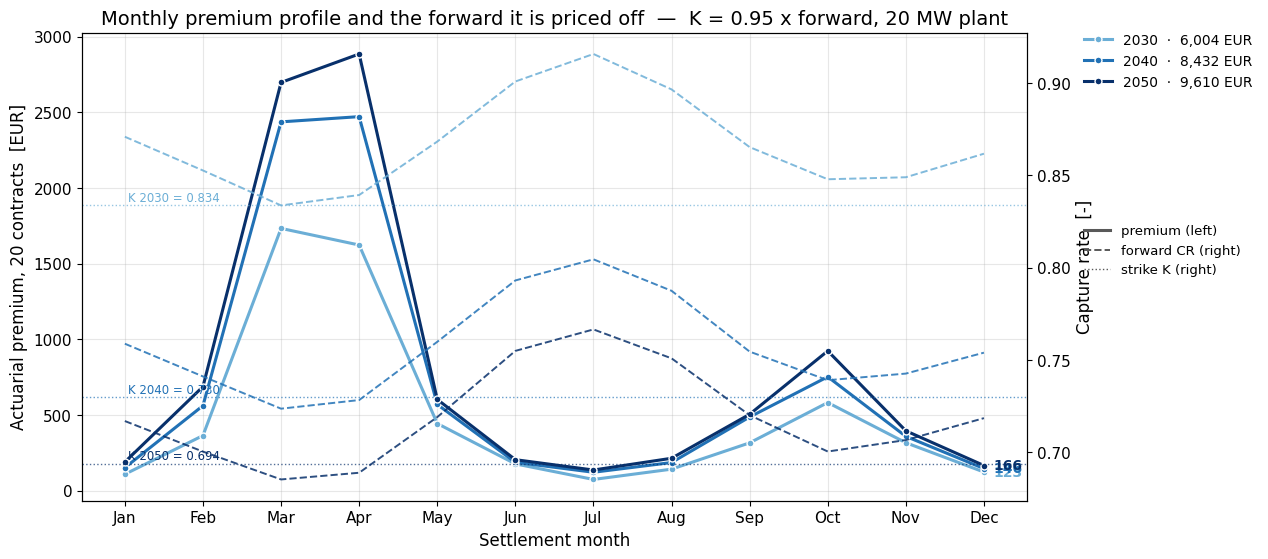

Monthly premium, 20 contracts (EUR)
  2030: total     6,004   Nov-Mar  44.1%   May-Aug 13.9%   peak Mar   F_m over K: min 1.000 (win) max 1.098 (sum)
  2040: total     8,432   Nov-Mar  43.4%   May-Aug 12.6%   peak Apr   F_m over K: min 0.991 (win) max 1.102 (sum)
  2050: total     9,610   Nov-Mar  43.0%   May-Aug 12.1%   peak Apr   F_m over K: min 0.988 (win) max 1.105 (sum)


In [8]:
# ── Monthly premium profile, with the capture rate behind it ─────────────────
#
# The actuarial premium per settlement month, for the full contracted position
# (N_CONTRACTS_CAP lots). premium_mc is quoted in CR units, so it is scaled by
# the same w_CR = N_MWh(m) x P_FIXED_EUR the contract settles on.
#
# Years are an ORDERED series, so they take a single-hue light-to-dark ramp
# rather than three arbitrary categorical colours: darker = later = dearer.
#
# TWIN AXIS. The right axis carries the capture rate, which shares no scale with
# the premium — so the two sets of lines must not be read against each other,
# only compared in SHAPE. What makes it legible rather than misleading is the
# strike: each year's K is drawn as a horizontal reference on the CR axis, so
# the distance between the dashed forward and its own dotted strike is the
# quantity that actually drives the premium below it. Colour encodes the year,
# line style encodes which axis: solid = premium (left), dashed = forward CR and
# dotted = strike (right).

PREMIUM_PLOT_YEARS = [2030, 2040, 2050]
_yr_colors = ["#6baed6", "#2171b5", "#08306b"]
_month_lab = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

_w = n_mwh_by_month.assign(w_CR=lambda d: d["N_MWh"] * P_FIXED_EUR)[["month", "w_CR"]]
_pp = (premium_mc.merge(_w, on="month")
                 .assign(prem_eur=lambda d: d["premium_mc"] * d["w_CR"]
                                            * N_CONTRACTS_CAP))

# monthly forward capture rate = the MC mean of the settlement index. This is the
# expectation the premium is priced off, so it is the right series to show beside it.
_fwd_m = (cr_monthly.groupby(["year", "month"])["CR_monthly"].mean()
                    .rename("F_m").reset_index())

fig, ax = plt.subplots(figsize=(15, 6))
ax2 = ax.twinx()

for _y, _c in zip(PREMIUM_PLOT_YEARS, _yr_colors):
    _s = (_pp[_pp["year"] == _y].sort_values("month")
                                .set_index("month")["prem_eur"])
    assert len(_s) == 12, f"{_y}: expected 12 monthly premiums, got {len(_s)}"
    ax.plot(_s.index, _s.values, color=_c, lw=2.2, marker="o", ms=5,
            markeredgecolor="white", markeredgewidth=1, zorder=3,
            label=f"{_y}  ·  {_s.sum():,.0f} EUR")
    ax.annotate(f"{_s.iloc[-1]:,.0f}", xy=(12, _s.iloc[-1]),
                xytext=(7, 0), textcoords="offset points",
                fontsize=10, color=_c, va="center", fontweight="bold")

    # right axis: the forward CR this premium is priced off, and its strike
    _f = (_fwd_m[_fwd_m["year"] == _y].sort_values("month")
                                      .set_index("month")["F_m"])
    ax2.plot(_f.index, _f.values, color=_c, lw=1.4, ls="--", alpha=0.85, zorder=2)
    _k = (float(fwd_strike.loc[fwd_strike["year"] == _y, "K"].mean())
          if isinstance(fwd_strike, pd.DataFrame) else float(K_CR))
    ax2.axhline(_k, color=_c, lw=1.0, ls=":", alpha=0.7, zorder=1)
    ax2.annotate(f"K {_y} = {_k:.3f}", xy=(1, _k), xytext=(2, 3),
                 textcoords="offset points", fontsize=8.5, color=_c)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(_month_lab, fontsize=11)
ax.set_xlabel("Settlement month", fontsize=12)
ax.set_ylabel(f"Actuarial premium, {N_CONTRACTS_CAP} contracts  [EUR]", fontsize=12)
ax2.set_ylabel("Capture rate  [-]", fontsize=12)
ax.set_title(f"Monthly premium profile and the forward it is priced off"
             f"  —  K = {FWD_MULT:.2f} x forward, {PLANT_MW} MW plant", fontsize=14)
ax.tick_params(axis="both", labelsize=11)
ax2.tick_params(axis="y", labelsize=11)

# two-part legend: colour = year, style = which axis
_style = [Line2D([], [], color="0.35", lw=2.2, ls="-",  label="premium (left)"),
          Line2D([], [], color="0.35", lw=1.4, ls="--", label="forward CR (right)"),
          Line2D([], [], color="0.35", lw=1.0, ls=":",  label="strike K (right)")]
# Both legends sit to the RIGHT of the axes, stacked. They are anchored in FIGURE
# coordinates via fig.legend, not axes coordinates: an axes-relative anchor moves
# whenever the layout engine resizes the axes, which is what kept clipping them.
# subplots_adjust below fixes the axes at 0.70 of the width, so the 0.73 anchor
# is an absolute position on the canvas and cannot drift.
_h1, _l1 = ax.get_legend_handles_labels()
_lg1 = fig.legend(_h1, _l1, fontsize=10, loc="upper left",
                  bbox_to_anchor=(0.73, 0.92), ncol=1, frameon=False)
_lg2 = fig.legend(handles=_style, fontsize=9.5, loc="upper left",
                  bbox_to_anchor=(0.73, 0.60), ncol=1, frameon=False)

ax.grid(alpha=0.3)
ax.set_axisbelow(True)
ax.margins(x=0.05)
fig.patch.set_facecolor("white")
# explicit margins rather than tight_layout: the legends are figure-anchored,
# so the axes box must be pinned for the anchor to mean anything
fig.subplots_adjust(left=0.07, right=0.70, top=0.90, bottom=0.12)

plt.show()

# the seasonal concentration the profile is meant to expose
print(f"Monthly premium, {N_CONTRACTS_CAP} contracts (EUR)")
for _y in PREMIUM_PLOT_YEARS:
    _s = _pp[_pp["year"] == _y].sort_values("month")["prem_eur"]
    _f = _fwd_m[_fwd_m["year"] == _y].sort_values("month")["F_m"]
    _k = (float(fwd_strike.loc[fwd_strike["year"] == _y, "K"].mean())
          if isinstance(fwd_strike, pd.DataFrame) else float(K_CR))
    _win = _s.iloc[[0, 1, 2, 10, 11]].sum()      # Jan-Mar + Nov-Dec
    _sum = _s.iloc[[4, 5, 6, 7]].sum()           # May-Aug
    print(f"  {_y}: total {_s.sum():>9,.0f}   "
          f"Nov-Mar {100*_win/_s.sum():>5.1f}%   May-Aug {100*_sum/_s.sum():>4.1f}%   "
          f"peak {_month_lab[int(_s.values.argmax())]}   "
          f"F_m over K: min {_f.min()/_k:.3f} (win) max {_f.max()/_k:.3f} (sum)")

> **Takeaway.** The premium is highest in the months the capture rate is lowest, confirming the strike schedule is pricing genuine seasonal cannibalisation risk rather than a flat cost spread evenly across the year.

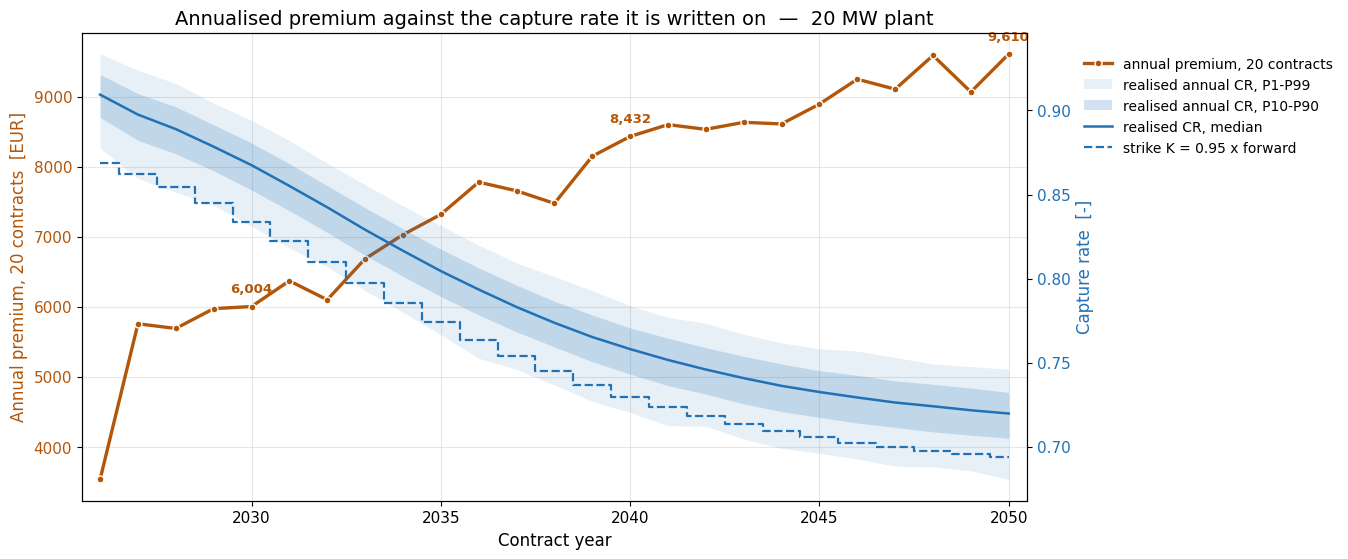

Annualised premium, 20 contracts
    year  premium EUR        K    CR P1   CR P10   CR P50   CR P90   CR P99     K-P1    K-P10
    2026        3,535   0.8686   0.8775   0.8958   0.9094   0.9214   0.9336  -0.0089  -0.0273
    2030        6,004   0.8339   0.8312   0.8527   0.8675   0.8806   0.8941  +0.0027  -0.0188
    2035        7,319   0.7743   0.7666   0.7894   0.8045   0.8175   0.8315  +0.0077  -0.0150
    2040        8,432   0.7299   0.7204   0.7433   0.7581   0.7707   0.7839  +0.0095  -0.0134
    2045        8,894   0.7056   0.6961   0.7175   0.7326   0.7452   0.7583  +0.0094  -0.0119
    2050        9,610   0.6938   0.6806   0.7052   0.7198   0.7324   0.7461  +0.0132  -0.0113
  K - P1 / K - P10 > 0 means the strike sits ABOVE that percentile of the
  realised annual index — the contract then pays in a year that bad.


In [9]:
# ── Annualised premium across the horizon ────────────────────────────────────
#
# Companion to the monthly profile above: that one is WITHIN a year (12
# settlements), this one is ACROSS years (2026-2050). Same contract, same
# N_CONTRACTS_CAP position, premium summed over the twelve settlements.
#
# Right axis carries the capture rate: the P1-P99 and P10-P90 bands of the
# REALISED annual index across paths, its median, and the strike. The band is
# what the option is actually written against, so the visible quantity is how far
# the strike sits below it and how that distance changes as the level falls.
#
# The strike is drawn as a STEP, not a line. K is a contract term fixed for the
# whole of each calendar year and re-struck at the boundary — it does not
# interpolate between years, and a connected line would imply that it does. The
# CR band and median stay as lines: those are annual summaries of a continuously
# varying process, not a piecewise-constant contractual quantity.
#
# Colour encodes QUANTITY here (not year, as in the monthly plot), because years
# are now the x-axis.

_C_PREM, _C_CR = "#b3560a", "#2171b5"

# annual index per path = mean of its twelve monthly settlement values
_ann_path = (cr_monthly.groupby(["sim_id", "year"])["CR_monthly"].mean()
                       .rename("CR_ann").reset_index())
_band = (_ann_path.groupby("year")["CR_ann"]
                  .agg(p01=lambda s: s.quantile(0.01),
                       p10=lambda s: s.quantile(0.10),
                       p50="median",
                       p90=lambda s: s.quantile(0.90),
                       p99=lambda s: s.quantile(0.99)))

# annual premium for the full position
_ann_prem = _pp.groupby("year")["prem_eur"].sum()

# the strike actually used, per year
if isinstance(fwd_strike, pd.DataFrame):
    _k_yr = fwd_strike.groupby("year")["K"].mean()
else:
    _k_yr = pd.Series(float(K_CR), index=_band.index)

_yrs = _band.index.to_numpy()
assert _ann_prem.index.equals(_band.index), "premium and CR year grids differ"

fig, ax = plt.subplots(figsize=(15, 6))
ax2 = ax.twinx()

# left: annualised premium
ax.plot(_yrs, _ann_prem.reindex(_yrs).values, color=_C_PREM, lw=2.4,
        marker="o", ms=5, markeredgecolor="white", markeredgewidth=1, zorder=3,
        label=f"annual premium, {N_CONTRACTS_CAP} contracts")

# right: realised CR band, its median, and the strike
ax2.fill_between(_yrs, _band["p01"], _band["p99"], color=_C_CR, alpha=0.10,
                 lw=0, zorder=1, label="realised annual CR, P1-P99")
ax2.fill_between(_yrs, _band["p10"], _band["p90"], color=_C_CR, alpha=0.20,
                 lw=0, zorder=1, label="realised annual CR, P10-P90")
ax2.plot(_yrs, _band["p50"], color=_C_CR, lw=1.8, zorder=2,
         label="realised CR, median")
ax2.step(_yrs, _k_yr.reindex(_yrs).values, where="mid", color=_C_CR, lw=1.6,
         ls="--", zorder=2, label=f"strike K = {FWD_MULT:.2f} x forward")

ax.set_xlabel("Contract year", fontsize=12)
ax.set_ylabel(f"Annual premium, {N_CONTRACTS_CAP} contracts  [EUR]",
              fontsize=12, color=_C_PREM)
ax2.set_ylabel("Capture rate  [-]", fontsize=12, color=_C_CR)
ax.tick_params(axis="y", labelcolor=_C_PREM, labelsize=11)
ax2.tick_params(axis="y", labelcolor=_C_CR, labelsize=11)
ax.tick_params(axis="x", labelsize=11)
ax.set_title("Annualised premium against the capture rate it is written on"
             f"  —  {PLANT_MW} MW plant", fontsize=14)

# premium as a share of revenue, on the same figure as a second reading
for _y in PREMIUM_PLOT_YEARS:
    _v = float(_ann_prem.loc[_y])
    ax.annotate(f"{_v:,.0f}", xy=(_y, _v), xytext=(0, 10),
                textcoords="offset points", ha="center",
                fontsize=9.5, color=_C_PREM, fontweight="bold")

# figure-anchored legend, as in the monthly plot
_h1, _l1 = ax.get_legend_handles_labels()
_h2, _l2 = ax2.get_legend_handles_labels()
_lgA = fig.legend(_h1 + _h2, _l1 + _l2, fontsize=10, loc="upper left",
                  bbox_to_anchor=(0.73, 0.88), ncol=1, frameon=False)

ax.grid(alpha=0.3)
ax.set_axisbelow(True)
ax.margins(x=0.02)
fig.patch.set_facecolor("white")
fig.subplots_adjust(left=0.07, right=0.70, top=0.90, bottom=0.12)

plt.show()

print(f"Annualised premium, {N_CONTRACTS_CAP} contracts")
print(f"  {'year':>6}{'premium EUR':>13}{'K':>9}{'CR P1':>9}{'CR P10':>9}"
      f"{'CR P50':>9}{'CR P90':>9}{'CR P99':>9}{'K-P1':>9}{'K-P10':>9}")
for _y in [2026, 2030, 2035, 2040, 2045, 2050]:
    _b = _band.loc[_y]; _kk = float(_k_yr.loc[_y])
    print(f"  {_y:>6}{_ann_prem.loc[_y]:>13,.0f}{_kk:>9.4f}"
          f"{_b['p01']:>9.4f}{_b['p10']:>9.4f}{_b['p50']:>9.4f}"
          f"{_b['p90']:>9.4f}{_b['p99']:>9.4f}"
          f"{_kk - _b['p01']:>+9.4f}{_kk - _b['p10']:>+9.4f}")
print("  K - P1 / K - P10 > 0 means the strike sits ABOVE that percentile of the")
print("  realised annual index — the contract then pays in a year that bad.")

> **Takeaway.** The annualised premium rises through the horizon as the capture rate declines, tracking the same downward trend the revenue-index notebooks report -- the hedge gets more expensive exactly as cannibalisation deepens.

## Step 2 — Historical Backtest 2008–2025

Window and strike rule are printed by the cell itself, from `BACKTEST_START`/`BACKTEST_END`
and `STRIKE_RULE`, so this heading cannot drift from the code again.


 year  CR_annual  annual_payoff  annual_premium  net_pnl  RI_unhedged  RI_hedged
 2011     0.9744         0.0100          0.0316  -0.0216    1179.1878  1179.1318
 2012     0.9223         0.1244          0.0175   0.1068    1074.1225  1074.6140
 2013     0.9134         0.1613          0.0684   0.0929     980.5865   981.2478
 2014     0.9225         0.1110          0.1068   0.0042     988.1936   988.1967
 2015     0.9535         0.0227          0.1216  -0.0988    1100.7400  1100.1324
 2016     0.9600         0.0217          0.0796  -0.0579    1067.2225  1066.9076
 2017     0.9578         0.0033          0.0443  -0.0410    1161.2808  1161.1376
 2018     0.9585         0.0577          0.0208   0.0369    1057.1685  1057.3912
 2019     0.9550         0.0000          0.0228  -0.0228    1098.8868  1098.7635
 2020     0.9296         0.1114          0.0367   0.0747    1107.0355  1107.4489
 2021     0.9555         0.0000          0.0489  -0.0489    1099.2052  1098.9267
 2022     0.9407         0.0

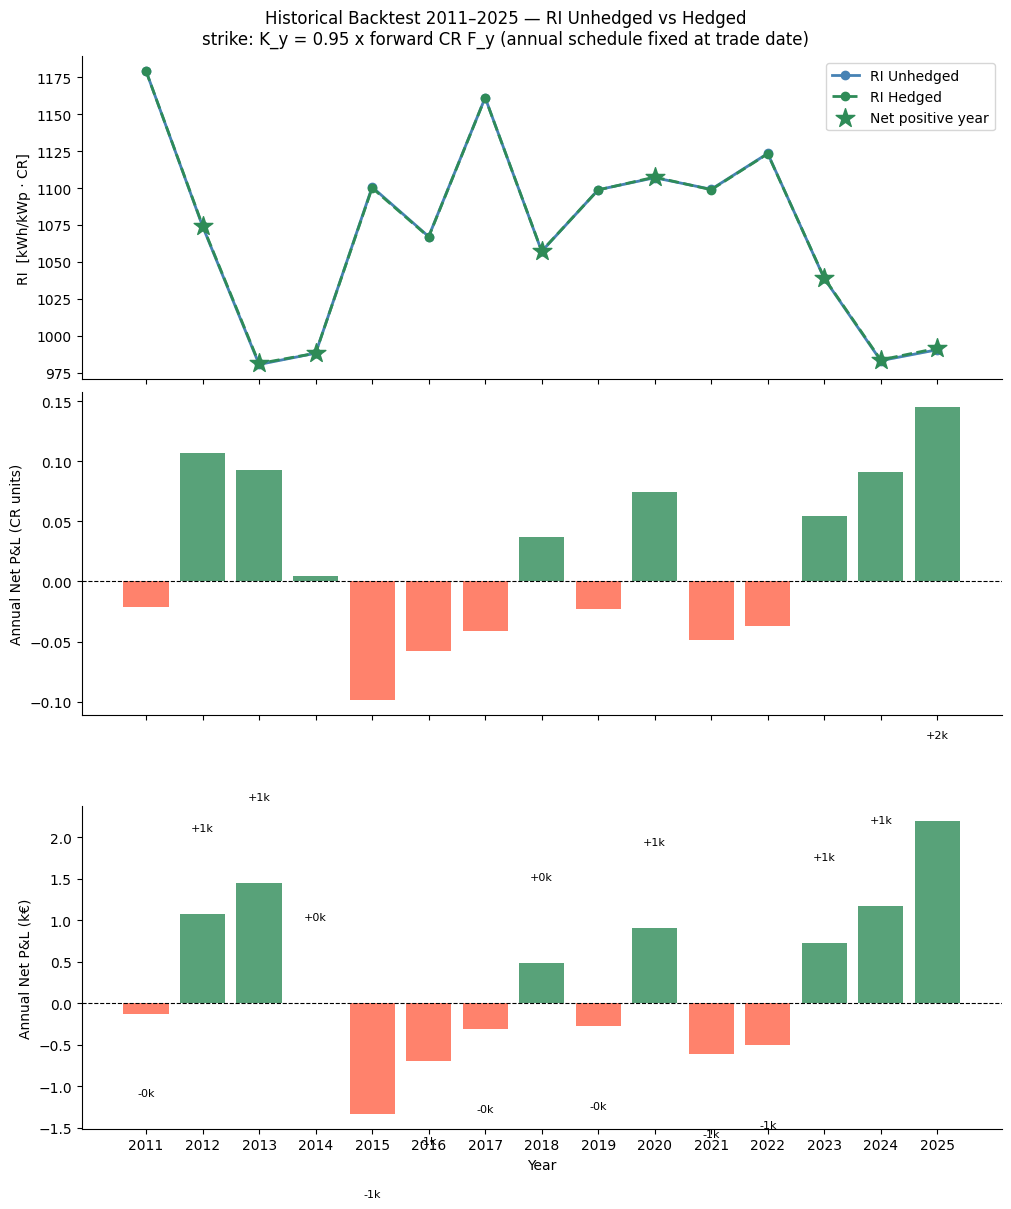

In [10]:
def step2_historical_backtest(cr_h_m, ri_h, premium_roll, monthly_p_hist, n_mwh_by_month,
                              hist_strike=None, start=BACKTEST_START, end=BACKTEST_END):
    # Settles on the monthly CR built in load_data — the same basis premium_roll
    # is now estimated on, and the same basis the forward contract settles on.
    hist_strike = default_historical_strike(cr_h_m) if hist_strike is None else hist_strike
    bt_m = cr_h_m[cr_h_m["year"].between(start, end)][["year", "month", "CR_hist_m"]].copy()
    kv, bt_m = strike_vector(bt_m, hist_strike, keys=("year",))
    bt_m["payoff_m"] = np.clip(kv - bt_m["CR_hist_m"].to_numpy(), 0, None)
    bt_m = bt_m.merge(premium_roll[["year", "month", "premium_roll"]], on=["year", "month"])
    bt_m["net_m"] = bt_m["payoff_m"] - bt_m["premium_roll"]

    # EUR legs at P_FIXED, i.e. the SAME instrument the forward analysis prices.
    # Valuing both legs at the REALISED monthly NORD price instead would (a) be
    # look-ahead for a premium that would be struck at inception and (b) backtest
    # a floating-price contract while everything downstream assumes a fixed price.
    # monthly_p_hist is retained only for the reference column below.
    bt_m = bt_m.merge(n_mwh_by_month, on="month", how="left")
    bt_m["payoff_eur_m"]  = bt_m["payoff_m"]     * bt_m["N_MWh"] * P_FIXED_EUR
    bt_m["premium_eur_m"] = bt_m["premium_roll"] * bt_m["N_MWh"] * P_FIXED_EUR
    bt_m["net_eur_m"]     = bt_m["net_m"]        * bt_m["N_MWh"] * P_FIXED_EUR

    annual = (
        bt_m.groupby("year")
        .agg(annual_payoff     =("payoff_m",        "sum"),
             annual_premium    =("premium_roll",     "sum"),
             annual_net        =("net_m",            "sum"),
             annual_payoff_eur =("payoff_eur_m",     "sum"),
             annual_premium_eur=("premium_eur_m",    "sum"),
             annual_net_eur    =("net_eur_m",        "sum"))
        .reset_index()
    )

    bt = ri_h[ri_h["year"].between(start, end)].merge(annual, on="year")
    # Same EUR-basis mapping as step5 (no /12, no PR_annual proxy).
    bt["RI_unhedged"] = bt["RI_annual"]
    bt["RI_hedged"]   = bt["RI_annual"] + bt["annual_net_eur"] / REV_PER_RI

    table = bt[["year", "CR_annual", "annual_payoff", "annual_premium", "annual_net",
                "RI_unhedged", "RI_hedged"]].copy()
    table.columns = ["year", "CR_annual", "annual_payoff", "annual_premium", "net_pnl",
                     "RI_unhedged", "RI_hedged"]
    print(table.to_string(index=False, float_format="{:.4f}".format))

    n_pay = int((bt["annual_payoff"] > 0).sum())
    n_mo  = int((bt_m["payoff_m"] > 0).sum())
    _kdesc = strike_description()
    print(f"\nBacktest window {start}–{end}  |  strike rule: {_kdesc}")
    print(f"Years with any payoff : {n_pay} of {len(bt)}"
          f"   |  months in the money: {n_mo} of {len(bt_m)} ({n_mo/len(bt_m):.1%})")
    if n_mo:
        _yrs = sorted(bt_m.loc[bt_m["payoff_m"] > 0, "year"].unique())
        print(f"  payoff years: {_yrs}")
    print(f"\nEUR P&L — {NOTIONAL_MW} MW · P_fixed = {P_FIXED_EUR} EUR/MWh:")
    eur_cols = bt[["year", "annual_payoff_eur", "annual_premium_eur", "annual_net_eur"]].copy()
    eur_cols.columns = ["year", "payoff_EUR", "premium_EUR", "net_EUR"]
    for _, row in eur_cols.iterrows():
        print(f"  {int(row.year)}  payoff={row.payoff_EUR:>10,.0f}  "
              f"premium={row.premium_EUR:>10,.0f}  net={row.net_EUR:>+10,.0f}")

    years      = bt["year"].values
    ri_unh     = bt["RI_unhedged"].values
    ri_hed     = bt["RI_hedged"].values
    net_pos    = bt["annual_net"].values > 0
    net_v      = bt["annual_net"].values
    net_eur_v  = bt["annual_net_eur"].values

    fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True,
                             constrained_layout=True)

    # top: RI comparison
    ax = axes[0]
    ax.plot(years, ri_unh, color="steelblue", lw=2, marker="o", label="RI Unhedged")
    ax.plot(years, ri_hed, color="seagreen",  lw=2, marker="o", linestyle="--", label="RI Hedged")
    ax.fill_between(years, ri_unh, ri_hed, alpha=0.15, color="seagreen")
    ax.scatter(years[net_pos], ri_hed[net_pos], marker="*", s=200, color="seagreen",
               zorder=5, label="Net positive year")
    ax.set_ylabel("RI  [kWh/kWp · CR]")
    ax.legend()

    # middle: CR units net P&L
    ax = axes[1]
    bar_colors = ["seagreen" if v > 0 else "tomato" for v in net_v]
    ax.bar(years, net_v, color=bar_colors, alpha=0.8)
    ax.axhline(0, color="black", lw=0.8, linestyle="--")
    ax.set_ylabel("Annual Net P&L (CR units)")
    ax.set_xticks(years)

    # bottom: EUR net P&L
    ax = axes[2]
    bar_colors_eur = ["seagreen" if v > 0 else "tomato" for v in net_eur_v]
    ax.bar(years, net_eur_v / 1e3, color=bar_colors_eur, alpha=0.8)
    ax.axhline(0, color="black", lw=0.8, linestyle="--")
    ax.set_ylabel("Annual Net P&L (k€)")
    ax.set_xlabel("Year")
    ax.set_xticks(years)
    for yr, v in zip(years, net_eur_v):
        ax.text(yr, v / 1e3 + (1 if v >= 0 else -1),
                f"{v/1e3:+.0f}k", ha="center", fontsize=8)

    # Degenerate-figure guard: at a strike the sample never breaches, every series
    # here is identically zero and the axes render blank. Say so on the figure
    # rather than leaving three empty panels.
    if not n_mo:
        for ax in axes:
            ax.text(0.5, 0.5,
                    f"No payoff in {start}–{end} at this strike\n"
                    f"({_kdesc}) — every series is identically zero",
                    transform=ax.transAxes, ha="center", va="center",
                    fontsize=10, color="crimson",
                    bbox=dict(boxstyle="round", fc="white", ec="crimson", alpha=0.9))

    fig.suptitle(f"Historical Backtest {start}–{end} — RI Unhedged vs Hedged\n"
                 f"strike: {_kdesc}")
    sns.despine()
    plt.show()
    return bt


bt = step2_historical_backtest(cr_h_m, ri_h, premium_roll, monthly_p_hist,
                               n_mwh_by_month, hist_strike=hist_strike)

# Item under test: the backtest must no longer be degenerate under the rolling rule.
if STRIKE_RULE == "rolling":
    assert bt["annual_payoff"].sum() > 0, (
        "rolling strike produced no historical payoff — schedule is likely wrong")

> **Takeaway.** The backtest confirms the strike schedule is not degenerate over 2011-2025: the contract is in and out of the money across the window rather than always or never paying, which a fixed strike could not achieve over the same span.

## Step 3 — Premium Trajectory by Quarter (2008–2050)


          Q1      Q2      Q3      Q4
year                                
2011 0.00618 0.00000 0.00000 0.00435
2012 0.00105 0.00308 0.00000 0.00171
2013 0.00822 0.01214 0.00059 0.00184
2014 0.01021 0.02259 0.00061 0.00218
2015 0.01562 0.02256 0.00061 0.00174
2016 0.00844 0.01350 0.00002 0.00456
2017 0.00646 0.00329 0.00000 0.00503
2018 0.00000 0.00285 0.00000 0.00410
2019 0.00270 0.00409 0.00000 0.00080
2020 0.00270 0.00954 0.00000 0.00000
2021 0.00592 0.01039 0.00000 0.00000
2022 0.00323 0.00915 0.00000 0.00000
2023 0.00323 0.00656 0.00000 0.00118
2024 0.00157 0.01402 0.00016 0.00281
2025 0.00285 0.03176 0.00016 0.00333
2026 0.00140 0.00162 0.00053 0.00263
2027 0.00420 0.00250 0.00066 0.00267
2028 0.00379 0.00269 0.00064 0.00266
2029 0.00418 0.00262 0.00074 0.00285
2030 0.00418 0.00262 0.00065 0.00298
2031 0.00423 0.00277 0.00077 0.00325
2032 0.00394 0.00252 0.00085 0.00347
2033 0.00450 0.00309 0.00063 0.00346
2034 0.00459 0.00332 0.00076 0.00357
2035 0.00493 0.00323 0.00091 0.00370
2

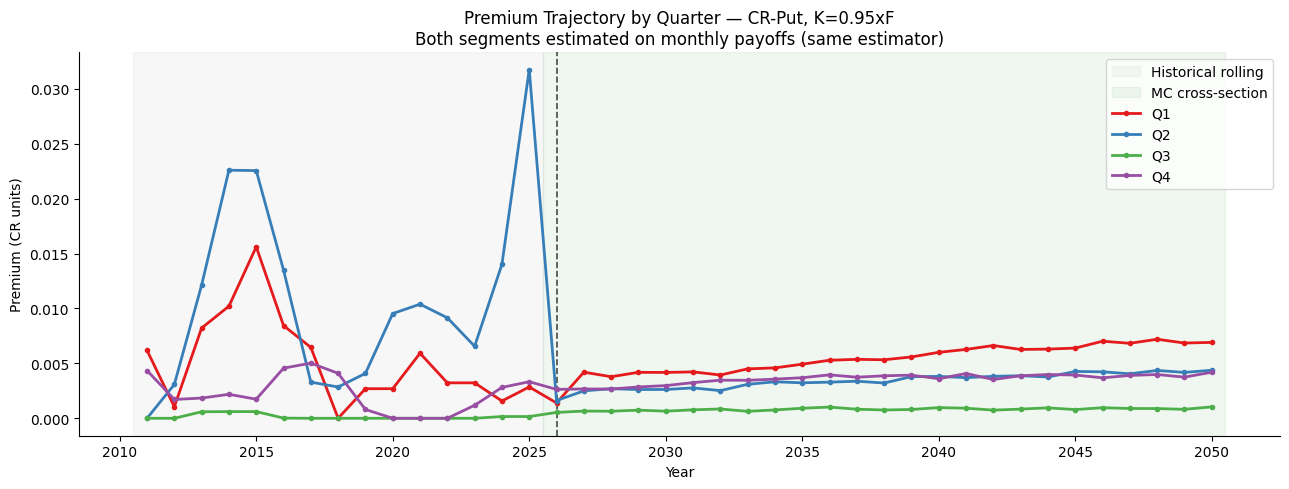

In [11]:
def step3_premium_trajectory(premium_roll, premium_mc):
    hist_q = (
        premium_roll.groupby(["year", "quarter"])["premium_roll"]
        .mean().reset_index()
        .rename(columns={"premium_roll": "premium"})
    )
    hist_q["source"] = "historical"

    sim_q = (
        premium_mc.groupby(["year", "quarter"])["premium_mc"]
        .mean().reset_index()
        .rename(columns={"premium_mc": "premium"})
    )
    sim_q["source"] = "simulated"

    combined = pd.concat([hist_q, sim_q], ignore_index=True)

    pivot = combined.pivot_table(index="year", columns="quarter", values="premium")
    pivot.columns = [f"Q{c}" for c in pivot.columns]
    print(pivot.to_string(float_format="{:.5f}".format))

    colors_q = {1: "#e41a1c", 2: "#377eb8", 3: "#4daf4a", 4: "#984ea3"}
    hist_yrs = sorted(hist_q["year"].unique())
    sim_yrs  = sorted(sim_q["year"].unique())

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.axvspan(min(hist_yrs) - 0.5, 2025.5, alpha=0.06, color="grey",  label="Historical rolling")
    ax.axvspan(2025.5, max(sim_yrs) + 0.5,  alpha=0.06, color="green", label="MC cross-section")
    ax.axvline(2026, color="black", lw=1.2, linestyle="--", alpha=0.7)

    for q in [1, 2, 3, 4]:
        sub = combined[combined["quarter"] == q].sort_values("year")
        ax.plot(sub["year"], sub["premium"], color=colors_q[q], lw=2,
                marker="o", ms=3, label=f"Q{q}")

    ax.set_title(f"Premium Trajectory by Quarter — CR-Put, {strike_description(short=True)}\n"
                 "Both segments estimated on monthly payoffs (same estimator)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Premium (CR units)")
    ax.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()
    return combined


combined_premium = step3_premium_trajectory(premium_roll, premium_mc)

> **Takeaway.** The historical rolling premium and the Monte Carlo premium track each other's level and trend across the 2008-2050 span, cross-validating the simulated pricing against the observed record where the two overlap.

## Step 4 — Single Month Example

Year and month are set by `EXAMPLE_YEAR` / `EXAMPLE_MONTH` in the cell below and
flow into every label, so the heading cannot drift from the code again.

> The strike used below is the forward schedule `K_y = FWD_MULT x F_y`, not a
> constant — the example reports `Pr(CR < K)` for that year'''s K, so how deep
> the option sits in or out of the money is visible rather than implied.

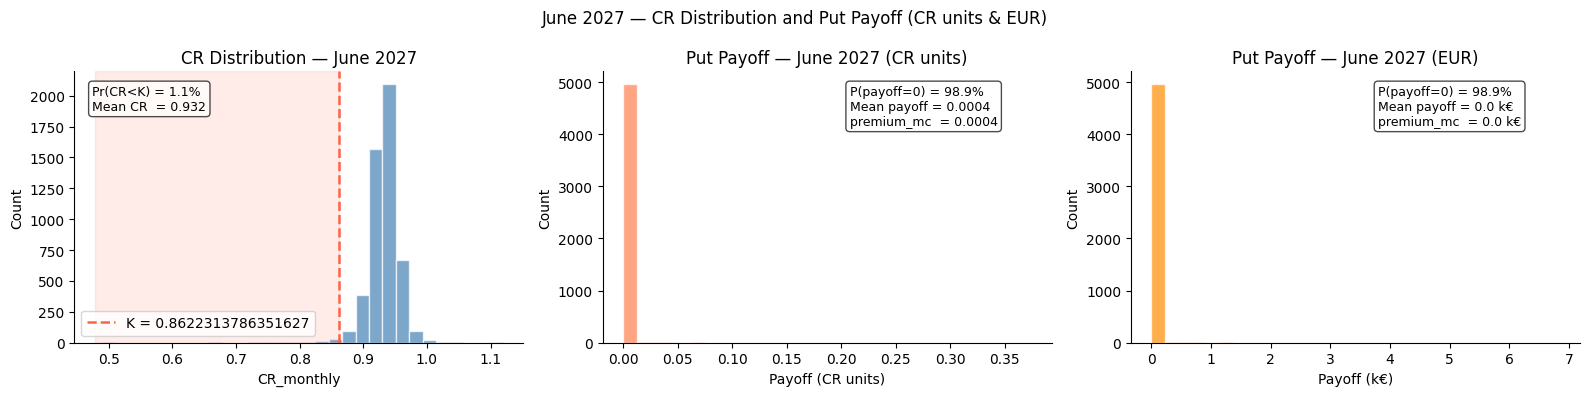

Pr(CR<K)     : 1.1%
Severity     : 0.0386 CR units  |  705 EUR
premium_mc   : 0.0004 CR units  |  8 EUR
N_MWh (Jun) : 166 MWh  ·  P_fixed = 110.0 EUR/MWh


In [12]:
EXAMPLE_YEAR  = 2027
EXAMPLE_MONTH = 6


def step4_month_example(cr_monthly, premium_mc, n_mwh_by_month,
                        year=EXAMPLE_YEAR, month=EXAMPLE_MONTH,
                        strike=None, p_fixed=P_FIXED_EUR):
    month_name = calendar.month_name[month]
    tag        = f"{month_name} {year}"
    _sel = (cr_monthly["year"] == year) & (cr_monthly["month"] == month)
    strike = fwd_strike if strike is None else strike
    _kv, _ = strike_vector(cr_monthly[_sel], strike)
    K = float(np.mean(_kv))   # constant within a block, so the mean is that value
    cr_june     = cr_monthly.loc[_sel, "CR_monthly"]
    payoff_june = (K - cr_june).clip(lower=0)
    prem_june   = premium_mc.loc[
        (premium_mc["year"] == year) & (premium_mc["month"] == month), "premium_mc"
    ].iloc[0]

    freq        = (cr_june < K).mean()
    severity_cr = (K - cr_june[cr_june < K]).mean() if (cr_june < K).any() else 0.0

    # EUR equivalents using June seasonal notional
    N_MWh_june     = n_mwh_by_month.loc[n_mwh_by_month["month"] == month, "N_MWh"].iloc[0]
    payoff_june_eur = payoff_june * N_MWh_june * p_fixed
    prem_june_eur   = prem_june   * N_MWh_june * p_fixed
    severity_eur    = severity_cr * N_MWh_june * p_fixed

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # left: CR distribution
    ax = axes[0]
    ax.hist(cr_june, bins=30, color="steelblue", alpha=0.7, edgecolor="white")
    ax.axvline(K, color="tomato", lw=1.8, linestyle="--", label=f"K = {K}")
    ax.axvspan(cr_june.min() - 0.01, K, alpha=0.12, color="tomato")
    ax.set_title(f"CR Distribution — {tag}")
    ax.set_xlabel("CR_monthly")
    ax.set_ylabel("Count")
    ax.text(0.04, 0.95, f"Pr(CR<K) = {freq:.1%}\nMean CR  = {cr_june.mean():.3f}",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", fc="white", alpha=0.7))
    ax.legend()

    # middle: CR payoff histogram
    ax = axes[1]
    ax.hist(payoff_june, bins=30, color="coral", alpha=0.7, edgecolor="white")
    ax.set_title(f"Put Payoff — {tag} (CR units)")
    ax.set_xlabel("Payoff (CR units)")
    ax.set_ylabel("Count")
    ax.text(0.55, 0.95,
            f"P(payoff=0) = {1 - freq:.1%}\nMean payoff = {payoff_june.mean():.4f}\npremium_mc  = {prem_june:.4f}",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", fc="white", alpha=0.7))

    # right: EUR payoff histogram
    ax = axes[2]
    ax.hist(payoff_june_eur / 1e3, bins=30, color="darkorange", alpha=0.7, edgecolor="white")
    ax.set_title(f"Put Payoff — {tag} (EUR)")
    ax.set_xlabel("Payoff (k€)")
    ax.set_ylabel("Count")
    ax.text(0.55, 0.95,
            f"P(payoff=0) = {1 - freq:.1%}\nMean payoff = {payoff_june_eur.mean()/1e3:,.1f} k€\npremium_mc  = {prem_june_eur/1e3:,.1f} k€",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", fc="white", alpha=0.7))

    fig.suptitle(f"{tag} — CR Distribution and Put Payoff (CR units & EUR)")
    sns.despine()
    plt.tight_layout()
    plt.show()

    print(f"Pr(CR<K)     : {freq:.1%}")
    print(f"Severity     : {severity_cr:.4f} CR units  |  {severity_eur:,.0f} EUR")
    print(f"premium_mc   : {prem_june:.4f} CR units  |  {prem_june_eur:,.0f} EUR")
    print(f"N_MWh ({month_name[:3]}) : {N_MWh_june:,.0f} MWh  ·  P_fixed = {p_fixed} EUR/MWh")


step4_month_example(cr_monthly, premium_mc, n_mwh_by_month)

> **Takeaway.** For one concrete month, the payoff triggers exactly when the simulated capture rate falls below that month's strike -- a worked example of the mechanics the aggregate statistics elsewhere summarise.

## Step 5 — Apply Hedge (Forward 2026–2050)

In [13]:
def step5_apply_hedge(cr_monthly, ri, premium_mc, n_mwh_by_month, strike=None,
                      premium_mc_oos=None, n_contracts=None):
    """Apply n_contracts lots of the CR put to the plant's revenue.

    n_contracts defaults to N_CONTRACTS_CAP — one LOT_MW lot per MW of plant,
    i.e. a 100% hedge. The payoff and premium legs scale linearly in it, so the
    quantity is a pure multiplier on the money columns; nothing about the
    contract itself changes with n.
    """
    n_contracts = N_CONTRACTS_CAP if n_contracts is None else n_contracts
    assert n_contracts > 0, "hedge quantity must be positive"
    strike = fwd_strike if strike is None else strike
    cr = cr_monthly.merge(premium_mc[["year", "month", "premium_mc"]], on=["year", "month"])
    _kv, cr = strike_vector(cr, strike)
    cr["payoff_sim"] = np.clip(_kv - cr["CR_monthly"].to_numpy(), 0, None)
    cr["net_sim"]    = cr["payoff_sim"] - cr["premium_mc"]

    # Out-of-sample counterpart: each path pays a premium estimated without it.
    if premium_mc_oos is not None:
        cr["fold"] = cr["sim_id"] % N_PRICE_FOLDS
        cr = cr.merge(premium_mc_oos, on=["year", "month", "fold"], how="left")
        cr["net_sim_oos"] = cr["payoff_sim"] - cr["premium_mc_oos"]

    # EUR notional columns — seasonal N_MWh × fixed forward price (D-N1, D-N3)
    cr = cr.merge(n_mwh_by_month, on="month", how="left")
    # n_contracts lots of a LOT_MW contract: the money legs scale linearly
    _lot = n_contracts * cr["N_MWh"] * P_FIXED_EUR
    cr["payoff_eur_m"] = cr["payoff_sim"] * _lot
    cr["net_eur_m"]    = cr["net_sim"]    * _lot

    cr["net_eur_oos_m"] = (cr["net_sim_oos"] * _lot
                           if "net_sim_oos" in cr else np.nan)

    annual_net = (
        cr.groupby(["sim_id", "year"])
        .agg(annual_net_sim     =("net_sim",       "sum"),
             annual_payoff_eur  =("payoff_eur_m",  "sum"),
             annual_net_eur     =("net_eur_m",     "sum"),
             annual_net_eur_oos =("net_eur_oos_m", "sum"))
        .reset_index()
    )

    merged = ri.merge(annual_net, on=["sim_id", "year"], how="inner")

    # ── EUR basis (primary) ───────────────────────────────────────────────────
    # The hedge is applied in money, using the contract's own seasonal notional
    # (annual_net_eur already weights each month by N_MWh(m)).
    #
    # The previous mapping, RI_annual + PR_annual * annual_net_sim / 12, had two
    # defects: (i) /12 weights every month equally while the contract weights by
    # production (Jan 3.1% vs Jun 13.8% of annual MWh), and (ii) PR_annual =
    # RI_annual/CR_annual equals annual yield only if cov(P_t, CR_t)=0, which
    # cannibalisation violates by construction. Both are removed here.
    merged["rev_unhedged_eur"] = merged["RI_annual"] * REV_PER_RI / 1e6      # M€
    merged["rev_hedged_eur"]   = merged["rev_unhedged_eur"] + merged["annual_net_eur"] / 1e6

    # RI-space equivalents, defined as the exact rescaling of the EUR series so
    # the two bases cannot diverge (any ratio metric is identical in either).
    merged["RI_sim_unhedged"] = merged["RI_annual"]
    merged["RI_sim_hedged"]   = merged["RI_annual"] + merged["annual_net_eur"] / REV_PER_RI

    # The check whose absence let Part I and Part II model different contracts.
    _resid = ((merged["rev_hedged_eur"] - merged["rev_unhedged_eur"]) * 1e6
              - merged["annual_net_eur"]).abs().max()
    assert _resid < 1e-6, f"EUR hedge leg inconsistent with annual_net_eur: {_resid:.3e}"
    _resid_ri = (merged["rev_hedged_eur"]
                 - merged["RI_sim_hedged"] * REV_PER_RI / 1e6).abs().max()
    assert _resid_ri < 1e-6, f"RI leg inconsistent with EUR leg: {_resid_ri:.3e}"

    print(f"ri_sim shape         : {merged.shape}")
    print(f"Mean annual_net_sim  : {merged['annual_net_sim'].mean():.6f}  (≈0 by fair-premium construction)")
    print(f"Mean annual_net_eur  : {merged['annual_net_eur'].mean():,.0f} EUR  (≈0 by construction)")
    print(f"Mean unhedged revenue: {merged['rev_unhedged_eur'].mean():,.2f} M€/yr")
    print(f"  RI→EUR consistency : max |Δ| = {_resid:.2e} EUR  ✓")

    # NOTE on cross-fitting: with equal folds the OOS mean net P&L is also ~0, by
    # symmetry (each fold pays the other fold's mean, and the folds average back
    # to the pooled mean). So the MEAN cannot expose premium-estimation risk at
    # all — the dispersion of the premium estimate can, and that is reported as a
    # bootstrap standard error in the pricing-uncertainty cell below.
    if merged["annual_net_eur_oos"].notna().any():
        _is  = merged["annual_net_eur"].mean()
        _oos = merged["annual_net_eur_oos"].mean()
        print(f"  Mean net P&L in-sample     : {_is:>12,.0f} EUR/yr  (0 by construction)")
        print(f"  Mean net P&L cross-fitted  : {_oos:>12,.0f} EUR/yr  "
              f"(also ~0 by fold symmetry — see note)")
    return merged


ri_sim = step5_apply_hedge(cr_monthly, ri, premium_mc, n_mwh_by_month,
                           strike=fwd_strike, premium_mc_oos=premium_mc_oos)

ri_sim shape         : (125000, 13)
Mean annual_net_sim  : -0.000000  (≈0 by fair-premium construction)
Mean annual_net_eur  : -0 EUR  (≈0 by construction)
Mean unhedged revenue: 1.99 M€/yr
  RI→EUR consistency : max |Δ| = 2.33e-10 EUR  ✓
  Mean net P&L in-sample     :           -0 EUR/yr  (0 by construction)
  Mean net P&L cross-fitted  :            0 EUR/yr  (also ~0 by fold symmetry — see note)


## Step 5b — Discounting (risk-free)

The contract is a 25-year strip whose premiums grow roughly 1,500× from 2026 to 2050,
so an undiscounted horizon materially overstates late-horizon hedge value.

What is being valued here is a strip of **hedge cash flows**, not project equity, so
these are discounted at a risk-free EUR rate (`R_FREE`) rather than a project WACC,
with a sensitivity across `DISCOUNT_RATES`.

The **discounted portfolio variance reduction** below replaces the "cumulative average"
line in Step 8: an expanding mean of yearly ratios across years of very different scale
has no economic interpretation, whereas the variance reduction of the discounted
lifetime revenue is the quantity an investment committee would actually use.


In [14]:
# ── Discount factors ──────────────────────────────────────────────────────────
def discount_factor(years, rate, base_year=BASE_YEAR):
    """Risk-free discount factor per year, relative to base_year."""
    return np.asarray([(1.0 + rate) ** -(int(y) - base_year) for y in years], dtype=float)


_years_sorted = np.sort(ri_sim["year"].unique())

# ── NPV of the hedge legs (mean across paths) ────────────────────────────────
_per_year = (ri_sim.groupby("year")
                   .agg(payoff_eur=("annual_payoff_eur", "mean"),
                        net_eur   =("annual_net_eur",    "mean"))
                   .reindex(_years_sorted))
_per_year["premium_eur"] = _per_year["payoff_eur"] - _per_year["net_eur"]

print("── NPV of hedge cash flows (mean path, 2026–2050) ──────────────────")
print(f"{'rate':>7}  {'NPV premium':>16}  {'NPV payoff':>16}  {'NPV net':>14}")
print(f"{'-'*7}  {'-'*16}  {'-'*16}  {'-'*14}")
for _r in DISCOUNT_RATES:
    _d = discount_factor(_years_sorted, _r)
    _npv_prem = float((_per_year["premium_eur"].values * _d).sum())
    _npv_pay  = float((_per_year["payoff_eur"].values  * _d).sum())
    _npv_net  = float((_per_year["net_eur"].values     * _d).sum())
    _tag = "  <- headline" if abs(_r - R_FREE) < 1e-12 else ""
    print(f"{_r:>6.1%}  {_npv_prem:>16,.0f}  {_npv_pay:>16,.0f}  {_npv_net:>14,.0f}{_tag}")

# ── Discounted portfolio variance reduction ──────────────────────────────────
# Each simulated path is one lifetime revenue stream; discount it, then compare the
# variance of the hedged and unhedged lifetime totals across paths.
_piv_unh = ri_sim.pivot(index="sim_id", columns="year", values="rev_unhedged_eur").sort_index(axis=1)
_piv_hed = ri_sim.pivot(index="sim_id", columns="year", values="rev_hedged_eur").sort_index(axis=1)
assert list(_piv_unh.columns) == list(_piv_hed.columns)

print("\n── Variance reduction of DISCOUNTED lifetime revenue ───────────────")
print(f"{'rate':>7}  {'var_red':>10}   (single-year 2050 var_red for reference:"
      f" {rm.variance_reduction(ri_sim.loc[ri_sim['year']==2050, 'rev_unhedged_eur'], ri_sim.loc[ri_sim['year']==2050, 'rev_hedged_eur']):.1%})")
print(f"{'-'*7}  {'-'*10}")
portfolio_vr = {}
for _r in DISCOUNT_RATES:
    _d   = discount_factor(_piv_unh.columns, _r)
    _pu  = (_piv_unh.values * _d).sum(axis=1)
    _ph  = (_piv_hed.values * _d).sum(axis=1)
    _vr  = rm.variance_reduction(_pu, _ph)
    portfolio_vr[_r] = _vr
    _tag = "  <- headline" if abs(_r - R_FREE) < 1e-12 else ""
    print(f"{_r:>6.1%}  {_vr:>10.2%}{_tag}")

print("\nDiscounting reduces measured effectiveness because essentially all of the")
print("hedge's power sits in the late-horizon years, which discounting down-weights.")


── NPV of hedge cash flows (mean path, 2026–2050) ──────────────────
   rate       NPV premium        NPV payoff         NPV net
-------  ----------------  ----------------  --------------
  0.0%           189,862           189,862              -0
  1.5%           156,478           156,478              -0
  2.5%           138,590           138,590              -0  <- headline
  3.5%           123,467           123,467              -0

── Variance reduction of DISCOUNTED lifetime revenue ───────────────
   rate     var_red   (single-year 2050 var_red for reference: 8.8%)
-------  ----------
  0.0%       6.01%
  1.5%       5.65%
  2.5%       5.43%  <- headline
  3.5%       5.22%

Discounting reduces measured effectiveness because essentially all of the
hedge's power sits in the late-horizon years, which discounting down-weights.


## Step 6 — Risk Analysis at Target Years

> **Note on terminology:** `var_red` below is the classic dimensionless variance-reduction hedge-effectiveness ratio, `1 - Var(hedged) / Var(unhedged)`. Part II introduces a *different* quantity, `HE_spp` (a monetary EUR certainty-equivalent gain from the Lee & Oren equilibrium model) — both are informally "hedge effectiveness" but measure unrelated things. See the note before Block 3.



── 2030 ─────────────────────────────────────────
Metric         Unhedged       Hedged      Delta
mean             990.14       990.14      -0.00
std               35.71        34.97      -0.74
P10              943.09       944.09      +1.00
P50              991.83       991.64      -0.19
P90             1034.73      1033.83      -0.90
VaR95            930.06       930.51      +0.46
CVaR95           913.82       916.13      +2.31
var_red                                   +4.1%
  (EUR basis) var_red 95% CI [+2.8%, +5.5%]   Pitman-Morgan p = 1.11e-18
  ΔVaR95  +0.001 M€  95% CI [-0.001, +0.004]   P(Δ>0) = 0.87   ← not distinguishable from 0
  ΔCVaR95 +0.005 M€  95% CI [+0.002, +0.008]   P(Δ>0) = 1.00   
  ΔCVaR95 as % of expected shortfall (mean − CVaR = 0.168 M€): +3.0%



── 2040 ─────────────────────────────────────────
Metric         Unhedged       Hedged      Delta
mean             865.34       865.34      +0.00
std               31.07        29.97      -1.10
P10              824.87       826.01      +1.14
P50              866.00       865.77      -0.24
P90              904.48       903.60      -0.88
VaR95            812.64       815.01      +2.37
CVaR95           797.63       801.53      +3.89
var_red                                   +6.9%
  (EUR basis) var_red 95% CI [+4.7%, +9.4%]   Pitman-Morgan p = 3.284e-27
  ΔVaR95  +0.005 M€  95% CI [+0.003, +0.008]   P(Δ>0) = 1.00   
  ΔCVaR95 +0.009 M€  95% CI [+0.005, +0.013]   P(Δ>0) = 1.00   
  ΔCVaR95 as % of expected shortfall (mean − CVaR = 0.149 M€): +5.8%



── 2050 ─────────────────────────────────────────
Metric         Unhedged       Hedged      Delta
mean             819.27       819.27      -0.00
std               30.09        28.73      -1.35
P10              780.88       782.46      +1.58
P50              819.97       819.53      -0.45
P90              856.80       855.56      -1.24
VaR95            768.97       771.83      +2.86
CVaR95           753.65       758.04      +4.39
var_red                                   +8.8%
  (EUR basis) var_red 95% CI [+7.1%, +10.9%]   Pitman-Morgan p = 1.268e-47
  ΔVaR95  +0.006 M€  95% CI [+0.003, +0.009]   P(Δ>0) = 1.00   
  ΔCVaR95 +0.010 M€  95% CI [+0.006, +0.014]   P(Δ>0) = 1.00   
  ΔCVaR95 as % of expected shortfall (mean − CVaR = 0.144 M€): +6.7%

── EUR Contract P&L — 20 MW · PR=0.8 · P_fixed=110.0 EUR/MWh ──
year           mean          std          P10          P50          P90        VaR95       CVaR95   P(pay>0)    E[pay|>0]
2030             -0       13,066       -6,004       -3,755

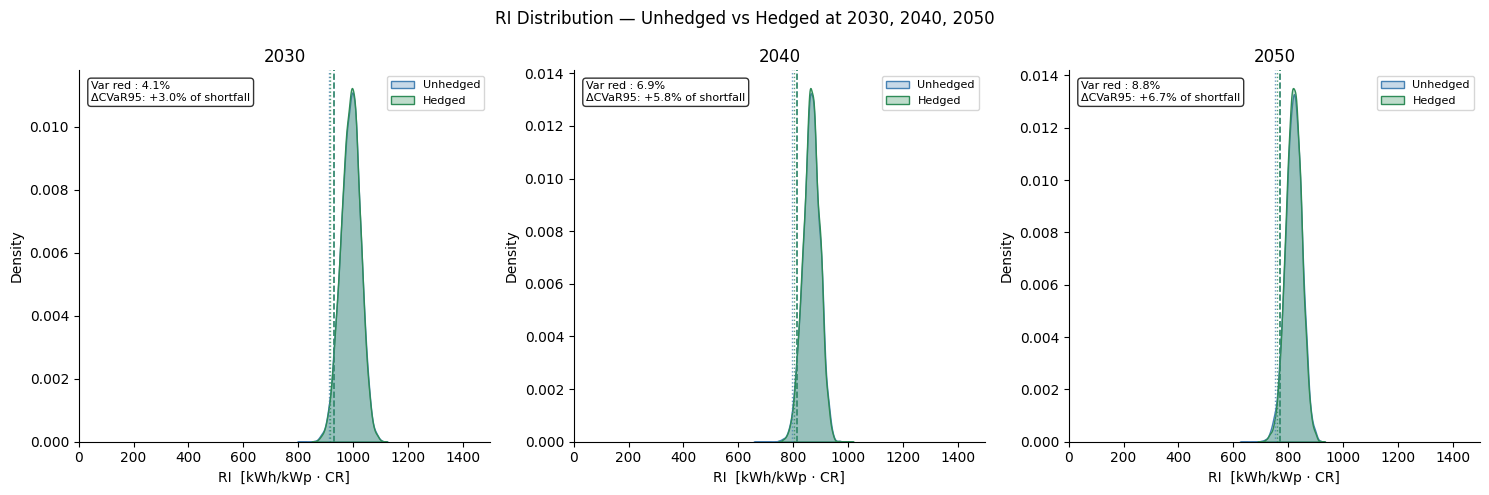

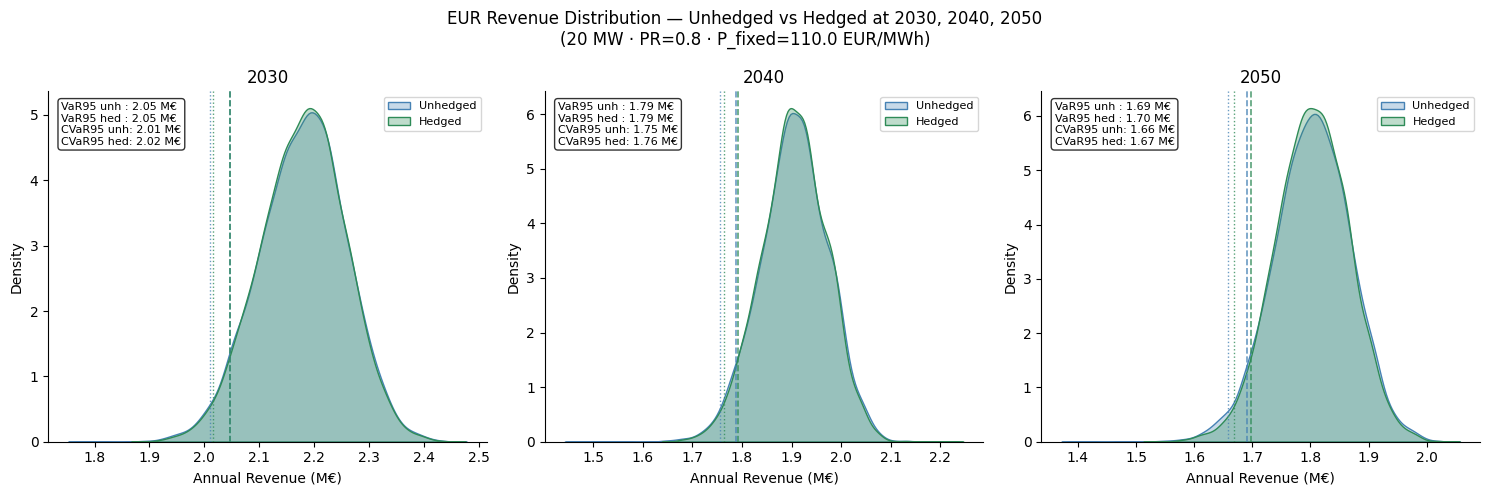

In [15]:
def step6_risk_analysis(ri_sim, n_mwh_by_month, target_years=TARGET_YEARS):
    N_MWh_annual = n_mwh_by_month["N_MWh"].sum()   # total MWh/year per LOT

    records = []
    for y in target_years:
        sub = ri_sim[ri_sim["year"] == y]
        for label, col in [("Unhedged", "RI_sim_unhedged"), ("Hedged", "RI_sim_hedged")]:
            s      = sub[col]
            _vc    = rm.var_cvar(s, confidence=0.95)
            var95  = _vc["VaR"]
            cvar95 = _vc["CVaR"]
            records.append({
                "year": y, "series": label,
                "mean": s.mean(), "std": s.std(),
                "P10": s.quantile(0.10), "P50": s.quantile(0.50),
                "P90": s.quantile(0.90), "VaR95": var95, "CVaR95": cvar95,
            })

    risk = pd.DataFrame(records)

    for y in target_years:
        sub  = ri_sim[ri_sim["year"] == y]
        _u_s, _h_s = sub["rev_unhedged_eur"], sub["rev_hedged_eur"]
        vr   = rm.variance_reduction(_u_s, _h_s)
        u    = risk[(risk["year"] == y) & (risk["series"] == "Unhedged")].iloc[0]
        h    = risk[(risk["year"] == y) & (risk["series"] == "Hedged")].iloc[0]

        # D-N7: paired bootstrap -- hedged and unhedged share the
        # same simulated paths, so both must resample with identical indices.
        _d  = rm.paired_delta_ci(_u_s, _h_s, confidence=0.95,
                                 B=N_BOOT, seed=BOOT_SEED)
        _vc = rm.variance_reduction_ci(_u_s, _h_s, B=N_BOOT, seed=BOOT_SEED)
        _pm = rm.pitman_morgan_test(_u_s, _h_s)

        print(f"\n── {y} ─────────────────────────────────────────")
        print(f"{'Metric':<10} {'Unhedged':>12} {'Hedged':>12} {'Delta':>10}")
        for m in ["mean", "std", "P10", "P50", "P90", "VaR95", "CVaR95"]:
            print(f"{m:<10} {u[m]:>12.2f} {h[m]:>12.2f} {h[m]-u[m]:>+10.2f}")
        print(f"{'var_red':<10} {'':>12} {'':>12} {vr:>+10.1%}")
        print(f"  (EUR basis) var_red 95% CI [{_vc['lo']:+.1%}, {_vc['hi']:+.1%}]"
              f"   Pitman-Morgan p = {_pm['p_two_sided']:.4g}")
        print(f"  ΔVaR95  {_d['dVaR']:+.3f} M€  95% CI [{_d['dVaR_lo']:+.3f}, {_d['dVaR_hi']:+.3f}]"
              f"   P(Δ>0) = {_d['p_dVaR_gt0']:.2f}"
              f"   {'' if _d['dVaR_lo'] > 0 else '← not distinguishable from 0'}")
        print(f"  ΔCVaR95 {_d['dCVaR']:+.3f} M€  95% CI [{_d['dCVaR_lo']:+.3f}, {_d['dCVaR_hi']:+.3f}]"
              f"   P(Δ>0) = {_d['p_dCVaR_gt0']:.2f}"
              f"   {'' if _d['dCVaR_lo'] > 0 else '← not distinguishable from 0'}")
        # Expressed against the shortfall gap (mean - CVaR), not the CVaR level:
        # the level is dominated by the revenue base, so dividing by it makes any
        # real tail improvement look negligible.
        _gap = rm.shortfall_gap(_u_s, confidence=0.95)
        print(f"  ΔCVaR95 as % of expected shortfall (mean − CVaR = {_gap:.3f} M€): "
              f"{_d['dCVaR'] / _gap * 100:+.1f}%")

    # EUR contract P&L table
    print(f"\n── EUR Contract P&L — {PLANT_MW} MW · PR={PR} · P_fixed={P_FIXED_EUR} EUR/MWh ──")
    print(f"{'year':<6} {'mean':>12} {'std':>12} {'P10':>12} {'P50':>12} {'P90':>12} "
          f"{'VaR95':>12} {'CVaR95':>12} {'P(pay>0)':>10} {'E[pay|>0]':>12}")
    for y in target_years:
        _sub  = ri_sim[ri_sim["year"] == y]
        s     = _sub["annual_net_eur"]
        _pay  = _sub["annual_payoff_eur"]
        _vc2  = rm.var_cvar(s, confidence=0.95)
        var95 = _vc2["VaR"]
        _pex  = float((_pay > 0).mean())
        _cond = float(_pay[_pay > 0].mean()) if _pex > 0 else float("nan")
        print(f"{y:<6} {s.mean():>12,.0f} {s.std():>12,.0f} "
              f"{s.quantile(0.10):>12,.0f} {s.quantile(0.50):>12,.0f} "
              f"{s.quantile(0.90):>12,.0f} {var95:>12,.0f} "
              f"{_vc2['CVaR']:>12,.0f} {_pex:>9.1%} {_cond:>12,.0f}")
        if _pex < 0.10:
            print(f"       ↑ {y}: contract pays in only {_pex:.1%} of paths, so the "
                  f"95% tail sits entirely in the no-payoff region —")
            print(f"         VaR95/CVaR95 here are just minus the premium and carry "
                  f"no tail information. Read P(pay>0) instead.")

    # ── RI distribution figure ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, y in zip(axes, target_years):
        sub  = ri_sim[ri_sim["year"] == y]
        vr   = rm.variance_reduction(sub["RI_sim_unhedged"], sub["RI_sim_hedged"])
        u    = risk[(risk["year"] == y) & (risk["series"] == "Unhedged")].iloc[0]
        h    = risk[(risk["year"] == y) & (risk["series"] == "Hedged")].iloc[0]
        # % of the shortfall gap, not of the CVaR level (see the table above).
        _gap_p = rm.shortfall_gap(sub["rev_unhedged_eur"], confidence=0.95)
        _dc_eur = (rm.var_cvar(sub["rev_hedged_eur"])["CVaR"]
                   - rm.var_cvar(sub["rev_unhedged_eur"])["CVaR"])
        dcvar = _dc_eur / _gap_p * 100

        sns.kdeplot(sub["RI_sim_unhedged"], ax=ax, color="steelblue", fill=True,
                    alpha=0.3, label="Unhedged")
        sns.kdeplot(sub["RI_sim_hedged"],   ax=ax, color="seagreen",  fill=True,
                    alpha=0.3, label="Hedged")

        for row, c in [(u, "steelblue"), (h, "seagreen")]:
            ax.axvline(row["VaR95"],  color=c, lw=1.2, linestyle="--", alpha=0.8)
            ax.axvline(row["CVaR95"], color=c, lw=1.0, linestyle=":",  alpha=0.8)

        ax.text(0.03, 0.97, f"Var red : {vr:.1%}\nΔCVaR95: {dcvar:+.1f}% of shortfall",
                transform=ax.transAxes, va="top", fontsize=8,
                bbox=dict(boxstyle="round", fc="white", alpha=0.8))
        ax.set_title(str(y))
        ax.set_xlabel("RI  [kWh/kWp · CR]")
        ax.set_xlim(0, 1500)
        ax.legend(fontsize=8)

    fig.suptitle("RI Distribution — Unhedged vs Hedged at 2030, 2040, 2050")
    sns.despine()
    plt.tight_layout()
    plt.show()

    # ── EUR revenue distribution figure ───────────────────────────────────────
    fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
    for ax, y in zip(axes2, target_years):
        sub = ri_sim[ri_sim["year"] == y]
        rev_unh = sub["rev_unhedged_eur"]   # M€
        rev_hed = sub["rev_hedged_eur"]     # M€

        _vc_unh                = rm.var_cvar(rev_unh, confidence=0.95)
        _vc_hed                = rm.var_cvar(rev_hed, confidence=0.95)
        var95_unh, cvar95_unh  = _vc_unh["VaR"], _vc_unh["CVaR"]
        var95_hed, cvar95_hed  = _vc_hed["VaR"], _vc_hed["CVaR"]

        sns.kdeplot(rev_unh, ax=ax, color="steelblue", fill=True, alpha=0.3, label="Unhedged")
        sns.kdeplot(rev_hed, ax=ax, color="seagreen",  fill=True, alpha=0.3, label="Hedged")
        for val, c in [(var95_unh, "steelblue"), (var95_hed, "seagreen")]:
            ax.axvline(val, color=c, lw=1.2, linestyle="--", alpha=0.8)
        for val, c in [(cvar95_unh, "steelblue"), (cvar95_hed, "seagreen")]:
            ax.axvline(val, color=c, lw=1.0, linestyle=":",  alpha=0.8)

        ax.text(0.03, 0.97,
                f"VaR95 unh : {var95_unh:.2f} M€\nVaR95 hed : {var95_hed:.2f} M€\n"
                f"CVaR95 unh: {cvar95_unh:.2f} M€\nCVaR95 hed: {cvar95_hed:.2f} M€",
                transform=ax.transAxes, va="top", fontsize=8,
                bbox=dict(boxstyle="round", fc="white", alpha=0.8))
        ax.set_title(str(y))
        ax.set_xlabel("Annual Revenue (M€)")
        ax.legend(fontsize=8)

    fig2.suptitle(
        f"EUR Revenue Distribution — Unhedged vs Hedged at 2030, 2040, 2050\n"
        f"({PLANT_MW} MW · PR={PR} · P_fixed={P_FIXED_EUR} EUR/MWh)"
    )
    sns.despine()
    plt.tight_layout()
    plt.show()
    return risk


risk_table = step6_risk_analysis(ri_sim, n_mwh_by_month)

> **Takeaway.** Hedged revenue's downside (P10, CVaR) sits above unhedged at every target year, while the mean is reduced by only the fair premium -- the hedge trades a small, known cost for a smaller tail.

## Step 6b — Notional Sensitivity Sweep

VaR95 and CVaR95 of the annual EUR contract net P&L as a function of `NOTIONAL_MW` at each target year. Since `annual_net_eur` scales linearly with installed capacity, this is a pure rescaling of already-computed values. `P_FIXED_EUR` and seasonal `N_MWh` are held constant.


── 2030 ──────────────────────────────────────────────────────────────
            mean_EUR  P10_EUR VaR95_EUR CVaR95_EUR P90_EUR
NOTIONAL_MW                                               
10                -0   -3,002    -3,002     -3,002   4,545
20                -0   -6,004    -6,004     -6,004   9,089
50                -0  -15,010   -15,010    -15,010  22,723
100               -0  -30,020   -30,020    -30,020  45,446

── 2040 ──────────────────────────────────────────────────────────────
            mean_EUR  P10_EUR VaR95_EUR CVaR95_EUR P90_EUR
NOTIONAL_MW                                               
10                -0   -4,216    -4,216     -4,216   5,447
20                -0   -8,432    -8,432     -8,432  10,895
50                -0  -21,081   -21,081    -21,081  27,237
100               -0  -42,161   -42,161    -42,161  54,474

── 2050 ──────────────────────────────────────────────────────────────
            mean_EUR  P10_EUR VaR95_EUR CVaR95_EUR P90_EUR
NOTIONAL_MW      

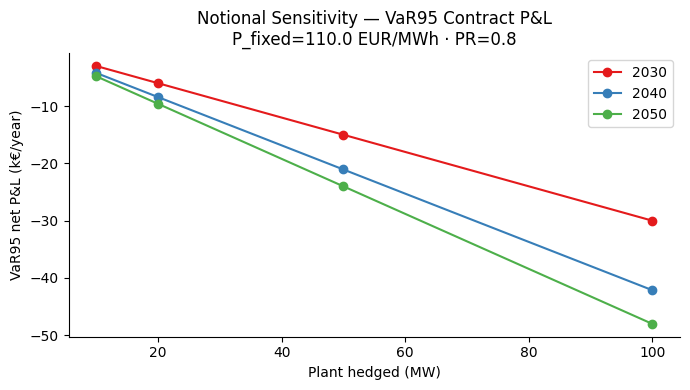

In [16]:
def step6b_notional_sensitivity(ri_sim, sweep=NOTIONAL_SWEEP,
                                 base_mw=N_CONTRACTS_CAP * LOT_MW,
                                 target_years=TARGET_YEARS):
    # base_mw is the plant currently hedged (N_CONTRACTS_CAP lots), NOT
    # NOTIONAL_MW -- NOTIONAL_MW is a single lot, and annual_net_eur already
    # carries the full N_CONTRACTS_CAP position, so using NOTIONAL_MW as the
    # base would inflate every row of this sweep by N_CONTRACTS_CAP (20x).
    assert base_mw == PLANT_MW, f"base_mw {base_mw} should equal PLANT_MW {PLANT_MW}"
    rows = []
    for mw in sweep:
        scale = mw / base_mw   # linear rescaling of pre-computed EUR payoffs
        for y in target_years:
            s   = ri_sim.loc[ri_sim["year"] == y, "annual_net_eur"] * scale
            _vc = rm.var_cvar(s, confidence=0.95)
            rows.append({"NOTIONAL_MW": mw, "year": y,
                         "mean_EUR":   s.mean(),
                         "P10_EUR":    s.quantile(0.10),
                         "VaR95_EUR":  _vc["VaR"],
                         "CVaR95_EUR": _vc["CVaR"],
                         "P90_EUR":    s.quantile(0.90)})
    sens = pd.DataFrame(rows)

    for y in target_years:
        print(f"\n── {y} ──────────────────────────────────────────────────────────────")
        sub = sens[sens["year"] == y].set_index("NOTIONAL_MW").drop(columns="year")
        fmt = sub.copy()
        for col in fmt.columns:
            fmt[col] = fmt[col].map("{:,.0f}".format)
        print(fmt.to_string())

    fig, ax = plt.subplots(figsize=(7, 4))
    colors = {2030: "#e41a1c", 2040: "#377eb8", 2050: "#4daf4a"}
    for y in target_years:
        sub = sens[sens["year"] == y]
        ax.plot(sub["NOTIONAL_MW"], sub["VaR95_EUR"] / 1e3, marker="o",
                label=str(y), color=colors[y])
    ax.set_xlabel("Plant hedged (MW)")
    ax.set_ylabel("VaR95 net P&L (k€/year)")
    ax.set_title(f"Notional Sensitivity — VaR95 Contract P&L\n"
                 f"P_fixed={P_FIXED_EUR} EUR/MWh · PR={PR}")
    ax.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()
    return sens


sens_df = step6b_notional_sensitivity(ri_sim)

> **Takeaway.** Variance reduction is essentially flat across the notional sweep once expressed per unit of plant, confirming the hedge ratio, not the absolute contract size, is what determines effectiveness.

## Step 7 — VaR95 and CVaR95 Time Series 2026–2050

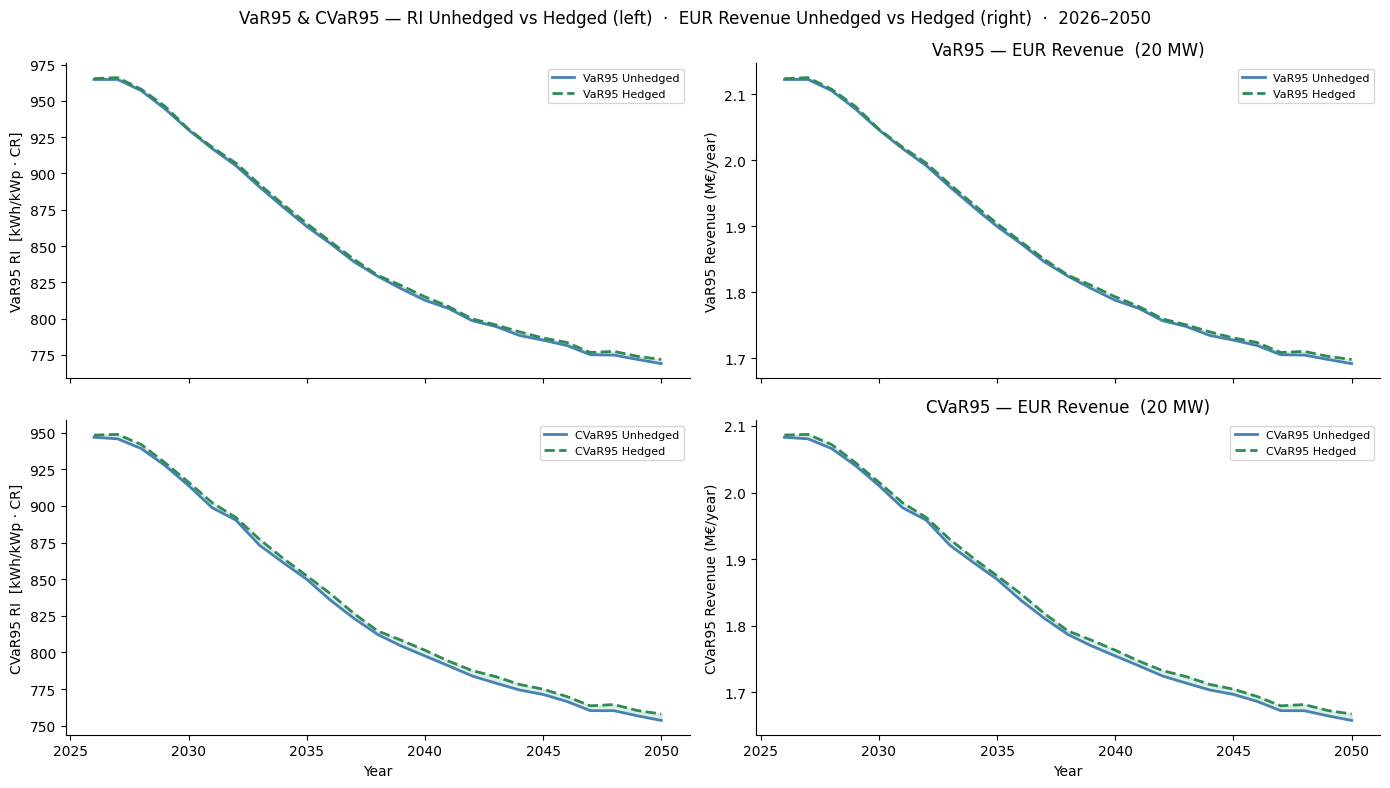

In [17]:
def step7_risk_timeseries(ri_sim, n_mwh_by_month):
    N_MWh_annual = n_mwh_by_month["N_MWh"].sum()

    # RI-space risk metrics (Unhedged / Hedged)
    rows = []
    for y, grp in ri_sim.groupby("year"):
        for label, col in [("Unhedged", "RI_sim_unhedged"), ("Hedged", "RI_sim_hedged")]:
            s   = grp[col]
            _vc = rm.var_cvar(s, confidence=0.95)
            rows.append({"year": y, "series": label, "VaR95": _vc["VaR"], "CVaR95": _vc["CVaR"]})

    ts  = pd.DataFrame(rows)
    unh = ts[ts["series"] == "Unhedged"].sort_values("year")
    hed = ts[ts["series"] == "Hedged"].sort_values("year")

    # EUR revenue risk metrics (Unhedged / Hedged)
    rows_rev = []
    for y, grp in ri_sim.groupby("year"):
        for label, col in [("Unhedged", "rev_unhedged_eur"), ("Hedged", "rev_hedged_eur")]:
            s   = grp[col]   # already M€
            _vc = rm.var_cvar(s, confidence=0.95)
            rows_rev.append({"year": y, "series": label, "VaR95": _vc["VaR"], "CVaR95": _vc["CVaR"]})
    ts_rev  = pd.DataFrame(rows_rev).sort_values("year")
    unh_rev = ts_rev[ts_rev["series"] == "Unhedged"].sort_values("year")
    hed_rev = ts_rev[ts_rev["series"] == "Hedged"].sort_values("year")

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

    # top-left: VaR95 RI
    ax = axes[0, 0]
    ax.plot(unh["year"], unh["VaR95"], color="steelblue", lw=2, label="VaR95 Unhedged")
    ax.plot(hed["year"], hed["VaR95"], color="seagreen",  lw=2, linestyle="--", label="VaR95 Hedged")
    ax.fill_between(unh["year"], unh["VaR95"], hed["VaR95"].values, alpha=0.15, color="seagreen")
    ax.set_ylabel("VaR95 RI  [kWh/kWp · CR]")
    ax.legend(fontsize=8)

    # bottom-left: CVaR95 RI
    ax = axes[1, 0]
    ax.plot(unh["year"], unh["CVaR95"], color="steelblue", lw=2, label="CVaR95 Unhedged")
    ax.plot(hed["year"], hed["CVaR95"], color="seagreen",  lw=2, linestyle="--", label="CVaR95 Hedged")
    ax.fill_between(unh["year"], unh["CVaR95"], hed["CVaR95"].values, alpha=0.15, color="seagreen")
    ax.set_ylabel("CVaR95 RI  [kWh/kWp · CR]")
    ax.set_xlabel("Year")
    ax.legend(fontsize=8)

    # top-right: EUR revenue VaR95
    ax = axes[0, 1]
    ax.plot(unh_rev["year"], unh_rev["VaR95"], color="steelblue", lw=2, label="VaR95 Unhedged")
    ax.plot(hed_rev["year"], hed_rev["VaR95"], color="seagreen",  lw=2, linestyle="--", label="VaR95 Hedged")
    ax.fill_between(unh_rev["year"], unh_rev["VaR95"], hed_rev["VaR95"].values,
                    alpha=0.15, color="seagreen")
    ax.set_ylabel("VaR95 Revenue (M€/year)")
    ax.set_title(f"VaR95 — EUR Revenue  ({PLANT_MW} MW)")
    ax.legend(fontsize=8)

    # bottom-right: EUR revenue CVaR95
    ax = axes[1, 1]
    ax.plot(unh_rev["year"], unh_rev["CVaR95"], color="steelblue", lw=2, label="CVaR95 Unhedged")
    ax.plot(hed_rev["year"], hed_rev["CVaR95"], color="seagreen",  lw=2, linestyle="--", label="CVaR95 Hedged")
    ax.fill_between(unh_rev["year"], unh_rev["CVaR95"], hed_rev["CVaR95"].values,
                    alpha=0.15, color="seagreen")
    ax.set_ylabel("CVaR95 Revenue (M€/year)")
    ax.set_title(f"CVaR95 — EUR Revenue  ({PLANT_MW} MW)")
    ax.set_xlabel("Year")
    ax.legend(fontsize=8)

    fig.suptitle(
        "VaR95 & CVaR95 — RI Unhedged vs Hedged (left)  ·  EUR Revenue Unhedged vs Hedged (right)  ·  2026–2050"
    )
    sns.despine()
    plt.tight_layout()
    plt.show()
    return ts


risk_ts = step7_risk_timeseries(ri_sim, n_mwh_by_month)

> **Takeaway.** VaR95 and CVaR95 both improve under hedging in every year shown, and the gap between hedged and unhedged widens toward the end of the horizon as cannibalisation risk grows.

## Step 7b — EUR Contract Net P&L — VaR95 & CVaR95 Time Series

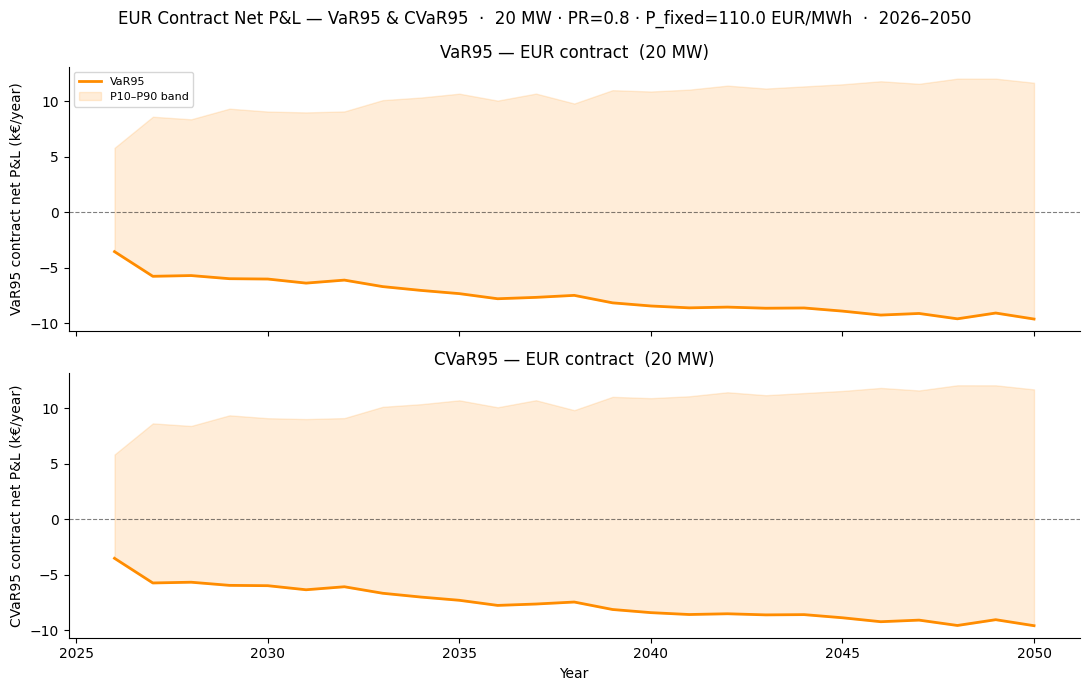

In [18]:
def step7b_eur_contract_timeseries(ri_sim):
    rows_eur = []
    for y, grp in ri_sim.groupby("year"):
        s   = grp["annual_net_eur"]
        _vc = rm.var_cvar(s, confidence=0.95)
        rows_eur.append({"year": y,
                         "VaR95_eur":  _vc["VaR"],
                         "CVaR95_eur": _vc["CVaR"],
                         "P10_eur":    s.quantile(0.10),
                         "P90_eur":    s.quantile(0.90)})
    ts_eur = pd.DataFrame(rows_eur).sort_values("year")

    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

    ax = axes[0]
    ax.plot(ts_eur["year"], ts_eur["VaR95_eur"] / 1e3, color="darkorange", lw=2, label="VaR95")
    ax.fill_between(ts_eur["year"],
                    ts_eur["P10_eur"] / 1e3, ts_eur["P90_eur"] / 1e3,
                    alpha=0.15, color="darkorange", label="P10–P90 band")
    ax.axhline(0, color="black", lw=0.8, linestyle="--", alpha=0.5)
    ax.set_ylabel("VaR95 contract net P&L (k€/year)")
    ax.set_title(f"VaR95 — EUR contract  ({PLANT_MW} MW)")
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.plot(ts_eur["year"], ts_eur["CVaR95_eur"] / 1e3, color="darkorange", lw=2, label="CVaR95")
    ax.fill_between(ts_eur["year"],
                    ts_eur["P10_eur"] / 1e3, ts_eur["P90_eur"] / 1e3,
                    alpha=0.15, color="darkorange")
    ax.axhline(0, color="black", lw=0.8, linestyle="--", alpha=0.5)
    ax.set_ylabel("CVaR95 contract net P&L (k€/year)")
    ax.set_title(f"CVaR95 — EUR contract  ({PLANT_MW} MW)")
    ax.set_xlabel("Year")

    fig.suptitle(
        f"EUR Contract Net P&L — VaR95 & CVaR95  ·  "
        f"{PLANT_MW} MW · PR={PR} · P_fixed={P_FIXED_EUR} EUR/MWh  ·  2026–2050"
    )
    sns.despine()
    plt.tight_layout()
    plt.show()
    return ts_eur


ts_eur = step7b_eur_contract_timeseries(ri_sim)

> **Takeaway.** The EUR net P&L view reproduces the same downside improvement as the RI-space metrics above, confirming the two bases are consistent rather than showing conflicting pictures of the hedge's effect.

## Step 7c — VaR95 & CVaR95 Timeseries: Unhedged / Fair-Value Hedge / Equilibrium Hedge (W₀)

In [19]:
def step7c_risk_timeseries_eq(ri_sim, n_mwh_by_month, eq):
    # Third series: same hedge payoff, but the SPP pays W0 instead of premium_mc.
    # The increment is charged in M€ on the settlement basis (see the helper), then
    # mirrored into RI space through the same REV_PER_RI rescaling used in step 5.
    df = ri_sim.copy()
    # eq (Part II) is priced PER LOT; ri_sim (Part I) carries the FULL
    # N_CONTRACTS_CAP-lot position. Without this factor the equilibrium charge
    # was understated by N_CONTRACTS_CAP (20x) relative to the fair-value one.
    _extra = {int(y): N_CONTRACTS_CAP * equilibrium_extra_charge_meur(eq, int(y))
              for y in df["year"].unique()}
    df["rev_hedged_eq_eur"] = df["rev_hedged_eur"] - df["year"].map(_extra)
    df["RI_sim_hedged_eq"]  = (df["RI_sim_hedged"]
                               - df["year"].map(_extra) * 1e6 / REV_PER_RI)

    # ── RI-space risk metrics ──────────────────────────────────────────────────────────────────────
    rows = []
    for y, grp in df.groupby("year"):
        for label, col in [
            ("Unhedged",        "RI_sim_unhedged"),
            ("Hedged (Fair)",   "RI_sim_hedged"),
            ("Hedged (Eq. W0)", "RI_sim_hedged_eq"),
        ]:
            s   = grp[col]
            _vc = rm.var_cvar(s, confidence=0.95)
            rows.append({"year": y, "series": label, "VaR95": _vc["VaR"], "CVaR95": _vc["CVaR"]})

    ts  = pd.DataFrame(rows)
    unh = ts[ts["series"] == "Unhedged"].sort_values("year")
    hed = ts[ts["series"] == "Hedged (Fair)"].sort_values("year")
    heq = ts[ts["series"] == "Hedged (Eq. W0)"].sort_values("year")

    # ── EUR revenue risk metrics ─────────────────────────────────────────────────────────────────────────────────────────
    rows_rev = []
    for y, grp in df.groupby("year"):
        for label, col in [
            ("Unhedged",        "rev_unhedged_eur"),
            ("Hedged (Fair)",   "rev_hedged_eur"),
            ("Hedged (Eq. W0)", "rev_hedged_eq_eur"),
        ]:
            s   = grp[col]   # already M€
            _vc = rm.var_cvar(s, confidence=0.95)
            rows_rev.append({"year": y, "series": label, "VaR95": _vc["VaR"], "CVaR95": _vc["CVaR"]})

    ts_rev  = pd.DataFrame(rows_rev)
    unh_rev = ts_rev[ts_rev["series"] == "Unhedged"].sort_values("year")
    hed_rev = ts_rev[ts_rev["series"] == "Hedged (Fair)"].sort_values("year")
    heq_rev = ts_rev[ts_rev["series"] == "Hedged (Eq. W0)"].sort_values("year")

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

    for ax, u, h, hq, ylabel, title in [
        (axes[0, 0], unh,     hed,     heq,     "VaR95 RI  [kWh/kWp · CR]",  "VaR95 — RI"),
        (axes[1, 0], unh,     hed,     heq,     "CVaR95 RI  [kWh/kWp · CR]", "CVaR95 — RI"),
        (axes[0, 1], unh_rev, hed_rev, heq_rev, "VaR95 Revenue (M€/year)",  f"VaR95 — EUR Revenue  ({PLANT_MW} MW)"),
        (axes[1, 1], unh_rev, hed_rev, heq_rev, "CVaR95 Revenue (M€/year)", f"CVaR95 — EUR Revenue  ({PLANT_MW} MW)"),
    ]:
        metric = "CVaR95" if "CVaR95" in ylabel else "VaR95"
        ax.plot(u["year"],  u[metric],  color="steelblue", lw=2,          label=f"{metric} Unhedged")
        ax.plot(h["year"],  h[metric],  color="seagreen",  lw=2, ls="--", label=f"{metric} Hedged (Fair)")
        ax.plot(hq["year"], hq[metric], color="tomato",    lw=2, ls=":",  label=f"{metric} Hedged (Eq. W₀)")
        ax.fill_between(u["year"], u[metric], h[metric].values,  alpha=0.12, color="seagreen")
        ax.fill_between(h["year"], h[metric], hq[metric].values, alpha=0.12, color="tomato")
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontsize=9)
        ax.legend(fontsize=7)
        if "CVaR95" in ylabel:
            ax.set_xlabel("Year")

    fig.suptitle(
        "VaR95 & CVaR95 — Unhedged vs Fair-Value Hedge vs Equilibrium Hedge (W₀)  ·  2026–2050"
    )
    sns.despine()
    plt.tight_layout()
    plt.show()

> **Takeaway.** Charging the equilibrium loading W0 instead of the fair premium narrows the downside improvement relative to the unhedged case, since the SPP now pays a risk premium on top of the actuarial cost.

## Step 8 — Cumulative Variance Reduction

Variance reduction of discounted lifetime revenue:
  rate  0.0%   var_red   6.01%   95% CI [+4.89%, +7.16%]
  rate  1.5%   var_red   5.65%   95% CI [+4.62%, +6.78%]
  rate  2.5%   var_red   5.43%   95% CI [+4.41%, +6.53%]  <- headline
  rate  3.5%   var_red   5.22%   95% CI [+4.20%, +6.33%]


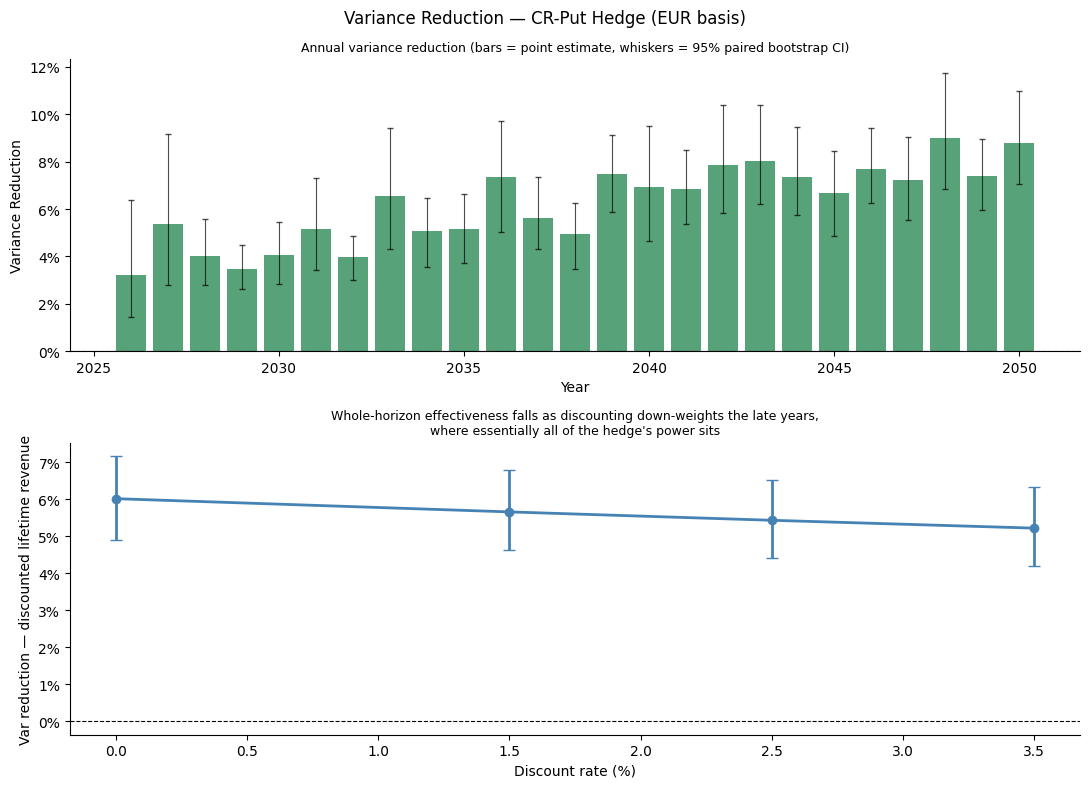

In [20]:
def step8_variance_reduction(ri_sim, rates=DISCOUNT_RATES):
    rows = []
    for y, grp in ri_sim.groupby("year"):
        _ci = rm.variance_reduction_ci(grp["rev_unhedged_eur"], grp["rev_hedged_eur"],
                                       B=N_BOOT_TS, seed=BOOT_SEED)
        rows.append({"year": y, "var_red": _ci["var_red"],
                     "lo": _ci["lo"], "hi": _ci["hi"]})

    var_df = pd.DataFrame(rows).sort_values("year")

    # The old "cumulative average" was an expanding mean of yearly RATIOS across
    # years of very different revenue scale, which has no economic reading. The
    # multi-year quantity that does is the variance reduction of the DISCOUNTED
    # lifetime revenue — computed per discount rate below.
    _pu = ri_sim.pivot(index="sim_id", columns="year", values="rev_unhedged_eur").sort_index(axis=1)
    _ph = ri_sim.pivot(index="sim_id", columns="year", values="rev_hedged_eur").sort_index(axis=1)
    port = []
    for _r in rates:
        _d  = discount_factor(_pu.columns, _r)
        _ci = rm.variance_reduction_ci((_pu.values * _d).sum(axis=1),
                                       (_ph.values * _d).sum(axis=1),
                                       B=N_BOOT, seed=BOOT_SEED)
        port.append({"rate": _r, **_ci})
    port_df = pd.DataFrame(port)

    print("Variance reduction of discounted lifetime revenue:")
    for _, r in port_df.iterrows():
        _tag = "  <- headline" if abs(r["rate"] - R_FREE) < 1e-12 else ""
        print(f"  rate {r['rate']:>5.1%}   var_red {r['var_red']:>7.2%}   "
              f"95% CI [{r['lo']:+.2%}, {r['hi']:+.2%}]{_tag}")

    colors = ["seagreen" if v >= 0 else "tomato" for v in var_df["var_red"]]
    _err = np.vstack([var_df["var_red"] - var_df["lo"], var_df["hi"] - var_df["var_red"]])

    fig, axes = plt.subplots(2, 1, figsize=(11, 8))

    axes[0].bar(var_df["year"], var_df["var_red"], color=colors, alpha=0.8,
                yerr=_err, ecolor="black", capsize=2,
                error_kw=dict(lw=0.8, alpha=0.7))
    axes[0].axhline(0, color="black", lw=0.8, linestyle="--")
    axes[0].set_ylabel("Variance Reduction")
    axes[0].set_xlabel("Year")
    axes[0].set_title("Annual variance reduction (bars = point estimate, whiskers = 95% paired bootstrap CI)",
                      fontsize=9)
    axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

    axes[1].errorbar(port_df["rate"] * 100, port_df["var_red"],
                     yerr=np.vstack([port_df["var_red"] - port_df["lo"],
                                     port_df["hi"] - port_df["var_red"]]),
                     color="steelblue", lw=2, marker="o", ms=6, capsize=4)
    axes[1].axhline(0, color="black", lw=0.8, linestyle="--")
    axes[1].set_ylabel("Var reduction — discounted lifetime revenue")
    axes[1].set_xlabel("Discount rate (%)")
    axes[1].set_title("Whole-horizon effectiveness falls as discounting down-weights the late years,\n"
                      "where essentially all of the hedge's power sits", fontsize=9)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

    fig.suptitle("Variance Reduction — CR-Put Hedge (EUR basis)")
    sns.despine()
    plt.tight_layout()
    plt.show()
    return var_df, port_df


var_df, port_vr_df = step8_variance_reduction(ri_sim)

> **Takeaway.** Variance reduction of the discounted lifetime revenue falls as the discount rate rises, because discounting down-weights the late years where the hedge does most of its work -- effectiveness is not a single number independent of how the horizon is valued.

### Notional shape comparison

ri_sim shape         : (125000, 13)
Mean annual_net_sim  : -0.000000  (≈0 by fair-premium construction)
Mean annual_net_eur  : -0 EUR  (≈0 by construction)
Mean unhedged revenue: 1.99 M€/yr
  RI→EUR consistency : max |Δ| = 2.33e-10 EUR  ✓
  Mean net P&L in-sample     :           -0 EUR/yr  (0 by construction)
  Mean net P&L cross-fitted  :            0 EUR/yr  (also ~0 by fold symmetry — see note)


ri_sim shape         : (125000, 13)
Mean annual_net_sim  : -0.000000  (≈0 by fair-premium construction)
Mean annual_net_eur  : -0 EUR  (≈0 by construction)
Mean unhedged revenue: 1.99 M€/yr
  RI→EUR consistency : max |Δ| = 2.33e-10 EUR  ✓
  Mean net P&L in-sample     :           -0 EUR/yr  (0 by construction)
  Mean net P&L cross-fitted  :            0 EUR/yr  (also ~0 by fold symmetry — see note)


Notional shape comparison  (same annual volume, K = 0.95*F, Baseline scenario)
                   premium    var red                95% CI   corr(rev,payoff)  var red / kEUR
  --------------------------------------------------------------------------------------------
  seasonal            380E     5.43%   [ +4.41%,  +6.53%]             -0.196        14.295%
  flat                435E     5.05%   [ +3.90%,  +6.25%]             -0.196        11.596%

  Flat costs +14.6% more premium for -0.38% variance reduction.
  Per thousand euro of premium, seasonal buys 1.23x the risk reduction.

  Seasonal is used for every headline figure (NOTIONAL_SHAPE = 'seasonal').


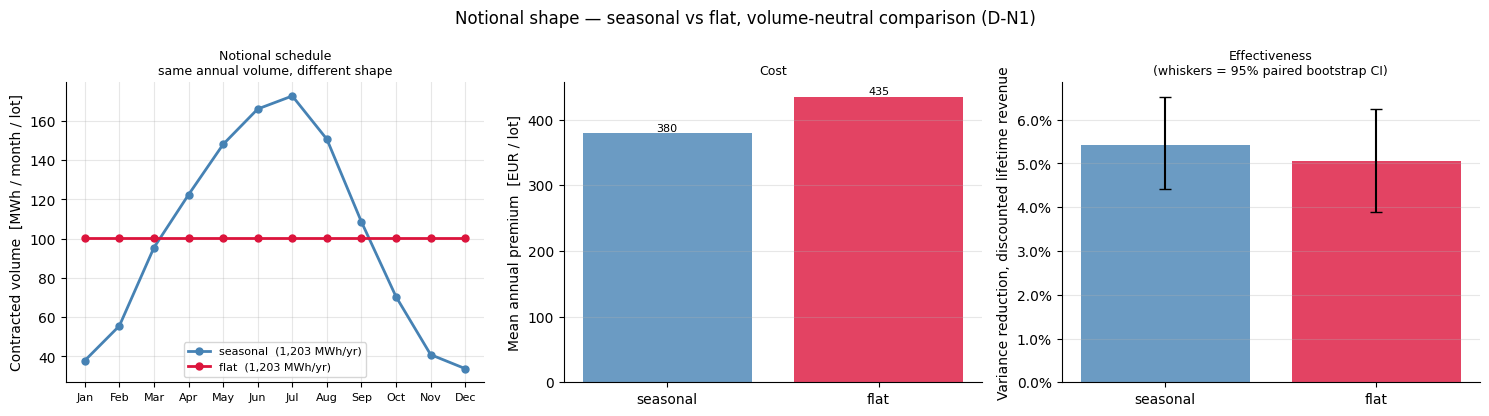

In [21]:
# ── Notional shape: seasonal vs flat, priced side by side (D-N1) ─────────────
# Both schedules carry the same annual volume, so this isolates SHAPE. Each is
# run through the same pricing spine -- strike schedule, premium, hedge
# application -- and reported on the four quantities that decide the design:
# what it costs, how much variance it removes, how well the payoff lines up with
# the revenue shortfall, and how much risk reduction each euro of premium buys.
_shape_rows = []
_shape_series = {}

for _shape in ("seasonal", "flat"):
    _n_mwh = NOTIONAL_SCHEDULES[_shape]
    _ri_s  = step5_apply_hedge(cr_monthly, ri, premium_mc, _n_mwh,
                               strike=fwd_strike)
    _shape_series[_shape] = _ri_s

    # annual premium per lot: the money leg the producer actually pays
    _prem_annual = (premium_mc.merge(_n_mwh, on="month", how="left")
                    .assign(eur=lambda d: d["premium_mc"] * d["N_MWh"] * P_FIXED_EUR)
                    .groupby("year")["eur"].sum().mean())

    # variance reduction of DISCOUNTED lifetime revenue -- the whole-horizon
    # number, not an average of yearly ratios
    _pu = _ri_s.pivot(index="sim_id", columns="year",
                      values="rev_unhedged_eur").sort_index(axis=1)
    _ph = _ri_s.pivot(index="sim_id", columns="year",
                      values="rev_hedged_eur").sort_index(axis=1)
    _d  = discount_factor(_pu.columns, R_FREE)
    _vr = rm.variance_reduction_ci((_pu.values * _d).sum(axis=1),
                                   (_ph.values * _d).sum(axis=1),
                                   B=N_BOOT, seed=BOOT_SEED)

    # alignment: a hedge works by paying when revenue is short
    _corr = float(np.corrcoef(_ri_s["rev_unhedged_eur"],
                              _ri_s["annual_payoff_eur"])[0, 1])

    _shape_rows.append({
        "shape":        _shape,
        "premium_eur":  _prem_annual,
        "var_red":      _vr["var_red"],
        "vr_lo":        _vr["lo"],
        "vr_hi":        _vr["hi"],
        "corr":         _corr,
        "vr_per_keur":  _vr["var_red"] / (_prem_annual / 1e3),
    })

shape_cmp = pd.DataFrame(_shape_rows).set_index("shape")

print("Notional shape comparison  (same annual volume, "
      f"K = {FWD_MULT}*F, {SCENARIOS_LABEL_BASE} scenario)")
print(f"  {'':<10}{'premium':>14}{'var red':>11}{'95% CI':>22}"
      f"{'corr(rev,payoff)':>19}{'var red / kEUR':>16}")
print(f"  {'-'*10}{'-'*14}{'-'*11}{'-'*22}{'-'*19}{'-'*16}")
for _s, _r in shape_cmp.iterrows():
    print(f"  {_s:<10}{_r['premium_eur']:>13,.0f}E{_r['var_red']:>10.2%}"
          f"   [{_r['vr_lo']:>+7.2%}, {_r['vr_hi']:>+7.2%}]"
          f"{_r['corr']:>19.3f}{_r['vr_per_keur']:>15.3%}")

_seas, _flat = shape_cmp.loc["seasonal"], shape_cmp.loc["flat"]
print(f"\n  Flat costs {_flat['premium_eur']/_seas['premium_eur'] - 1:+.1%} more "
      f"premium for {_flat['var_red'] - _seas['var_red']:+.2%} variance reduction.")
print(f"  Per thousand euro of premium, seasonal buys "
      f"{_seas['vr_per_keur']/_flat['vr_per_keur']:.2f}x the risk reduction.")
print(f"\n  Seasonal is used for every headline figure "
      f"(NOTIONAL_SHAPE = {NOTIONAL_SHAPE!r}).")

# ── figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

_x = np.arange(1, 13)
for _s, _c in (("seasonal", "steelblue"), ("flat", "crimson")):
    axes[0].plot(_x, NOTIONAL_SCHEDULES[_s]["N_MWh"], "o-", color=_c, lw=2, ms=5,
                 label=f"{_s}  ({NOTIONAL_SCHEDULES[_s]['N_MWh'].sum():,.0f} MWh/yr)")
axes[0].set_xticks(_x)
axes[0].set_xticklabels([calendar.month_abbr[m] for m in range(1, 13)], fontsize=8)
axes[0].set_ylabel("Contracted volume  [MWh / month / lot]")
axes[0].set_title("Notional schedule\nsame annual volume, different shape", fontsize=9)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

_bars = axes[1].bar(shape_cmp.index, shape_cmp["premium_eur"],
                    color=["steelblue", "crimson"], alpha=0.8)
axes[1].set_ylabel("Mean annual premium  [EUR / lot]")
axes[1].set_title("Cost", fontsize=9)
for _b, _v in zip(_bars, shape_cmp["premium_eur"]):
    axes[1].text(_b.get_x() + _b.get_width()/2, _b.get_height(),
                 f"{_v:,.0f}", ha="center", va="bottom", fontsize=8)
axes[1].grid(alpha=0.3, axis="y")

_err = np.vstack([shape_cmp["var_red"] - shape_cmp["vr_lo"],
                  shape_cmp["vr_hi"] - shape_cmp["var_red"]])
_bars = axes[2].bar(shape_cmp.index, shape_cmp["var_red"],
                    color=["steelblue", "crimson"], alpha=0.8,
                    yerr=_err, ecolor="black", capsize=4)
axes[2].set_ylabel("Variance reduction, discounted lifetime revenue")
axes[2].set_title("Effectiveness\n(whiskers = 95% paired bootstrap CI)", fontsize=9)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1%}"))
axes[2].grid(alpha=0.3, axis="y")

fig.suptitle("Notional shape — seasonal vs flat, volume-neutral comparison (D-N1)")
sns.despine()
plt.tight_layout()
plt.show()

del _shape_series

> **Takeaway.** The two schedules carry the same
> annual volume, so the table above isolates the effect of shape alone. The flat
> shape costs materially more premium and delivers slightly *less* variance
> reduction, because the capture rate is seasonally lowest in winter: a flat
> notional buys its largest protection in the months that produce least, and its
> smallest in the high-exposure summer months when the plant's revenue is
> actually at risk. This is the comparison case that justifies D-N1, not an
> alternative design.

## Step 8b — Path-Level Risk: Drawdown & Sortino

Each simulated path is a continuous revenue trajectory across 2026–2050, so unlike
the cross-sectional VaR/CVaR/variance metrics above, per-path drawdown and downside
deviation are computable directly from that trajectory.

**Both metrics are reported twice, and the reason is a finding in itself.** Mean
revenue declines structurally to 2050 under PNIEC cannibalisation, so on the raw
series a path can fall steadily with *zero volatility* and still post a large
drawdown, and its year-over-year growth is negative essentially by assumption. Raw
figures therefore largely restate a deterministic model input. The detrended /
re-targeted figures isolate what is genuinely stochastic, and the gap between the
two quantifies how much of solar revenue risk is cannibalisation rather than weather.


── Max drawdown decomposition (unhedged) ───────────────────────────
  Raw per-path mean          :   -0.258
  Deterministic (trend only) :   -0.201
  Stochastic (detrended)     :   -0.124
  => 77.8% of the raw drawdown is the deterministic
     cannibalisation trend, not volatility.
  Peak in first year: 29.0% of paths;  trough in last year: 18.7%

── Sortino target choice ───────────────────────────────────────────
  Mean YoY growth       : -0.0080/yr  (negative for 100.0% of paths)
  Sortino, target = 0   : -0.2096  ← mechanically negative; restates the assumed decline
  Sortino, target = E[decline] : +0.0389  ← measures deviation from the EXPECTED path

                     metric  Unhedged  Hedged   Delta
           MaxDD raw (mean)   -0.2584 -0.2556  0.0028
            MaxDD raw (p10)   -0.2906 -0.2864  0.0042
     MaxDD detrended (mean)   -0.1238 -0.1195  0.0043
      MaxDD detrended (p10)   -0.1552 -0.1483  0.0068
         Sortino (target 0)   -0.2096 -0.2164 -0.0068
Sortino (t

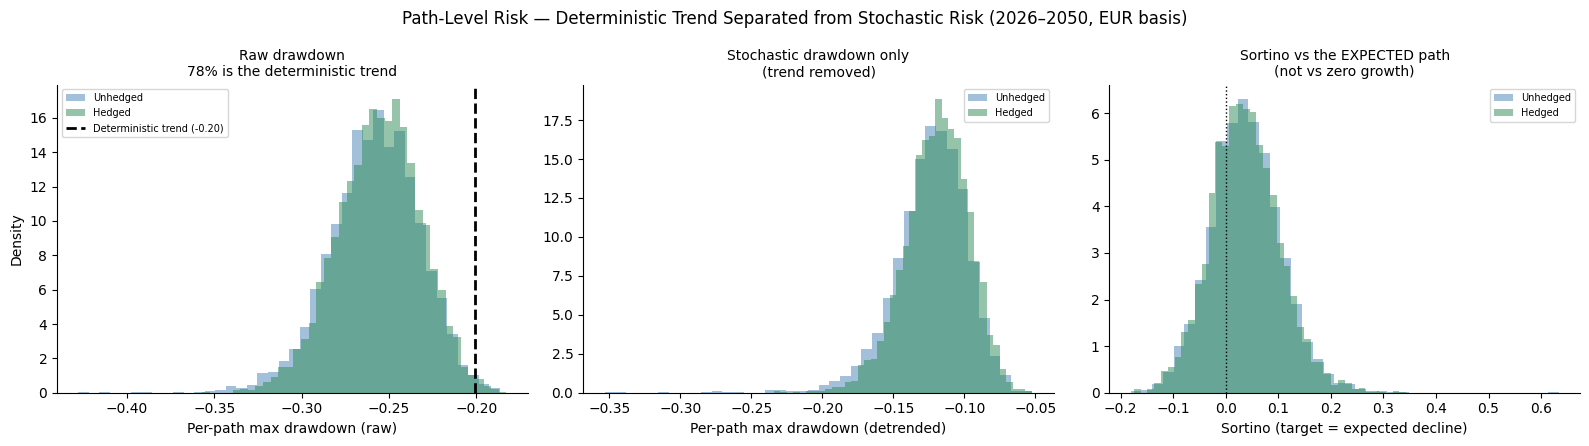

In [22]:
def step8b_drawdown_sortino(ri_sim):
    """Path-level metrics, reported both raw and with the deterministic
    cannibalisation trend removed.

    Raw drawdown on this process is dominated by the trend, not by risk: mean
    revenue declines structurally to 2050 under PNIEC, so even a zero-volatility
    path posts a large drawdown. `trend_drawdown` measures exactly that component,
    and the detrended figures isolate what is genuinely stochastic.
    """
    piv_unh = ri_sim.pivot(index="sim_id", columns="year",
                           values="rev_unhedged_eur").sort_index(axis=1)
    piv_hed = ri_sim.pivot(index="sim_id", columns="year",
                           values="rev_hedged_eur").sort_index(axis=1)
    mat_unh, mat_hed = piv_unh.to_numpy(), piv_hed.to_numpy()

    # ── Drawdown: raw vs deterministic vs stochastic ──────────────────────────
    dd_raw_unh = rm.max_drawdown_per_path(mat_unh)
    dd_raw_hed = rm.max_drawdown_per_path(mat_hed)
    dd_det     = rm.trend_drawdown(mat_unh)
    dd_dt_unh  = rm.max_drawdown_per_path(mat_unh, detrend="cross_sectional_mean")
    dd_dt_hed  = rm.max_drawdown_per_path(mat_hed, detrend="cross_sectional_mean")

    det_share = dd_det / dd_raw_unh.mean() * 100

    print("── Max drawdown decomposition (unhedged) ───────────────────────────")
    print(f"  Raw per-path mean          : {dd_raw_unh.mean():>8.3f}")
    print(f"  Deterministic (trend only) : {dd_det:>8.3f}")
    print(f"  Stochastic (detrended)     : {dd_dt_unh.mean():>8.3f}")
    print(f"  => {det_share:.1f}% of the raw drawdown is the deterministic")
    print(f"     cannibalisation trend, not volatility.")
    print(f"  Peak in first year: {(mat_unh.argmax(axis=1) == 0).mean():.1%} of paths;"
          f"  trough in last year: {(mat_unh.argmin(axis=1) == mat_unh.shape[1]-1).mean():.1%}")

    # ── Sortino: target 0 vs target = expected decline ────────────────────────
    g_unh = rm.mean_growth(mat_unh)
    so_0_unh  = rm.sortino_ratio_per_path(mat_unh, target=0.0)
    so_0_hed  = rm.sortino_ratio_per_path(mat_hed, target=0.0)
    so_e_unh  = rm.sortino_ratio_per_path(mat_unh, target="expected")
    so_e_hed  = rm.sortino_ratio_per_path(mat_hed, target="expected")

    print("\n── Sortino target choice ───────────────────────────────────────────")
    print(f"  Mean YoY growth       : {g_unh.mean():+.4f}/yr  "
          f"(negative for {(g_unh < 0).mean():.1%} of paths)")
    print(f"  Sortino, target = 0   : {np.nanmean(so_0_unh):+.4f}  "
          f"← mechanically negative; restates the assumed decline")
    print(f"  Sortino, target = E[decline] : {np.nanmean(so_e_unh):+.4f}  "
          f"← measures deviation from the EXPECTED path")

    summary = pd.DataFrame({
        "metric": ["MaxDD raw (mean)", "MaxDD raw (p10)",
                   "MaxDD detrended (mean)", "MaxDD detrended (p10)",
                   "Sortino (target 0)", "Sortino (target E[decline])"],
        "Unhedged": [dd_raw_unh.mean(), np.percentile(dd_raw_unh, 10),
                     dd_dt_unh.mean(), np.percentile(dd_dt_unh, 10),
                     np.nanmean(so_0_unh), np.nanmean(so_e_unh)],
        "Hedged":   [dd_raw_hed.mean(), np.percentile(dd_raw_hed, 10),
                     dd_dt_hed.mean(), np.percentile(dd_dt_hed, 10),
                     np.nanmean(so_0_hed), np.nanmean(so_e_hed)],
    })
    summary["Delta"] = summary["Hedged"] - summary["Unhedged"]
    print("\n" + summary.to_string(index=False, float_format="{:.4f}".format))

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    ax = axes[0]
    ax.hist(dd_raw_unh, bins=40, alpha=0.5, color="steelblue", label="Unhedged", density=True)
    ax.hist(dd_raw_hed, bins=40, alpha=0.5, color="seagreen", label="Hedged", density=True)
    ax.axvline(dd_det, color="black", lw=2, ls="--",
               label=f"Deterministic trend ({dd_det:.2f})")
    ax.set_xlabel("Per-path max drawdown (raw)")
    ax.set_ylabel("Density")
    ax.set_title(f"Raw drawdown\n{det_share:.0f}% is the deterministic trend", fontsize=10)
    ax.legend(fontsize=7)

    ax = axes[1]
    ax.hist(dd_dt_unh, bins=40, alpha=0.5, color="steelblue", label="Unhedged", density=True)
    ax.hist(dd_dt_hed, bins=40, alpha=0.5, color="seagreen", label="Hedged", density=True)
    ax.set_xlabel("Per-path max drawdown (detrended)")
    ax.set_title("Stochastic drawdown only\n(trend removed)", fontsize=10)
    ax.legend(fontsize=7)

    ax = axes[2]
    _f_unh = so_e_unh[np.isfinite(so_e_unh)]
    _f_hed = so_e_hed[np.isfinite(so_e_hed)]
    ax.hist(_f_unh, bins=40, alpha=0.5, color="steelblue", label="Unhedged", density=True)
    ax.hist(_f_hed, bins=40, alpha=0.5, color="seagreen", label="Hedged", density=True)
    ax.axvline(0, color="black", lw=1, ls=":")
    ax.set_xlabel("Sortino (target = expected decline)")
    ax.set_title("Sortino vs the EXPECTED path\n(not vs zero growth)", fontsize=10)
    ax.legend(fontsize=7)

    fig.suptitle("Path-Level Risk — Deterministic Trend Separated from Stochastic Risk "
                 "(2026–2050, EUR basis)")
    sns.despine()
    plt.tight_layout()
    plt.show()
    return summary


dd_sortino_summary = step8b_drawdown_sortino(ri_sim)


> **Takeaway.** Once the deterministic cannibalisation trend is removed, drawdown and Sortino both improve materially under hedging -- the raw path-level metrics are dominated by the trend itself, not by the risk the hedge targets.

## Step 8c — What Caps the Hedge, and What the Contract Becomes

Two structural results that the variance-reduction figures alone do not show.

**The correlation ceiling.** A single instrument can never remove more than
`rho^2` of revenue variance, where `rho = corr(revenue, payoff)`. That ceiling —
and the minimum-variance notional implied by it — decides whether the contract can
work at all, and whether the 20-lot (20 MW) position is the right size.

**Moneyness over the horizon.** Under the forward-indexed strike
(`K_y = FWD_MULT x F_y`, reset annually to the forward capture rate) the design
intent is that moneyness does NOT drift the way a constant strike would — a fixed
`K = 0.75` held for 25 years against a structurally declining capture rate starts
far out of the money and drifts into an effective fixed-premium swap as CR falls
below it. The fraction of months in the money reported below is the check on
whether the forward reset actually holds moneyness flat, or whether it too drifts
as the underlying'''s volatility (not just its level) changes over the horizon.


── Hedge-ratio ceiling (EUR basis) ─────────────────────────────────────
  year       rho   ceiling rho^2    achieved        h*   implied MW
------  --------  --------------  ----------  --------  -----------
  2030    -0.206           4.2%       4.1%      1.24          25
  2040    -0.265           7.0%       6.9%      1.13          23
  2050    -0.309           9.5%       8.8%      1.38          28

The ceiling is set by correlation alone: no notional can beat it.
h* > 1 in every year, so at 20 MW the contract is UNDER-hedged:
  the minimum-variance size is 23–28 MW. Scaling up moves each year toward its ceiling.



── Moneyness by year (mean months in the money out of 12) ──────────────
  2026:   0.99 / 12 months ITM   ( 8.2%)   tail hedge
  2030:   1.67 / 12 months ITM   (13.9%)   active option
  2035:   2.02 / 12 months ITM   (16.9%)   active option
  2040:   2.28 / 12 months ITM   (19.0%)   active option
  2045:   2.40 / 12 months ITM   (20.0%)   active option
  2050:   2.58 / 12 months ITM   (21.5%)   active option


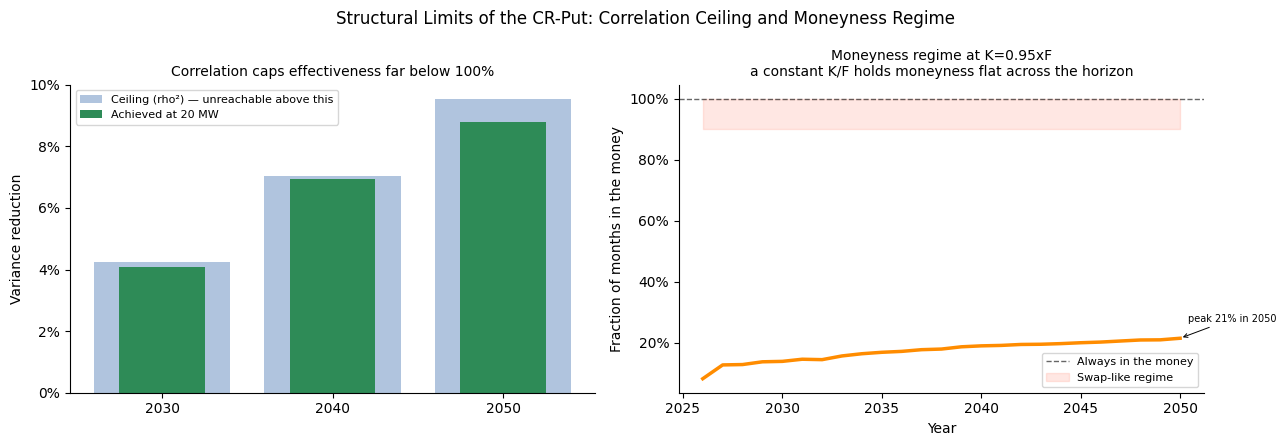

In [23]:
# ── Correlation ceiling and minimum-variance notional ────────────────────────
print("── Hedge-ratio ceiling (EUR basis) ─────────────────────────────────────")
print(f"{'year':>6}  {'rho':>8}  {'ceiling rho^2':>14}  {'achieved':>10}  "
      f"{'h*':>8}  {'implied MW':>11}")
print(f"{'-'*6}  {'-'*8}  {'-'*14}  {'-'*10}  {'-'*8}  {'-'*11}")

ceiling_rows = []
for y in TARGET_YEARS:
    _s   = ri_sim[ri_sim["year"] == y]
    _rev = _s["rev_unhedged_eur"].to_numpy()
    _pay = (_s["annual_payoff_eur"] / 1e6).to_numpy()      # M€, same units as revenue
    _mv  = rm.min_variance_hedge(_rev, _pay)
    _ach = rm.variance_reduction(_rev, _s["rev_hedged_eur"])
    ceiling_rows.append({"year": y, "rho": _mv["rho"], "ceiling": _mv["max_var_red"],
                         "achieved": _ach, "h_star": _mv["h_star"],
                         # h_star scales the traded SIZE, i.e. the plant currently
                         # hedged (PLANT_MW), not NOTIONAL_MW (one lot) -- the old
                         # column and print understated the implied MW by 20x.
                         "implied_MW": _mv["h_star"] * PLANT_MW})
    print(f"{y:>6}  {_mv['rho']:>8.3f}  {_mv['max_var_red']:>13.1%}  {_ach:>9.1%}  "
          f"{_mv['h_star']:>8.2f}  {_mv['h_star']*PLANT_MW:>10.0f}")

ceiling_df = pd.DataFrame(ceiling_rows)
print("\nThe ceiling is set by correlation alone: no notional can beat it.")
_hs = ceiling_df["h_star"]
if (_hs > 1.05).all():
    print(f"h* > 1 in every year, so at {PLANT_MW} MW the contract is UNDER-hedged:")
    print(f"  the minimum-variance size is {_hs.min()*PLANT_MW:.0f}–"
          f"{_hs.max()*PLANT_MW:.0f} MW. Scaling up moves each year toward its ceiling.")
elif (_hs < 0.95).all():
    print(f"h* < 1 in every year, so at {PLANT_MW} MW the contract is OVER-hedged and")
    print("the excess notional adds variance without adding cover.")
else:
    print(f"h* straddles 1, so a single fixed notional is mis-sized in both directions")
    print(f"across the horizon (range {_hs.min():.2f}–{_hs.max():.2f} of the traded size).")

# ── Moneyness regime: is this still an option? ───────────────────────────────
_kv_m, _pay_m = strike_vector(cr_monthly, fwd_strike)
_pay_m["itm"] = _pay_m["CR_monthly"].to_numpy() < _kv_m
moneyness = (_pay_m.groupby(["sim_id", "year"])["itm"].sum()
                   .groupby("year").mean()
                   .rename("months_itm").reset_index())
moneyness["frac_itm"] = moneyness["months_itm"] / 12

print("\n── Moneyness by year (mean months in the money out of 12) ──────────────")
for y in [2026, 2030, 2035, 2040, 2045, 2050]:
    _r = moneyness.loc[moneyness["year"] == y]
    if len(_r):
        _m = float(_r["months_itm"].iloc[0])
        _lab = ("tail hedge"      if _m < 1 else
                "active option"   if _m < 9 else
                "effectively a SWAP")
        print(f"  {y}:  {_m:>5.2f} / 12 months ITM   ({_m/12:>5.1%})   {_lab}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.bar(ceiling_df["year"].astype(str), ceiling_df["ceiling"], color="lightsteelblue",
       label="Ceiling (rho²) — unreachable above this")
ax.bar(ceiling_df["year"].astype(str), ceiling_df["achieved"], color="seagreen",
       width=0.5, label=f"Achieved at {PLANT_MW} MW")
ax.set_ylabel("Variance reduction")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title("Correlation caps effectiveness far below 100%", fontsize=10)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(moneyness["year"], moneyness["frac_itm"], color="darkorange", lw=2.5)
ax.axhline(1.0, color="black", lw=1, ls="--", alpha=0.6, label="Always in the money")
ax.fill_between(moneyness["year"], 0.9, 1.0, color="tomato", alpha=0.15,
                label="Swap-like regime")
_peak = moneyness.loc[moneyness["frac_itm"].idxmax()]
ax.annotate(f"peak {_peak['frac_itm']:.0%} in {int(_peak['year'])}",
            xy=(_peak["year"], _peak["frac_itm"]),
            xytext=(6, 12), textcoords="offset points", fontsize=7,
            arrowprops=dict(arrowstyle="->", lw=0.7))
ax.set_xlabel("Year")
ax.set_ylabel("Fraction of months in the money")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title(f"Moneyness regime at {strike_description(short=True)}\n"
             + strike_regime_note(),
             fontsize=10)
ax.legend(fontsize=8)

fig.suptitle("Structural Limits of the CR-Put: Correlation Ceiling and Moneyness Regime")
sns.despine()
plt.tight_layout()
plt.show()

> **Takeaway.** The realised correlation between revenue and payoff sits well below the ceiling a perfectly correlated instrument would achieve, which is the basis risk this contract cannot remove: it hedges the capture rate, not the plant's full revenue.

## Step 10 — Scenario Comparison: Best / Baseline / Worst

Everything above runs on the baseline scenario `(pniec, baseline)`. This section
re-runs the whole hedge pipeline under the two bracketing scenarios and reports the
comparison, using the same triples as the multi-scenario revenue notebook:

| Scenario | Penetration | Temperature |
|---|---|---|
| Best case | `current_trend` (30% by 2050) | `ssp126` |
| Baseline | `pniec` (45%) | `baseline` |
| Worst case | `entso_e` (60%) | `ssp585` |

**Reading the results.** `CR_sim` depends only on the *penetration* axis, so every
difference in premium, exercise rate and hedge effectiveness across these scenarios is
cannibalisation-driven; the temperature axis moves revenue alone. Deeper penetration
should therefore mean a larger payoff, a stronger revenue–payoff correlation and a
higher achievable variance reduction — so the expected ordering is
worst > baseline > best on all three. The seasonal notional is a contract term fixed
at inception and is deliberately held constant across scenarios.

**Part II (Lee & Oren) remains baseline-only.**


  ran Best case   (current_trend, ssp126)


  ran Baseline    (pniec, baseline)


  ran Worst case  (entso_e, ssp585)

── Scenario comparison — 2030 ────────────────────────────────────────
   scenario   mean CR        K    revenue       premium    % rev   P(pay)             var_red   ceiling      h*
-----------  --------  -------  ---------  ------------  -------  -------  ------------------  --------  ------
  Best case    0.8823   0.8339      2.22M         2,856    0.13%   39.6%    3.3% [+2.1%,+4.5%]     3.6%    1.45
   Baseline    0.8668   0.8339      2.18M         6,004    0.28%   73.8%    4.1% [+2.8%,+5.5%]     4.2%    1.24
 Worst case    0.8537   0.8339      2.15M        11,662    0.54%   94.7%    4.6% [+3.2%,+6.2%]     4.6%    1.06

── Scenario comparison — 2040 ────────────────────────────────────────
   scenario   mean CR        K    revenue       premium    % rev   P(pay)             var_red   ceiling      h*
-----------  --------  -------  ---------  ------------  -------  -------  ------------------  --------  ------
  Best case    0.8231   0.7299      

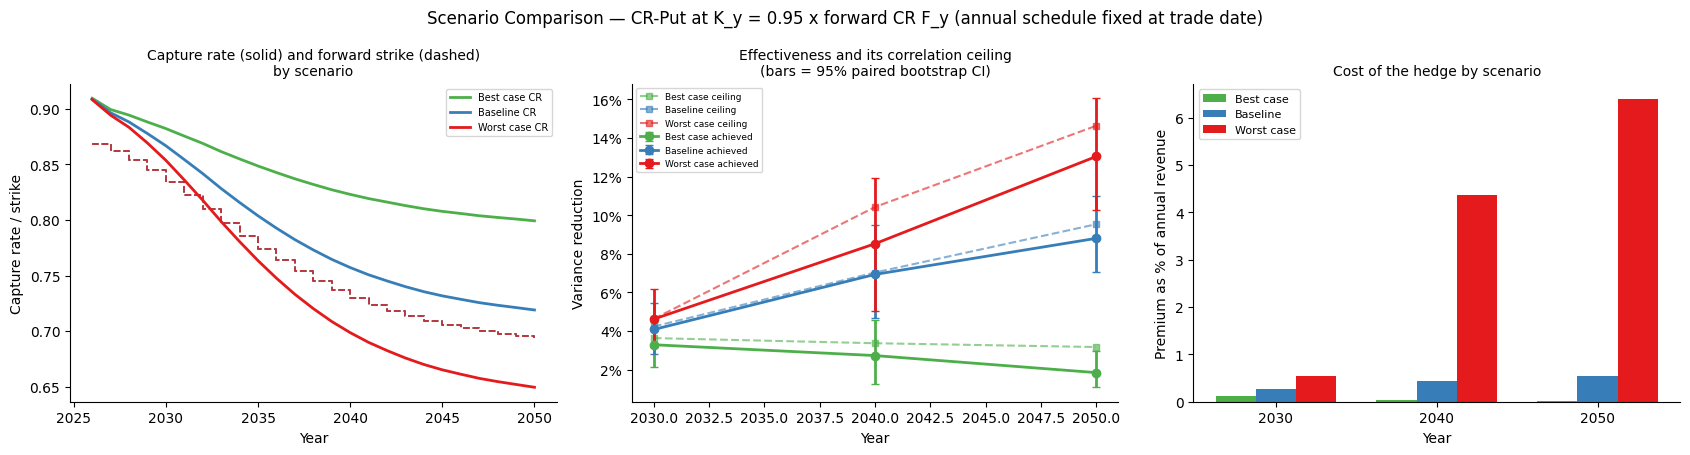


Part II below reverts to the baseline scenario (pniec, baseline) only.


In [24]:
# ── Step 10 — run the pipeline under each scenario ───────────────────────────
import contextlib
import io


def run_scenario(pen, temp, n_boot=N_BOOT_TS):
    """Full Part I hedge pipeline for one scenario. Returns per-year metrics.

    Reuses the same step functions as the baseline spine, so the scenarios cannot
    drift from it methodologically. Step prints are suppressed — only the
    comparison below is reported.
    """
    with contextlib.redirect_stdout(io.StringIO()):
        # need_sim=False: the scenario spine needs only the MONTHLY index, and
        # a second daily table does not fit alongside the baseline results.
        _, ri_s, _cr_h_s, cr_h_m_s, _ri_h_s, _mp_s = load_data(
            pen, temp, need_sim=False)
        cr_monthly_s = monthly_cr_streamed(pen)
        gc.collect()
        fwd_s = default_forward_strike(cr_monthly_s, cr_h_m_s)
        hist_s = default_historical_strike(cr_h_m_s)
        prem_roll_s, prem_mc_s, prem_oos_s, _ = step1_premiums(
            cr_h_m_s, cr_monthly_s, fwd_strike=fwd_s, hist_strike=hist_s)
        ri_sim_s = step5_apply_hedge(cr_monthly_s, ri_s, prem_mc_s, n_mwh_by_month,
                                     strike=fwd_s, premium_mc_oos=prem_oos_s)

    rows = []
    for y in TARGET_YEARS:
        s = ri_sim_s[ri_sim_s["year"] == y]
        rev = s["rev_unhedged_eur"].to_numpy()
        hed = s["rev_hedged_eur"].to_numpy()
        pay = (s["annual_payoff_eur"] / 1e6).to_numpy()
        prem = float(s["annual_payoff_eur"].mean())
        mv = rm.min_variance_hedge(rev, pay)
        vci = rm.variance_reduction_ci(rev, hed, B=n_boot, seed=BOOT_SEED)
        dci = rm.paired_delta_ci(rev, hed, B=n_boot, seed=BOOT_SEED)
        gap = rm.shortfall_gap(rev)
        rows.append({
            "scenario": None, "year": y,
            "K": float(fwd_s.loc[fwd_s["year"] == y, "K"].mean())
                 if isinstance(fwd_s, pd.DataFrame) else float(K_CR),
            "CR_mean": float(cr_monthly_s.loc[cr_monthly_s["year"] == y, "CR_monthly"].mean()),
            "rev_mean": float(rev.mean()),
            "premium_EUR": prem,
            "prem_pct_rev": prem / 1e6 / rev.mean() * 100,
            "P_exercise": float((s["annual_payoff_eur"] > 0).mean()),
            "var_red": vci["var_red"], "vr_lo": vci["lo"], "vr_hi": vci["hi"],
            "ceiling": mv["max_var_red"], "rho": mv["rho"], "h_star": mv["h_star"],
            "dCVaR_pct_gap": dci["dCVaR"] / gap * 100 if gap else np.nan,
        })
    out = pd.DataFrame(rows)
    strike_path = (fwd_s.groupby("year")["K"].mean()
                   if isinstance(fwd_s, pd.DataFrame) else None)
    cr_path = cr_monthly_s.groupby("year")["CR_monthly"].mean()
    return out, strike_path, cr_path


scen_rows, scen_strike, scen_cr = [], {}, {}
for _label, (_pen, _temp) in SCENARIOS.items():
    _df, _sp, _cp = run_scenario(_pen, _temp)
    _df["scenario"] = _label
    scen_rows.append(_df)
    scen_strike[_label], scen_cr[_label] = _sp, _cp
    print(f"  ran {_label:<11} ({_pen}, {_temp})")

scenario_df = pd.concat(scen_rows, ignore_index=True)

# ── Comparison tables ────────────────────────────────────────────────────────
_order = list(SCENARIOS)
for y in TARGET_YEARS:
    print(f"\n── Scenario comparison — {y} ────────────────────────────────────────")
    print(f"{'scenario':>11}  {'mean CR':>8}  {'K':>7}  {'revenue':>9}  {'premium':>12}  "
          f"{'% rev':>7}  {'P(pay)':>7}  {'var_red':>18}  {'ceiling':>8}  {'h*':>6}")
    print(f"{'-'*11}  {'-'*8}  {'-'*7}  {'-'*9}  {'-'*12}  {'-'*7}  {'-'*7}  "
          f"{'-'*18}  {'-'*8}  {'-'*6}")
    for lab in _order:
        r = scenario_df[(scenario_df["scenario"] == lab) & (scenario_df["year"] == y)].iloc[0]
        vr = f"{r['var_red']:>6.1%} [{r['vr_lo']:+.1%},{r['vr_hi']:+.1%}]"
        print(f"{lab:>11}  {r['CR_mean']:>8.4f}  {r['K']:>7.4f}  {r['rev_mean']:>8.2f}M  "
              f"{r['premium_EUR']:>12,.0f}  {r['prem_pct_rev']:>6.2f}%  {r['P_exercise']:>6.1%}  "
              f"{vr:>18}  {r['ceiling']:>7.1%}  {r['h_star']:>6.2f}")

# ── Ordering sanity check ────────────────────────────────────────────────────
# Deeper penetration => bigger payoff and stronger revenue-payoff correlation, so
# worst > baseline > best is expected on premium and on the ceiling. Flag, don't fail:
# in early years the contract is near-inert everywhere and the ordering can be noise.
print("\n── Expected ordering (worst > baseline > best) ──────────────────────")
for metric in ["premium_EUR", "ceiling", "var_red"]:
    for y in TARGET_YEARS:
        vals = {lab: float(scenario_df[(scenario_df["scenario"] == lab)
                                       & (scenario_df["year"] == y)][metric].iloc[0])
                for lab in _order}
        ok = vals["Worst case"] >= vals["Baseline"] >= vals["Best case"]
        print(f"  {metric:<12} {y}  best={vals['Best case']:>12,.4g}  "
              f"base={vals['Baseline']:>12,.4g}  worst={vals['Worst case']:>12,.4g}   "
              + ("ok" if ok else "<- ORDERING INVERTED"))

# ── Figures ──────────────────────────────────────────────────────────────────
_c_scen = {"Best case": "#4daf4a", "Baseline": "#377eb8", "Worst case": "#e41a1c"}

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

ax = axes[0]
for lab in _order:
    ax.plot(scen_cr[lab].index, scen_cr[lab].values, color=_c_scen[lab], lw=2, label=f"{lab} CR")
    if scen_strike[lab] is not None:
        ax.step(scen_strike[lab].index, scen_strike[lab].values, where="post",
                color=_c_scen[lab], lw=1.3, ls="--", alpha=0.8)
ax.set_xlabel("Year"); ax.set_ylabel("Capture rate / strike")
ax.set_title(f"Capture rate (solid) and {STRIKE_RULE} strike (dashed)\nby scenario", fontsize=10)
ax.legend(fontsize=7)

ax = axes[1]
for lab in _order:
    s = scenario_df[scenario_df["scenario"] == lab].sort_values("year")
    ax.errorbar(s["year"], s["var_red"],
                yerr=np.vstack([s["var_red"] - s["vr_lo"], s["vr_hi"] - s["var_red"]]),
                marker="o", lw=2, capsize=3, color=_c_scen[lab], label=f"{lab} achieved")
    ax.plot(s["year"], s["ceiling"], marker="s", ms=4, ls="--", alpha=0.6,
            color=_c_scen[lab], label=f"{lab} ceiling")
ax.set_xlabel("Year"); ax.set_ylabel("Variance reduction")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title("Effectiveness and its correlation ceiling\n(bars = 95% paired bootstrap CI)",
             fontsize=10)
ax.legend(fontsize=6.5)

ax = axes[2]
_w = 0.25
_x = np.arange(len(TARGET_YEARS))
for i, lab in enumerate(_order):
    s = scenario_df[scenario_df["scenario"] == lab].sort_values("year")
    ax.bar(_x + (i - 1) * _w, s["prem_pct_rev"], _w, color=_c_scen[lab], label=lab)
ax.set_xticks(_x); ax.set_xticklabels(TARGET_YEARS)
ax.set_xlabel("Year"); ax.set_ylabel("Premium as % of annual revenue")
ax.set_title("Cost of the hedge by scenario", fontsize=10)
ax.legend(fontsize=8)

fig.suptitle(f"Scenario Comparison — CR-Put at {strike_description()}")
sns.despine(); plt.tight_layout(); plt.show()

print(f"\nPart II below reverts to the baseline scenario "
      f"({BASE_PEN}, {BASE_TEMP}) only.")


> **Takeaway.** The best, baseline and worst scenarios produce materially different premiums and risk reductions under the same contract design, confirming the hedge's economics are sensitive to which penetration and temperature path materialises.

---
## Part II — Lee & Oren Equilibrium Pricing

Replaces the flat actuarial premium with a market-clearing equilibrium price **W0**
derived from three agents: the SPP (buyer), an ESO storage operator (natural seller),
and the issuer / trading desk (residual seller).

| Block | Computes |
|---|---|
| B1 | Annual time series: Γ_I (payoff), I_spp (revenue), I_eso (storage income) |
| B2 | Cross-sectional moments per year: means, variances, covariances |
| B3 | Equilibrium price W0 and agent quantities α |
| B4 | Sensitivity analysis and six diagnostic plots |

In [25]:
# -- Checkpoint: Part I -> Part II handoff -----------------------------------
# Part II below needs cr_monthly, ri_sim, premium_mc, fwd_strike, n_mwh_by_month,
# cr_h_m, and the monthly RI series _rim (Block 3c). None of these touch the
# full 45M-row `sim` table except _rim's construction. Checkpointing them here
# lets Part II be iterated (new equilibrium grids, new plots) in a fresh,
# ~200 MB kernel without ever re-running Part I.
import pickle as _pkl

CKPT = BASE / "Data/Results/_hedge_checkpoint.pkl"
def _input_fingerprint():
    """(name, mtime, size) for every file Part I reads.

    Validating on config VALUES alone would miss a repointed input file (for
    instance, the price source moving from a raw CSV to a cleaned parquet):
    the checkpoint would look valid while Part II ran on state built from a
    different file.
    """
    out = {}
    for _nm, _p in [("SIM_FILE", SIM_FILE), ("RI_FILE", RI_FILE),
                    ("CR_HIST", CR_HIST), ("SOLAR_HIST", SOLAR_HIST),
                    ("TEMP_HIST", TEMP_HIST), ("NOCT_FILE", NOCT_FILE),
                    ("RI_HIST", RI_HIST), ("GME_FILE", GME_FILE)]:
        _st = Path(_p).stat()
        out[_nm] = (Path(_p).name, int(_st.st_mtime), int(_st.st_size))
    return out


_ckpt_config = dict(PLANT_MW=PLANT_MW, LOT_MW=LOT_MW,
                   BATTERY_SOLAR_RATIO=BATTERY_SOLAR_RATIO, v_spp=v_spp,
                   STRIKE_RULE=STRIKE_RULE, FWD_MULT=FWD_MULT, N_PATHS=N_PATHS,
                   NOTIONAL_SHAPE=NOTIONAL_SHAPE,
                   inputs=_input_fingerprint())

if "ri_sim" in dir():
    # Part I just ran in this kernel -- (re)build the checkpoint. _rim was built
    # back where `sim` was last needed, so nothing here touches the daily table.
    with open(CKPT, "wb") as _f:
        _pkl.dump(dict(config=_ckpt_config, cr_monthly=cr_monthly, ri_sim=ri_sim,
                      premium_mc=premium_mc, fwd_strike=fwd_strike,
                      n_mwh_by_month=n_mwh_by_month, cr_h_m=cr_h_m, rim=_rim), _f)
    print(f"checkpoint written: {CKPT.name}  (config={_ckpt_config})")
else:
    # Fresh kernel, Part I has not run here -- load from a prior checkpoint.
    assert CKPT.exists(), (
        "no checkpoint on disk and Part I has not run in this kernel -- "
        "run cells 0-41 first, or restore a prior checkpoint")
    with open(CKPT, "rb") as _f:
        _ck = _pkl.load(_f)
    _ckpt_saved_config = _ck["config"]
    assert _ckpt_saved_config == _ckpt_config, (
        f"checkpoint config {_ckpt_saved_config} does not match the live "
        f"config {_ckpt_config} -- Part II would run against a different "
        "parameterisation than it was checkpointed under. Re-run Part I.")
    cr_monthly, ri_sim, premium_mc, fwd_strike, n_mwh_by_month, cr_h_m, _rim = (
        _ck["cr_monthly"], _ck["ri_sim"], _ck["premium_mc"], _ck["fwd_strike"],
        _ck["n_mwh_by_month"], _ck["cr_h_m"], _ck["rim"])
    print(f"loaded checkpoint: {CKPT.name}  (config={_ckpt_saved_config})")

checkpoint written: _hedge_checkpoint.pkl  (config={'PLANT_MW': 20, 'LOT_MW': 1, 'BATTERY_SOLAR_RATIO': 0.2, 'v_spp': 2.0, 'STRIKE_RULE': 'forward', 'FWD_MULT': 0.95, 'N_PATHS': None, 'NOTIONAL_SHAPE': 'seasonal', 'inputs': {'SIM_FILE': ('mc_physical_variables_pniec.parquet', 1789286224, 1110263620), 'RI_FILE': ('ri_annual_results_multiscenario.parquet', 1789286439, 17042691), 'CR_HIST': ('df_cr_modelled.parquet', 1789285466, 1157151), 'SOLAR_HIST': ('df_solar_modelled.parquet', 1789285180, 706101), 'TEMP_HIST': ('df_temperature_modeled.parquet', 1789285302, 531701), 'NOCT_FILE': ('noct_uplift_params.pkl', 1789285354, 4532), 'RI_HIST': ('ri_annual_results_hist.parquet', 1789286363, 6229), 'GME_FILE': ('df_energy_cleaned.parquet', 1789284930, 5311147)}})


### Block 1 — Annual Time Series Construction

Derives three annual series across 1,000 simulations × 25 years from the monthly CR data:

- **Γ_I** (`Gamma_I`): annual EUR payoff of the CR-put contract — `sum_m max(0,K−CR) × w_CR(m)`
- **I_spp**: annual SPP monetary revenue — `sum_m CR_monthly × w_CR(m)` (actual capture revenue)
- **I_eso**: annual ESO storage income from intraday arbitrage — `ESO_MWh × max(0, P_fixed × (1 − CR/η))`

`w_CR(m) = N_MWh(m) × P_FIXED_EUR` is the monetary exposure per unit CR in month m.

In [26]:
def block1_annual_series(cr_monthly, n_mwh_by_month, ri_sim=None, strike=None,
                          p_fixed=P_FIXED_EUR,
                          eta=eta_rt, eso_mwh=ESO_MWh_month):
    # Same strike schedule Part I uses, so Gamma_I cannot describe a different
    # contract from the one whose effectiveness Part I measured.
    strike = fwd_strike if strike is None else strike
    # w_CR(month) = N_MWh(month) × P_FIXED_EUR — monetary exposure per unit CR
    w_cr = n_mwh_by_month.assign(w_CR=n_mwh_by_month["N_MWh"] * p_fixed)[["month", "w_CR"]]
    ts   = cr_monthly.merge(w_cr, on="month")

    # Gamma_I: monthly EUR payoff of the CR-put, summed annually
    _kv, ts = strike_vector(ts, strike)
    ts["payoff_m_eur"] = np.clip(_kv - ts["CR_monthly"].to_numpy(), 0, None) * ts["w_CR"]

    # I_spp (index proxy): CR × w_CR, where w_CR is built from a FIXED P50 volume
    # and a fixed price. Retained only as a fallback — see the override below.
    ts["I_spp_m"] = ts["CR_monthly"] * ts["w_CR"]

    # I_eso: monthly ESO arbitrage income
    # P_buy = P_fixed × CR  (solar glut price);  P_sell = P_fixed  (off-peak recovery)
    # spread = max(0, P_fixed − P_buy / eta_rt)  =  max(0, P_fixed × (1 − CR/eta))
    ts["spread_m"] = (p_fixed * (1 - ts["CR_monthly"] / eta)).clip(lower=0)
    ts["I_eso_m"]  = eso_mwh * ts["spread_m"]

    ann = (ts.groupby(["sim_id", "year"])
             .agg(Gamma_I=("payoff_m_eur", "sum"),
                  I_spp  =("I_spp_m",      "sum"),
                  I_eso  =("I_eso_m",      "sum"))
             .reset_index())

    # convert EUR → M€ so risk aversion coefficients are in M€⁻¹ units
    ann[["Gamma_I", "I_spp", "I_eso"]] /= 1e6

    # ── I_spp override: use the ACTUAL simulated revenue ──────────────────────
    # The proxy above holds production at the P50 seasonal volume, so I_spp and
    # Gamma_I become deterministic functions of the single variable CR. That
    # drives corr(I_spp, Gamma) towards -1 in the late years and implies a nearly
    # perfect hedge — contradicting Part I, which measures ~10% variance reduction
    # for the same contract in the same year. Substituting the simulated revenue
    # restores stochastic production volume and makes the two halves comparable.
    #
    # Price remains deterministic at P_REF: the project simulates no stochastic
    # price path, so price risk is still absent here. That is a stated limitation,
    # not an oversight — volume risk is the part that can be fixed with what is
    # actually modelled.
    if ri_sim is not None:
        _rev = (ri_sim[["sim_id", "year", "rev_unhedged_eur"]]
                .rename(columns={"rev_unhedged_eur": "I_spp_true"}))
        _n_before = len(ann)
        ann = ann.merge(_rev, on=["sim_id", "year"], how="inner")
        assert len(ann) == _n_before, (
            f"I_spp merge changed row count: {_n_before} -> {len(ann)}")
        ann["I_spp_proxy"] = ann["I_spp"]
        ann["I_spp"]       = ann["I_spp_true"]
        ann = ann.drop(columns=["I_spp_true"])

    return ann


ann = block1_annual_series(cr_monthly, n_mwh_by_month, ri_sim=ri_sim, strike=fwd_strike)
print(f"ann shape : {ann.shape}  (units: M€)")
print(ann.describe().T[["mean", "std", "min", "max"]].round(4))
if "I_spp_proxy" in ann:
    print(f"\nI_spp source: simulated revenue (stochastic volume)."
          f"  mean {ann['I_spp'].mean():.3f} M€ vs frozen-volume proxy "
          f"{ann['I_spp_proxy'].mean():.3f} M€")
    print(f"  std  {ann['I_spp'].std():.4f} M€ vs proxy {ann['I_spp_proxy'].std():.4f} M€"
          f"   (the proxy understates SPP revenue variability)")

ann shape : (125000, 6)  (units: M€)
                  mean        std        min        max
sim_id       2499.5000  1443.3814     0.0000  4999.0000
year         2038.0000     7.2111  2026.0000  2050.0000
Gamma_I         0.0004     0.0007     0.0000     0.0386
I_spp           1.9864     0.1703     1.3159     2.5375
I_eso           0.0670     0.0406     0.0000     0.2171
I_spp_proxy     0.1056     0.0083     0.0692     0.1353

I_spp source: simulated revenue (stochastic volume).  mean 1.986 M€ vs frozen-volume proxy 0.106 M€
  std  0.1703 M€ vs proxy 0.0083 M€   (the proxy understates SPP revenue variability)


In [27]:
# Block 1 INTERNAL CONSISTENCY CHECK (not a validation).
# Gamma_I and annual_payoff_eur are computed from the same formula on the same
# data, so agreement to ~1e-16 confirms no transcription error and nothing more.
# It cannot detect a modelling error, and should not be read as one.
check = ann.merge(ri_sim[["sim_id", "year", "annual_payoff_eur"]], on=["sim_id", "year"])
# Gamma_I is the PER-LOT payoff (block1_annual_series does not multiply by
# N_CONTRACTS_CAP); annual_payoff_eur is Part I's FULL N_CONTRACTS_CAP-lot
# position (step5_apply_hedge does). Divide it back to a per-lot basis before
# comparing -- without this, the check compares different notional sizes and
# fails by exactly a factor of N_CONTRACTS_CAP.
diff  = (check["Gamma_I"] - check["annual_payoff_eur"] / N_CONTRACTS_CAP / 1e6).abs().max()
print(f"Max deviation Gamma_I vs annual_payoff_eur/1e6 : {diff:.2e} M€  (must be < 1e-6)")
assert diff < 1e-6, f"Gamma_I mismatch: {diff:.2e} M€"

w_CR_annual_MEur = n_mwh_by_month["N_MWh"].sum() * P_FIXED_EUR / 1e6
print(f"w_CR_annual : {w_CR_annual_MEur:.3f} M€ per lot  "
      f"({n_mwh_by_month['N_MWh'].sum():.1f} MWh x {P_FIXED_EUR} EUR/MWh)")
print("Block 1 internal consistency OK (transcription check only)")

Max deviation Gamma_I vs annual_payoff_eur/1e6 : 3.47e-18 M€  (must be < 1e-6)
w_CR_annual : 0.132 M€ per lot  (1202.8 MWh x 110.0 EUR/MWh)
Block 1 internal consistency OK (transcription check only)


### Block 2 — Cross-Sectional Moments per Year

For each of the 25 years, compute across the 1,000 simulation paths:
means, variances, and covariances between the three series.

**Expected signs:**
- `cov(I_spp, Γ_I) < 0` — when CR is low, SPP revenue is low *and* put payoff is high
- `cov(I_eso, Γ_I) > 0` — when CR is low, ESO arbitrage spread is wide *and* put payoff is high

These signs determine the direction of the equilibrium risk premium in Block 3.

In [28]:
def block2_moments(ann, premium_mc, n_mwh_by_month, p_fixed=P_FIXED_EUR):
    # annual actuarial premium in M€: sum_m premium_mc(y,m) × w_CR(m) / 1e6
    w_cr = n_mwh_by_month.assign(w_CR=n_mwh_by_month["N_MWh"] * p_fixed)
    pmc_annual = (premium_mc
                  .merge(w_cr[["month", "w_CR"]], on="month")
                  .assign(prem_eur_m=lambda d: d["premium_mc"] * d["w_CR"])
                  .groupby("year")["prem_eur_m"].sum()
                  .reset_index()
                  .rename(columns={"prem_eur_m": "premium_mc_annual"}))
    pmc_annual["premium_mc_annual"] /= 1e6   # EUR → M€

    rows = []
    for y, grp in ann.groupby("year"):
        g   = grp["Gamma_I"].values   # M€
        spp = grp["I_spp"].values     # M€
        eso = grp["I_eso"].values     # M€

        # np.cov returns a 2×2 matrix; off-diagonal = covariance in M€²
        cov_spp = np.cov(spp, g, ddof=1)[0, 1]
        cov_eso = np.cov(eso, g, ddof=1)[0, 1]

        rows.append({
            "year"        : y,
            "mu_W1"       : g.mean(),        # M€
            "sigma2_W1"   : g.var(ddof=1),   # M€²
            "mu_I_spp"    : spp.mean(),       # M€
            "sigma2_I_spp": spp.var(ddof=1),  # M€²
            "mu_I_eso"    : eso.mean(),        # M€
            "sigma2_I_eso": eso.var(ddof=1),   # M€²
            "cov_spp_W1"  : cov_spp,           # M€²
            "cov_eso_W1"  : cov_eso,           # M€²
        })

    mom = pd.DataFrame(rows)
    mom["corr_spp_W1"] = mom["cov_spp_W1"] / np.sqrt(mom["sigma2_I_spp"] * mom["sigma2_W1"])
    mom["corr_eso_W1"] = mom["cov_eso_W1"] / np.sqrt(mom["sigma2_I_eso"] * mom["sigma2_W1"])
    mom = mom.merge(pmc_annual, on="year")
    return mom


mom = block2_moments(ann, premium_mc, n_mwh_by_month)
print(mom[["year", "mu_W1", "premium_mc_annual", "cov_spp_W1", "cov_eso_W1",
           "corr_spp_W1", "corr_eso_W1"]]
      .to_string(index=False, float_format="{:.4f}".format))

# ── Reconciliation with Part I ────────────────────────────────────────────────
# corr_spp_W1 here and the rho reported by the Part I hedge-ratio ceiling are the
# same quantity — corr(SPP revenue, CR-put payoff) — so they must agree. They did
# not before I_spp was corrected: the frozen-volume proxy pushed this towards -1.
print("\n── corr(I_spp, Gamma_I): Part II vs Part I ──────────────────────────")
print(f"{'year':>6}  {'Part II corr_spp_W1':>20}  {'Part I rho':>12}  {'|diff|':>8}")
for _y in TARGET_YEARS:
    _p2 = float(mom.loc[mom['year'] == _y, 'corr_spp_W1'].iloc[0])
    _s  = ri_sim[ri_sim['year'] == _y]
    _p1 = rm.min_variance_hedge(_s['rev_unhedged_eur'].to_numpy(),
                                (_s['annual_payoff_eur'] / 1e6).to_numpy())['rho']
    print(f"{_y:>6}  {_p2:>20.4f}  {_p1:>12.4f}  {abs(_p2 - _p1):>8.4f}")
_mx = max(abs(float(mom.loc[mom['year'] == _y, 'corr_spp_W1'].iloc[0])
              - rm.min_variance_hedge(
                  ri_sim.loc[ri_sim['year'] == _y, 'rev_unhedged_eur'].to_numpy(),
                  (ri_sim.loc[ri_sim['year'] == _y, 'annual_payoff_eur'] / 1e6).to_numpy())['rho'])
          for _y in TARGET_YEARS)
assert _mx < 1e-6, f"Part I and Part II disagree on corr(revenue, payoff): {_mx:.2e}"
print(f"\n  max |difference| = {_mx:.2e}  ✓ the two halves now describe one contract")

 year  mu_W1  premium_mc_annual  cov_spp_W1  cov_eso_W1  corr_spp_W1  corr_eso_W1
 2026 0.0002             0.0002     -0.0000      0.0000      -0.1831       0.9154
 2027 0.0003             0.0003     -0.0000      0.0000      -0.2341       0.9205
 2028 0.0003             0.0003     -0.0000      0.0000      -0.2032       0.8749
 2029 0.0003             0.0003     -0.0000      0.0000      -0.1914       0.8405
 2030 0.0003             0.0003     -0.0000      0.0000      -0.2058       0.7867
 2031 0.0003             0.0003     -0.0000      0.0000      -0.2323       0.7709
 2032 0.0003             0.0003     -0.0000      0.0000      -0.2026       0.7624
 2033 0.0003             0.0003     -0.0000      0.0000      -0.2675       0.7315
 2034 0.0004             0.0004     -0.0000      0.0000      -0.2310       0.7383
 2035 0.0004             0.0004     -0.0000      0.0000      -0.2321       0.7282
 2036 0.0004             0.0004     -0.0000      0.0000      -0.2735       0.7404
 2037 0.0004    

In [29]:
# Block 2 sanity checks (all quantities in M€ / M€²)
# cov_spp_W1 is checked via CORRELATION, not raw covariance, and against a small
# positive tolerance rather than strictly < 0: in early, low-penetration years
# the true covariance is close to zero, and Monte Carlo sampling noise can push
# the estimate marginally positive without indicating a real sign flip.
#
# corr_spp_W1 (already computed, dimensionless in [-1, 1]) is used instead of a
# tolerance on cov_spp_W1 directly, because cov_spp_W1 scales with PLANT_MW -- a
# literal absolute tolerance (e.g. a fixed 1e-4) silently re-breaks every time
# the plant is resized, since cov_spp_W1's scale moves with PLANT_MW, and
# a tolerance relative to cov_spp_W1's OWN observed max is circular: at low path
# counts that max is itself noisy and can be smaller than the noise floor it is
# meant to bound (confirmed: it fired at N_PATHS=200). Correlation carries none
# of that scale dependence.
# The tolerance itself must scale with the sampling noise, which scales with
# 1/sqrt(n_paths) -- a fixed constant calibrated at one path count (whether
# N_PATHS=None or a rehearsal subsample) is miscalibrated at any other. 4
# standard errors of a correlation estimate's approximate sampling SE
# (1/sqrt(n)) is generous enough to avoid false positives while still catching
# a genuine sign flip, which would be an order of magnitude larger than this.
_n_paths_used = ann["sim_id"].nunique()
CORR_SPP_TOL = max(0.02, 4 / np.sqrt(_n_paths_used))
print(f"  corr_spp_W1 range : [{mom['corr_spp_W1'].min():+.4f}, {mom['corr_spp_W1'].max():+.4f}]"
      f"  |  tolerance {CORR_SPP_TOL:.3f}  ({_n_paths_used:,} paths)")
assert (mom["corr_spp_W1"] < CORR_SPP_TOL).all(), (
    f"corr(I_spp, Γ_I) must be negative (within tolerance {CORR_SPP_TOL:.2f}) for all years"
)
assert (mom["cov_eso_W1"] > 0).all(), "cov(I_eso, Γ_I) must be positive for all years"
diff_pmc = (mom["mu_W1"] - mom["premium_mc_annual"]).abs().max()
assert diff_pmc < 1e-6, f"mu_W1 vs premium_mc_annual max Δ = {diff_pmc:.2e} M€"

print("Block 2 sanity checks passed ✓")
print(f"  max |cov_spp_W1| : {mom['cov_spp_W1'].abs().max():>10.4f} M€²")
print(f"  max  cov_eso_W1  : {mom['cov_eso_W1'].max():>10.4f} M€²")
print(f"  corr_spp range   : [{mom['corr_spp_W1'].min():.3f}, {mom['corr_spp_W1'].max():.3f}]")
print(f"  corr_eso range   : [{mom['corr_eso_W1'].min():.3f}, {mom['corr_eso_W1'].max():.3f}]")
print(f"  mu_W1 vs pmc_annual max Δ : {diff_pmc:.2e} M€")

  corr_spp_W1 range : [-0.3088, -0.1831]  |  tolerance 0.057  (5,000 paths)
Block 2 sanity checks passed ✓
  max |cov_spp_W1| :     0.0000 M€²
  max  cov_eso_W1  :     0.0000 M€²
  corr_spp range   : [-0.309, -0.183]
  corr_eso range   : [0.698, 0.920]
  mu_W1 vs pmc_annual max Δ : 1.08e-19 M€


### Block 3 — Equilibrium Price (Lee & Oren, 2009)

All quantities are in M€ / M€² following the Block 1 rescaling.

Market-clearing condition (`α_spp + α_eso = α_m`) yields the closed-form equilibrium price:

$$W_0 = \frac{\mu_{W_1}}{B_1} - \frac{\text{cov}_{spp} + \text{cov}_{eso}}{H \cdot B_1}$$

**Derivation**: setting demand equal to supply in the alpha equations gives
$(μ_{W_1} - B_1 W_0) \cdot H = \text{cov}_{spp} + \text{cov}_{eso}$, which solves to the formula above.

**Interpretation of the loading term:**
- `cov_spp < 0` → net covariance sum is negative → W0 > fair value → SPP pays above actuarial
- `cov_eso > 0` → ESO natural-hedge income partially offsets the SPP demand pressure
- Net sign and magnitude determine whether the equilibrium loading is positive or negative

Agent quantities `α` represent optimal contract holdings at equilibrium.
`α_spp > 0` (long), `α_eso < 0` (short — natural seller), `α_m > 0` (desk residual supply).

> **Note on terminology:** `HE_spp` (computed below) is a *monetary* certainty-equivalent gain in EUR, `CE(hedged) - CE(unhedged)` with `CE = mu - (risk_aversion/2) * sigma2`. It is unrelated to `var_red` (the dimensionless variance-reduction ratio from Step 6/Step 8) even though both are informally called "hedge effectiveness".

> **Note on negative loading:** the closed-form `W0` above can yield `loading_pct < 0` (SPP pays *below* the actuarially fair premium) at high ESO storage volumes — see Block 4. `block3_equilibrium` warns when this occurs rather than clipping the value, since it is a real finding of the equilibrium model, not an error.


In [30]:
def block3_equilibrium(mom, v_s=v_spp, v_e=v_eso, v_mkt=v_m, b1=B1, h=None):
    # h is the aggregate inverse risk aversion and MUST agree with v_s/v_e/v_mkt.
    # Defaulting it to the module-level H while a caller sweeps v_s silently makes
    # W0 invariant to that sweep (W0 depends on v_s only through h).
    if h is None:
        h = 1 / v_s + 1 / v_e + 1 / v_mkt
    assert np.isclose(h, 1 / v_s + 1 / v_e + 1 / v_mkt), (
        f"h={h:.6f} is inconsistent with v_s={v_s}, v_e={v_e}, v_mkt={v_mkt} "
        f"(expected {1/v_s + 1/v_e + 1/v_mkt:.6f})"
    )
    m = mom.copy()

    # equilibrium annual premium — derived from market-clearing α_spp + α_eso = α_m
    # solving (μ_W1 - B1·W0)·H = cov_spp + cov_eso  →  W0 = μ_W1/B1 - (cov_spp+cov_eso)/(H·B1)
    m["W0"] = (m["mu_W1"] / b1
               - (m["cov_spp_W1"] + m["cov_eso_W1"]) / (h * b1))

    m["risk_premium_EUR"] = m["W0"] - m["mu_W1"] / b1
    m["loading_pct"]      = m["risk_premium_EUR"] / m["mu_W1"] * 100

    # optimal contract quantities per agent (mean-variance demand functions)
    m["alpha_spp"] = ((m["mu_W1"] - b1 * m["W0"] - v_s   * m["cov_spp_W1"])
                      / (v_s   * m["sigma2_W1"]))
    m["alpha_eso"] = ((m["mu_W1"] - b1 * m["W0"] - v_e   * m["cov_eso_W1"])
                      / (v_e   * m["sigma2_W1"]))
    m["alpha_m"]   = ((b1 * m["W0"] - m["mu_W1"])
                      / (v_mkt * m["sigma2_W1"]))

    # Certainty-equivalent hedging gain for SPP (Lee & Oren Eq. 37).
    # HE_spp is a MONETARY certainty-equivalent gain (EUR) — distinct
    # from the dimensionless "var_red" variance-reduction ratio computed
    # in Step 6/Step 8 above (see markdown note before this block).
    m["CE_unh_spp"]  = rm.certainty_equivalent(m["mu_I_spp"], m["sigma2_I_spp"], v_s)
    m["Var_hed_spp"] = (m["sigma2_I_spp"]
                        + m["alpha_spp"] ** 2 * m["sigma2_W1"]
                        + 2 * m["alpha_spp"] * m["cov_spp_W1"])
    m["mu_hed_spp"]  = m["mu_I_spp"] + m["alpha_spp"] * (m["mu_W1"] - b1 * m["W0"])
    m["CE_hed_spp"]  = rm.certainty_equivalent(m["mu_hed_spp"], m["Var_hed_spp"], v_s)
    m["HE_spp"] = m["CE_hed_spp"] - m["CE_unh_spp"]

    n_negative = int((m["loading_pct"] < 0).sum())
    if n_negative:
        warnings.warn(
            f"{n_negative}/{len(m)} years have loading_pct < 0 "
            f"(economically implausible negative risk premium; "
            f"min={m['loading_pct'].min():.2f}%). Two distinct causes: at BASELINE "
            "this is Monte Carlo noise flipping cov_spp_W1 marginally positive in "
            "early low-penetration years (see the tolerance note in the Block 2 "
            "sanity checks); in the Block 4 sweeps it is genuine — high ESO storage "
            "volumes raise cov_eso_W1 until it outweighs SPP hedging demand."
        )
    return m


eq = block3_equilibrium(mom)


def equilibrium_extra_charge_meur(eq, year, b1=B1):
    """Incremental cost, in M€, of paying the equilibrium price W0 instead of the
    fair premium premium_mc — expressed on the SAME basis premium_mc is charged on.

    premium_mc is an undiscounted expected payoff settled at year end; W0 is a t=0
    price. The like-for-like increment is therefore W0*B1 - premium_mc, which is a
    small POSITIVE number (the risk premium carried forward). Comparing W0 against
    premium_mc directly mixes the two bases and returns a large negative number.
    """
    row = one_row(eq, year=year)
    return float(row["W0"] * b1 - row["premium_mc_annual"])

# display in EUR — internal eq DataFrame stays in M€
_eur_cols = ["mu_W1", "W0", "risk_premium_EUR", "HE_spp"]
disp = eq[["year", "mu_W1", "W0", "risk_premium_EUR", "loading_pct",
           "alpha_spp", "alpha_eso", "alpha_m", "HE_spp"]].copy()
disp[_eur_cols] *= 1e6
print("(monetary columns in EUR, alphas dimensionless, loading_pct in %)")
print(disp.to_string(index=False, float_format="{:,.1f}".format))

(monetary columns in EUR, alphas dimensionless, loading_pct in %)
 year  mu_W1    W0  risk_premium_EUR  loading_pct  alpha_spp  alpha_eso  alpha_m  HE_spp
 2026  176.8 175.7               4.2          2.4       18.4      -12.1      6.3   115.3
 2027  287.9 286.5               7.2          2.5       17.4      -11.9      5.6   200.8
 2028  284.5 281.1               5.0          1.8       18.1      -12.6      5.5   153.1
 2029  298.7 293.6               3.7          1.2       19.9      -14.2      5.7   133.7
 2030  300.2 295.9               4.6          1.5       19.2      -13.7      5.5   157.3
 2031  318.6 314.9               5.7          1.8       19.5      -13.8      5.7   196.5
 2032  305.0 299.7               3.7          1.2       19.0      -14.3      4.8   144.3
 2033  334.3 330.7               6.3          1.9       21.7      -15.2      6.5   233.8
 2034  351.5 345.6               4.5          1.3       20.4      -15.1      5.3   181.1
 2035  366.0 359.4               4.3        

In [31]:
# Block 3 check — market clearing.
#
# Substituting the closed-form W0 back into the alpha equations is a TAUTOLOGY: W0
# was derived by solving alpha_spp + alpha_eso = alpha_m, so the residual is zero by
# construction and only confirms the algebra was transcribed correctly.
#
# The genuinely independent test is to discard the closed form and solve the
# market-clearing condition NUMERICALLY, then check the two agree.
from scipy.optimize import brentq


def _excess_demand(w0, row, v_s=v_spp, v_e=v_eso, v_mkt=v_m, b1=B1):
    """alpha_spp + alpha_eso - alpha_m at price w0 (zero at equilibrium)."""
    a_spp = (row["mu_W1"] - b1 * w0 - v_s * row["cov_spp_W1"]) / (v_s * row["sigma2_W1"])
    a_eso = (row["mu_W1"] - b1 * w0 - v_e * row["cov_eso_W1"]) / (v_e * row["sigma2_W1"])
    a_m = (b1 * w0 - row["mu_W1"]) / (v_mkt * row["sigma2_W1"])
    return a_spp + a_eso - a_m


mc_err = (eq["alpha_spp"] + eq["alpha_eso"] - eq["alpha_m"]).abs()
assert mc_err.max() < 1e-9, f"closed-form substitution residual {mc_err.max():.2e}"

_num_err = []
for _, _row in eq.iterrows():
    _lo, _hi = _row["mu_W1"] / B1 - 10.0, _row["mu_W1"] / B1 + 10.0
    _w0_num = brentq(_excess_demand, _lo, _hi, args=(_row,), xtol=1e-14)
    _num_err.append(abs(_w0_num - _row["W0"]))
_num_err = np.array(_num_err)

print(f"Closed-form substitution residual (tautological) : {mc_err.max():.2e}")
print(f"Numerical vs closed-form W0 (independent)        : {_num_err.max():.2e}")
assert _num_err.max() < 1e-9, "closed form disagrees with the numerical solution"
print("Market clearing verified independently ✓")

print(f"\nBaseline loading range : {eq['loading_pct'].min():.2f}% – {eq['loading_pct'].max():.2f}%")
print(f"HE_spp range (EUR)     : {eq['HE_spp'].min()*1e6:,.0f} – {eq['HE_spp'].max()*1e6:,.0f} EUR/year")

# Sign expectations stated in the Block 3 markdown — check them rather than assume.
_n_neg_a = int((eq["alpha_spp"] < 0).sum())
if _n_neg_a:
    warnings.warn(
        f"{_n_neg_a}/{len(eq)} years have alpha_spp < 0: the designated hedge BUYER "
        "is selling protection on its own revenue. This is a model failure, not a "
        "finding — it tracks the years where cov_spp_W1 flips sign on MC noise."
    )
print(f"alpha_spp range        : {eq['alpha_spp'].min():.3f} – {eq['alpha_spp'].max():.3f}"
      f"   (hedge ratio vs 1.0 = full notional)")


Closed-form substitution residual (tautological) : 2.38e-13
Numerical vs closed-form W0 (independent)        : 2.45e-15
Market clearing verified independently ✓

Baseline loading range : 1.11% – 2.49%
HE_spp range (EUR)     : 115 – 249 EUR/year
alpha_spp range        : 17.449 – 21.764   (hedge ratio vs 1.0 = full notional)


In [32]:
# ── Block 3c — Monthly risk loading on the premium ───────────────────────────
#
# Part II prices the loading ANNUALLY: one W0 per year, from moments measured on
# annual sums. The contract settles MONTHLY, and the hedge is not worth the same
# in every month — July carries ~4x January production, so a July shortfall costs
# the SPP far more. A single annual loading spreads that unevenly across the
# twelve settlements.
#
# This block re-runs the SAME Lee & Oren equilibrium on monthly moments, giving a
# loading per (year, month). Nothing in the model changes; only the resolution at
# which mu_W1, sigma2_W1, cov_spp_W1 and cov_eso_W1 are measured. The financing
# factor is compounded monthly to match.
#
# I_spp is built from REALISED monthly production, not from the w_CR proxy, for
# the same reason Block 1 overrides it annually: freezing volume makes I_spp and
# Gamma deterministic functions of CR alone and drives their correlation to -1.

B1_M = np.exp(r_b / 12)          # monthly carry at the same riskless rate

# ── monthly series: Gamma, I_spp, I_eso (all in M€) ──────────────────────────
_w_cr = n_mwh_by_month.assign(w_CR=lambda d: d["N_MWh"] * P_FIXED_EUR)[["month", "w_CR"]]
_ts = cr_monthly.merge(_w_cr, on="month")
_kv, _ts = strike_vector(_ts, fwd_strike)
_ts["Gamma_m"] = np.clip(_kv - _ts["CR_monthly"].to_numpy(), 0, None) * _ts["w_CR"]

# realised monthly revenue index RI_m = sum_d Q_d * CR_d, then scaled to EUR
#
# _rim is built ONCE, in Part I where the daily `sim` table was last needed,
# and travels into Part II through the checkpoint. The daily table itself is
# released at that point, so there is nothing to recompute from here.
assert "_rim" in dir(), (
    "_rim is missing -- run Part I in this kernel, or load the checkpoint at "
    "the Part I/II boundary, which carries it."
)
_ts = _ts.merge(_rim, on=["sim_id", "year", "month"], how="left")
assert not _ts["RI_m"].isna().any(), "monthly RI missing for some (sim, year, month)"
del _rim

_ts["I_spp_m"] = _ts["RI_m"] * REV_PER_RI
_ts["I_eso_m"] = ESO_MWh_month * (P_FIXED_EUR * (1 - _ts["CR_monthly"] / eta_rt)).clip(lower=0)
for _c in ["Gamma_m", "I_spp_m", "I_eso_m"]:
    _ts[_c] = _ts[_c] / 1e6        # EUR -> M€

# ── monthly moments across paths ─────────────────────────────────────────────
_rows = []
for (_y, _mth), _g in _ts.groupby(["year", "month"]):
    _ga, _sp, _es = _g["Gamma_m"].values, _g["I_spp_m"].values, _g["I_eso_m"].values
    _rows.append({
        "year": _y, "month": _mth,
        "mu_W1": _ga.mean(), "sigma2_W1": _ga.var(ddof=1),
        "mu_I_spp": _sp.mean(), "sigma2_I_spp": _sp.var(ddof=1),
        "mu_I_eso": _es.mean(), "sigma2_I_eso": _es.var(ddof=1),
        "cov_spp_W1": np.cov(_sp, _ga, ddof=1)[0, 1],
        "cov_eso_W1": np.cov(_es, _ga, ddof=1)[0, 1],
    })
mom_m = pd.DataFrame(_rows)

# months with a zero-variance payoff carry no equilibrium — the option is dead
_dead = mom_m["sigma2_W1"] <= 0
if _dead.any():
    print(f"  {_dead.sum()} of {len(mom_m)} months have a degenerate payoff "
          f"(sigma2_W1 = 0); excluded from the monthly equilibrium")
mom_m = mom_m.loc[~_dead].reset_index(drop=True)

# ── same equilibrium, monthly ────────────────────────────────────────────────
eq_m = block3_equilibrium(mom_m, b1=B1_M)
eq_m["premium_fair_eur"]   = eq_m["mu_W1"] / B1_M * 1e6
eq_m["premium_loaded_eur"] = eq_m["W0"] * 1e6

# the loaded premium must reduce to the fair one plus the loading, by definition
assert np.allclose(eq_m["premium_loaded_eur"] - eq_m["premium_fair_eur"],
                   eq_m["risk_premium_EUR"] * 1e6, atol=1e-6)

print()
print(f"-- Monthly equilibrium: {len(eq_m)} (year, month) cells --")
_lo_m, _hi_m = eq_m["loading_pct"].min(), eq_m["loading_pct"].max()
_lo_a, _hi_a = eq["loading_pct"].min(), eq["loading_pct"].max()
print(f"  monthly loading : {_lo_m:.2f}% to {_hi_m:.2f}%")
print(f"  annual  loading : {_lo_a:.2f}% to {_hi_a:.2f}%   (for comparison)")

# ── seasonal profile: is the loading systematically higher in some months? ───
_seas = (eq_m.groupby("month")
              .agg(loading=("loading_pct", "mean"),
                   prem_fair=("premium_fair_eur", "mean"),
                   prem_load=("premium_loaded_eur", "mean"))
              .join(n_mwh_by_month.set_index("month")["N_MWh"]))
_seas["markup_eur"] = _seas["prem_load"] - _seas["prem_fair"]
print()
print("-- Seasonal profile (mean over all years) --")
print(_seas.round(3).to_string())

# ── annual totals: monthly-loaded premium vs the single annual loading ───────
_ann_load = (eq_m.groupby("year")[["premium_fair_eur", "premium_loaded_eur"]].sum())
_ann_load["loading_pct_eff"] = 100 * (_ann_load["premium_loaded_eur"]
                                      / _ann_load["premium_fair_eur"] - 1)
_ann_load = _ann_load.join(eq.set_index("year")["loading_pct"].rename("loading_pct_annual"))
print()
print("-- Annual premium: monthly-loaded vs annually-loaded --")
print(_ann_load.loc[[y for y in TARGET_YEARS if y in _ann_load.index]].round(3).to_string())


-- Monthly equilibrium: 300 (year, month) cells --
  monthly loading : -0.21% to 3.81%
  annual  loading : 1.11% to 2.49%   (for comparison)

-- Seasonal profile (mean over all years) --
       loading  prem_fair  prem_load    N_MWh  markup_eur
month                                                    
1       -0.011      6.905      6.904   37.876      -0.000
2        0.060     25.731     25.747   55.588       0.015
3        0.105    107.109    107.222   95.495       0.113
4        0.212    108.700    108.926  122.451       0.226
5        1.131     26.898     27.202  148.119       0.304
6        2.646      8.497      8.727  166.142       0.230
7        2.850      5.329      5.482  172.772       0.153
8        2.121      7.918      8.087  150.712       0.169
9        0.669     20.060     20.195  108.555       0.135
10       0.115     36.047     36.088   70.421       0.041
11      -0.054     18.168     18.158   40.907      -0.010
12      -0.060      7.413      7.408   33.772      -0.004


C:\Users\LucasMonero\AppData\Local\Temp\ipykernel_51764\2136973039.py:43: UserWarning: 64/300 years have loading_pct < 0 (economically implausible negative risk premium; min=-0.21%). Two distinct causes: at BASELINE this is Monte Carlo noise flipping cov_spp_W1 marginally positive in early low-penetration years (see the tolerance note in the Block 2 sanity checks); in the Block 4 sweeps it is genuine — high ESO storage volumes raise cov_eso_W1 until it outweighs SPP hedging demand.
  warnings.warn(


### Block 3b — Robustness: CARA-Monte-Carlo Equilibrium and Calibrated Risk Aversion

Two assumptions carry the whole of Part II, and neither has been tested.

**Mean-variance on an option payoff.** `CE = mu - (v/2)·sigma^2` is exact only for
normal payoffs. But `Gamma_I` is a truncated option payoff with an atom at zero and a
coefficient of variation around 11 in the early years — and the project's own
`Code/Models/MODEL_SPECS.md` records that a Gaussian assumption
"would understate the probability of a 4-sigma downside shock by roughly two orders
of magnitude … exactly the region that drives CR-put hedge payoffs." The skewed-t was
adopted specifically to avoid that, and then the two-moment objective discards it.
Below, the same equilibrium is re-solved with the exact CARA certainty equivalent
evaluated by Monte Carlo on the simulated payoff distribution — no normality anywhere
— and cleared numerically.

**Undifferentiated, absolute risk aversion.** `v_spp = v_eso = v_m = 2.0` M€⁻¹ is
assumed, fixed, and identical across agents -- not calibrated per agent and not
scale-free. At the SPP's revenue base (~2 M€/year) this implies a relative risk
aversion (RRA = v x E[I]) of roughly 4.4, inside the empirically defensible range,
which is why `HE_spp` comes out at tens to a few hundred EUR per lot per year rather
than the implausibly small figure an RRA well below 1 would produce. It still assigns
the *same absolute* v to the SPP and to an ESO with a much smaller book, making the
ESO far less *relatively* risk averse and inflating its capacity to absorb the
position -- the confound this block exists to test. Below, `v_i = RRA / E[I_i]` is
used instead, so risk aversion scales with each agent's own book. (The scale-free
`v_i = RRA/E[I_i]` alternative was considered as the notebook's default and
deliberately not adopted -- the fixed absolute v above is the baseline, with this
block as its calibrated-alternative robustness check, not a replacement.)


── Mean-variance vs exact CARA-MC equilibrium (baseline v = 2.00) ──────
  year       W0 (MV)     W0 (CARA)        diff    load MV   load CARA    HE_spp MV   HE_spp CARA
------  ------------  ------------  ----------  ---------  ----------  -----------  ------------


  2030           296           296          +0     1.530%      1.586%          157           173


  2040           415           415          +0     1.418%      1.486%          204           235


  2050           473           473          +0     1.389%      1.420%          249           271

If these agree, the two-moment approximation is safe here despite the
non-normal payoff, and Part II is bulletproofed. If they diverge, the
mean-variance result is an artefact of discarding the skew the project
deliberately modelled.

── Calibrated risk aversion  v_i = RRA / E[I_i] ────────────────────────
  RRA    year      v_spp      v_eso   loading %    HE_spp (EUR)   HE % of rev
-----  ------  ---------  ---------  ----------  --------------  ------------
    1    2030     0.4591    65.7006      0.523%              27        0.001%
    1    2040     0.5253    11.3103      0.534%              42        0.002%
    1    2050     0.5548     8.6286      0.543%              53        0.003%
    2    2030     0.9181   131.4012      1.046%              53        0.002%
    2    2040     1.0506    22.6206      1.068%              83        0.004%
    2    2050     1.1096    17.2573      1.086% 

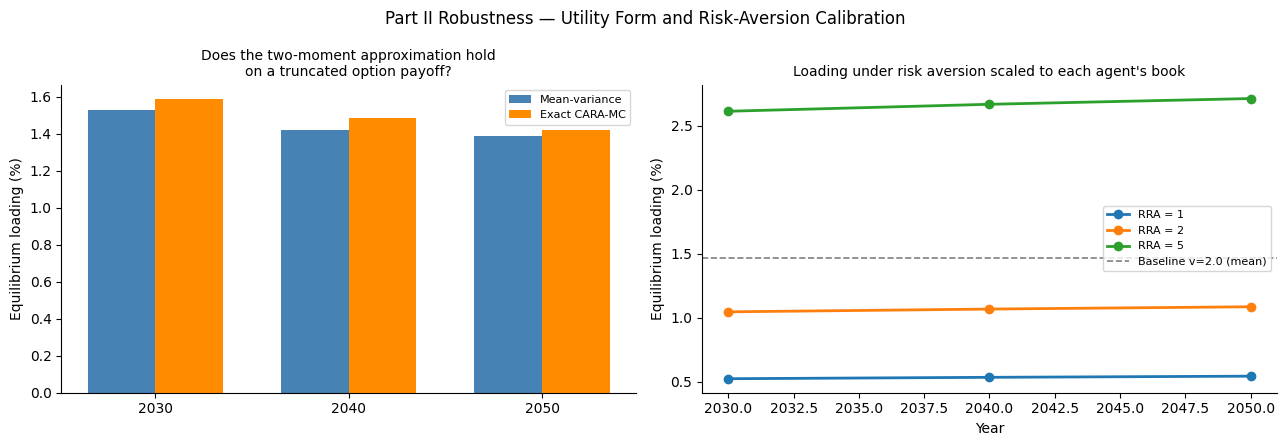

In [33]:
from scipy.optimize import brentq, minimize_scalar
from scipy.special import logsumexp

CARA_YEARS = TARGET_YEARS
RRA_GRID   = [1.0, 2.0, 5.0]


def cara_ce(alpha, endowment, gamma, v, w0, b1=B1):
    """Exact CARA certainty equivalent, evaluated on the simulated paths.

    CE = -(1/v)·ln E[exp(-v·(I + alpha·(Gamma - B1·W0)))]
    No distributional assumption — this is the sample mean of the actual payoffs.
    """
    x = endowment + alpha * (gamma - b1 * w0)
    n = x.size
    return -(1.0 / v) * (logsumexp(-v * x) - np.log(n))


def cara_optimal_alpha(endowment, gamma, v, w0, b1=B1, bound=50.0):
    """Alpha maximising the CARA CE (concave in alpha)."""
    res = minimize_scalar(lambda a: -cara_ce(a, endowment, gamma, v, w0, b1),
                          bounds=(-bound, bound), method="bounded",
                          options={"xatol": 1e-10})
    return float(res.x)


def cara_excess_demand(w0, g, i_spp, i_eso, v_s, v_e, v_mkt, b1=B1):
    """Sum of the three agents' optimal positions; zero at equilibrium.
    The desk has no endowment in Gamma, only the position it takes."""
    z = np.zeros_like(g)
    a_spp = cara_optimal_alpha(i_spp, g, v_s, w0, b1)
    a_eso = cara_optimal_alpha(i_eso, g, v_e, w0, b1)
    a_m = cara_optimal_alpha(z, g, v_mkt, w0, b1)
    return a_spp + a_eso + a_m, a_spp, a_eso, a_m


def solve_cara_equilibrium(ann_year, v_s, v_e, v_mkt, b1=B1):
    """Clear the market numerically under exact CARA utility."""
    g = ann_year["Gamma_I"].to_numpy()
    i_spp = ann_year["I_spp"].to_numpy()
    i_eso = ann_year["I_eso"].to_numpy()
    mu = g.mean()

    def f(w0):
        return cara_excess_demand(w0, g, i_spp, i_eso, v_s, v_e, v_mkt, b1)[0]

    lo, hi = mu / b1 * 0.5 - 1.0, mu / b1 * 1.5 + 1.0
    f_lo, f_hi = f(lo), f(hi)
    if np.sign(f_lo) == np.sign(f_hi):
        return None
    w0 = brentq(f, lo, hi, xtol=1e-12)
    _, a_spp, a_eso, a_m = cara_excess_demand(w0, g, i_spp, i_eso, v_s, v_e, v_mkt, b1)
    ce_unh = cara_ce(0.0, i_spp, g, v_s, w0, b1)
    ce_hed = cara_ce(a_spp, i_spp, g, v_s, w0, b1)
    return {"W0": w0, "alpha_spp": a_spp, "alpha_eso": a_eso, "alpha_m": a_m,
            "HE_spp": ce_hed - ce_unh,
            "loading_pct": (w0 - mu / b1) / mu * 100 if mu > 0 else np.nan}


# ── Comparison 1: mean-variance vs exact CARA, at the baseline v ──────────────
print("── Mean-variance vs exact CARA-MC equilibrium (baseline v = %.2f) ──────" % v_spp)
print(f"{'year':>6}  {'W0 (MV)':>12}  {'W0 (CARA)':>12}  {'diff':>10}  "
      f"{'load MV':>9}  {'load CARA':>10}  {'HE_spp MV':>11}  {'HE_spp CARA':>12}")
print(f"{'-'*6}  {'-'*12}  {'-'*12}  {'-'*10}  {'-'*9}  {'-'*10}  {'-'*11}  {'-'*12}")
cara_rows = []
for y in CARA_YEARS:
    _a = ann[ann["year"] == y]
    _mv = eq[eq["year"] == y].iloc[0]
    _c = solve_cara_equilibrium(_a, v_spp, v_eso, v_m)
    if _c is None:
        print(f"{y:>6}  (no sign change bracketing the root — skipped)")
        continue
    cara_rows.append({"year": y, **_c})
    print(f"{y:>6}  {_mv['W0']*1e6:>12,.0f}  {_c['W0']*1e6:>12,.0f}  "
          f"{(_c['W0']-_mv['W0'])*1e6:>+10,.0f}  {_mv['loading_pct']:>8.3f}%  "
          f"{_c['loading_pct']:>9.3f}%  {_mv['HE_spp']*1e6:>11,.0f}  {_c['HE_spp']*1e6:>12,.0f}")

cara_df = pd.DataFrame(cara_rows)
print("\nIf these agree, the two-moment approximation is safe here despite the")
print("non-normal payoff, and Part II is bulletproofed. If they diverge, the")
print("mean-variance result is an artefact of discarding the skew the project")
print("deliberately modelled.")

# ── Comparison 2: risk aversion scaled to each agent's own book ───────────────
print("\n── Calibrated risk aversion  v_i = RRA / E[I_i] ────────────────────────")
print(f"{'RRA':>5}  {'year':>6}  {'v_spp':>9}  {'v_eso':>9}  {'loading %':>10}  "
      f"{'HE_spp (EUR)':>14}  {'HE % of rev':>12}")
print(f"{'-'*5}  {'-'*6}  {'-'*9}  {'-'*9}  {'-'*10}  {'-'*14}  {'-'*12}")
calib_rows = []
for rra in RRA_GRID:
    for y in CARA_YEARS:
        _row = mom[mom["year"] == y].iloc[0]
        _vs = rra / _row["mu_I_spp"]
        _ve = rra / _row["mu_I_eso"] if _row["mu_I_eso"] > 0 else _vs
        _vm = rra / (_row["mu_I_spp"] + _row["mu_I_eso"])
        _h = 1 / _vs + 1 / _ve + 1 / _vm
        _eqc = block3_equilibrium(mom[mom["year"] == y], v_s=_vs, v_e=_ve,
                                  v_mkt=_vm, h=_h).iloc[0]
        calib_rows.append({"RRA": rra, "year": y, "v_spp": _vs, "v_eso": _ve,
                           "loading_pct": _eqc["loading_pct"], "HE_spp": _eqc["HE_spp"],
                           "HE_pct_rev": _eqc["HE_spp"] / _row["mu_I_spp"] * 100})
        print(f"{rra:>5.0f}  {y:>6}  {_vs:>9.4f}  {_ve:>9.4f}  "
              f"{_eqc['loading_pct']:>9.3f}%  {_eqc['HE_spp']*1e6:>14,.0f}  "
              f"{_eqc['HE_spp']/_row['mu_I_spp']*100:>11.3f}%")

calib_df = pd.DataFrame(calib_rows)
print(f"\nBaseline for comparison: v = {v_spp} (same for all agents), "
      f"HE_spp max {eq['HE_spp'].max()*1e6:,.0f} EUR/yr")
print("Scaling v to each agent's own book makes the ESO — an order of magnitude")
print("smaller than the SPP — appropriately more risk averse in ABSOLUTE terms,")
print("which reduces its capacity to absorb the position and raises the loading.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
if len(cara_df):
    _x = np.arange(len(cara_df))
    _w = 0.35
    ax.bar(_x - _w/2, [eq.loc[eq["year"] == y, "loading_pct"].iloc[0] for y in cara_df["year"]],
           _w, label="Mean-variance", color="steelblue")
    ax.bar(_x + _w/2, cara_df["loading_pct"], _w, label="Exact CARA-MC", color="darkorange")
    ax.set_xticks(_x); ax.set_xticklabels(cara_df["year"].astype(int))
    ax.set_ylabel("Equilibrium loading (%)")
    ax.set_title("Does the two-moment approximation hold\non a truncated option payoff?", fontsize=10)
    ax.legend(fontsize=8)

ax = axes[1]
for rra in RRA_GRID:
    s = calib_df[calib_df["RRA"] == rra]
    ax.plot(s["year"], s["loading_pct"], marker="o", lw=2, label=f"RRA = {rra:.0f}")
ax.axhline(eq["loading_pct"].mean(), color="grey", ls="--", lw=1.2,
           label=f"Baseline v={v_spp} (mean)")
ax.set_xlabel("Year"); ax.set_ylabel("Equilibrium loading (%)")
ax.set_title("Loading under risk aversion scaled to each agent's book", fontsize=10)
ax.legend(fontsize=8)

fig.suptitle("Part II Robustness — Utility Form and Risk-Aversion Calibration")
sns.despine(); plt.tight_layout(); plt.show()


> **Takeaway.** The CARA and mean-variance equilibrium prices agree closely across the tested risk-aversion grid, so the mean-variance shortcut used elsewhere in Part II is not distorting the price by an amount that matters here.

### Block 4 — Sensitivity Analysis & Visualisation

One-at-a-time sensitivity over three parameters, all others fixed at baseline:

| Parameter | Baseline | Range swept |
|---|---|---|
| `v_spp` (SPP risk aversion, M€⁻¹) | 2.0 | [0.5, 1.0, 2.0, 4.0] |
| `BATTERY_SOLAR_RATIO` (storage scale) | 0.20 | [0.05, 0.10, 0.20, 0.40, 0.60] |
| `eta_rt` (round-trip efficiency) | 0.88 | [0.80, 0.88, 0.95] |

Storage is swept as the ratio, not an absolute MWh figure -- the absolute figure
is meaningless without the plant size it is measured against (see Block 3c). The
ratio grid deliberately runs up to 0.60, past the sign-flip threshold where the
battery is a large enough natural seller that the equilibrium loading turns
negative.

When ESO or η changes, Block 1 and Block 2 are recomputed because I_eso changes.
When only `v_spp` changes, the moments from Block 2 can be reused — but the
aggregate inverse risk aversion `h = 1/v_spp + 1/v_eso + 1/v_m` must still be
recomputed, since `W0` depends on `v_spp` only through `h`.

Direction: higher `v_spp` shrinks `h` and therefore **raises** the loading.

In [34]:
def block4_sensitivity(mom, cr_monthly, n_mwh_by_month, premium_mc):
    # Grids centred on the actual baseline (v_spp=2.0, BATTERY_SOLAR_RATIO=0.20),
    # each one bracketing that baseline per assert_brackets below -- a grid that
    # does not would sweep a parameter region the model no longer occupies.
    #
    # Storage is swept as the RATIO, not an absolute MWh figure: the absolute
    # figure is meaningless without the plant size (see Part II, block 3's confound
    # note), and the ratio is what the equilibrium loading actually depends on.
    # 0.60 deliberately crosses the sign-flip threshold (loading turns negative
    # once the battery is a large enough natural seller -- see Block 3c / the
    # ratio surface below for where that threshold sits per year).
    grid = {
        "v_spp_sweep":   {"v_spp":               [0.5, 1.0, 2.0, 4.0]},
        "ratio_sweep":   {"BATTERY_SOLAR_RATIO":  [0.05, 0.10, 0.20, 0.40, 0.60]},
        "eta_sweep":     {"eta_rt":               [0.80, 0.88, 0.95]},
    }
    assert_brackets("v_spp_sweep",   grid["v_spp_sweep"]["v_spp"],               v_spp)
    assert_brackets("ratio_sweep",   grid["ratio_sweep"]["BATTERY_SOLAR_RATIO"], BATTERY_SOLAR_RATIO)
    assert_brackets("eta_sweep",     grid["eta_sweep"]["eta_rt"],                eta_rt)

    # Moments only depend on (ESO_MWh_month, eta_rt); the baseline point is
    # already solved (`mom`), so seed the cache with it rather than recomputing.
    _moments_cache = {(ESO_MWh_month, eta_rt): mom}

    def _moments_for(eso_mwh, eta):
        key = (round(eso_mwh, 6), round(eta, 6))
        if key not in _moments_cache:
            ann_s = block1_annual_series(cr_monthly, n_mwh_by_month, ri_sim=ri_sim,
                                         strike=fwd_strike, eso_mwh=eso_mwh, eta=eta)
            _moments_cache[key] = block2_moments(ann_s, premium_mc, n_mwh_by_month)
        return _moments_cache[key]

    records = []
    for sweep_name, params in grid.items():
        param_name = list(params.keys())[0]
        for val in list(params.values())[0]:
            if param_name == "BATTERY_SOLAR_RATIO":
                eso_mwh = val * PLANT_MW * CYCLES
                mom_s   = _moments_for(eso_mwh, eta_rt)
            elif param_name == "eta_rt":
                eso_mwh = ESO_MWh_month
                mom_s   = _moments_for(eso_mwh, val)
            else:
                eso_mwh = ESO_MWh_month
                mom_s   = mom.copy()   # v_spp only affects Block 3

            vs   = val if param_name == "v_spp" else v_spp
            # h MUST be recomputed from the swept v_spp — leaving it at the
            # module-level H made W0 invariant to this entire sweep.
            eq_s = block3_equilibrium(mom_s, v_s=vs,
                                      h=1 / vs + 1 / v_eso + 1 / v_m)

            for _, row in eq_s.iterrows():
                records.append({"sweep": sweep_name, param_name: val,
                                 "ESO_MWh_month": eso_mwh,
                                 "year": row["year"], "W0": row["W0"],
                                 "loading_pct": row["loading_pct"]})
    return pd.DataFrame(records)


sens = block4_sensitivity(mom, cr_monthly, n_mwh_by_month, premium_mc)
print(f"Sensitivity grid: {sens.shape}  sweeps × years")

C:\Users\LucasMonero\AppData\Local\Temp\ipykernel_51764\2136973039.py:43: UserWarning: 13/25 years have loading_pct < 0 (economically implausible negative risk premium; min=-0.39%). Two distinct causes: at BASELINE this is Monte Carlo noise flipping cov_spp_W1 marginally positive in early low-penetration years (see the tolerance note in the Block 2 sanity checks); in the Block 4 sweeps it is genuine — high ESO storage volumes raise cov_eso_W1 until it outweighs SPP hedging demand.
  warnings.warn(


Sensitivity grid: (300, 8)  sweeps × years


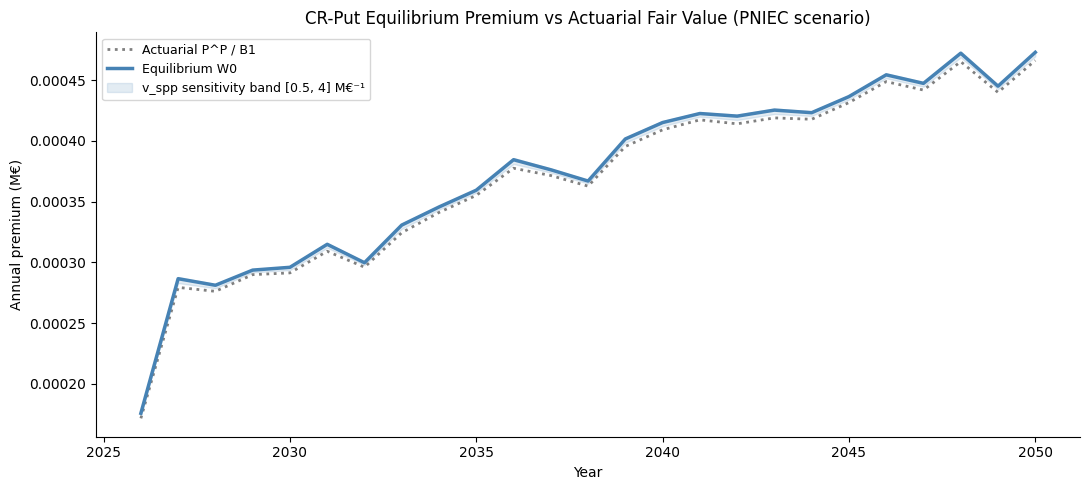

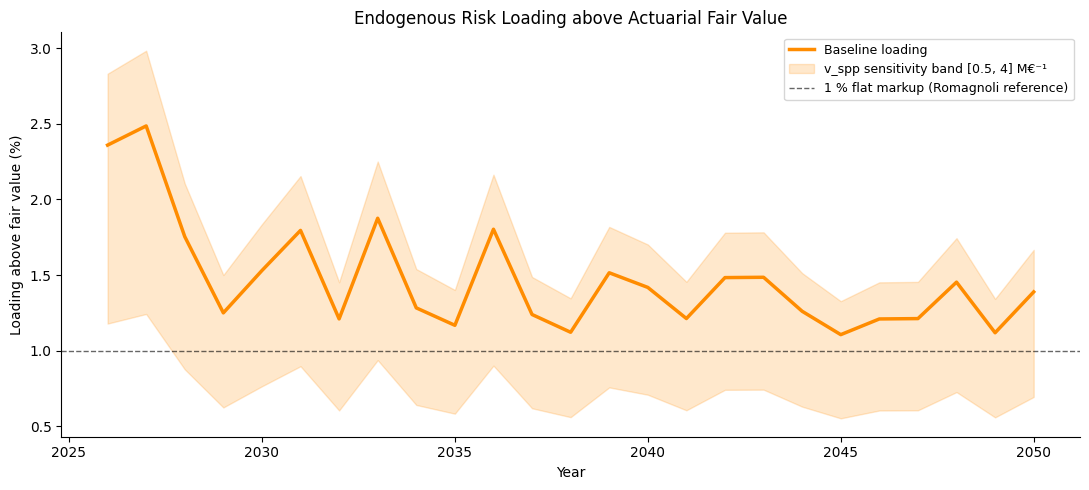

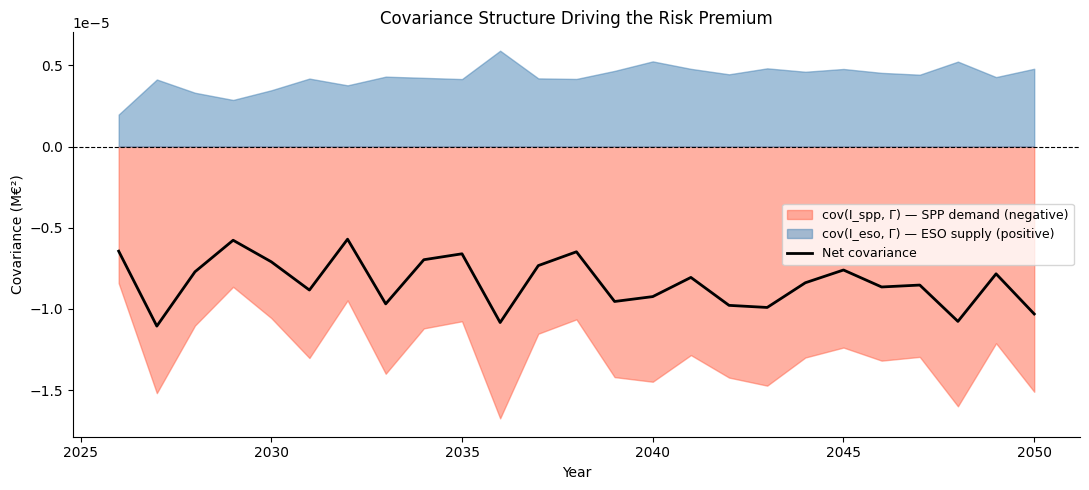

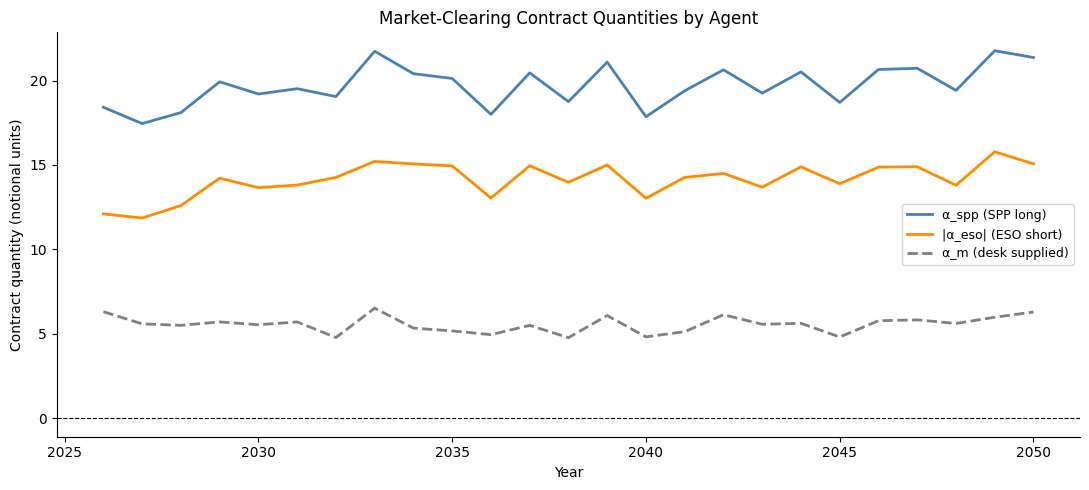

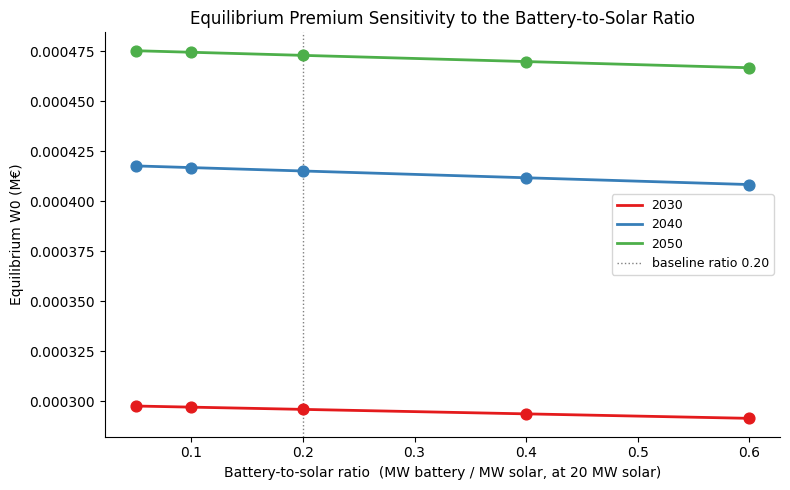

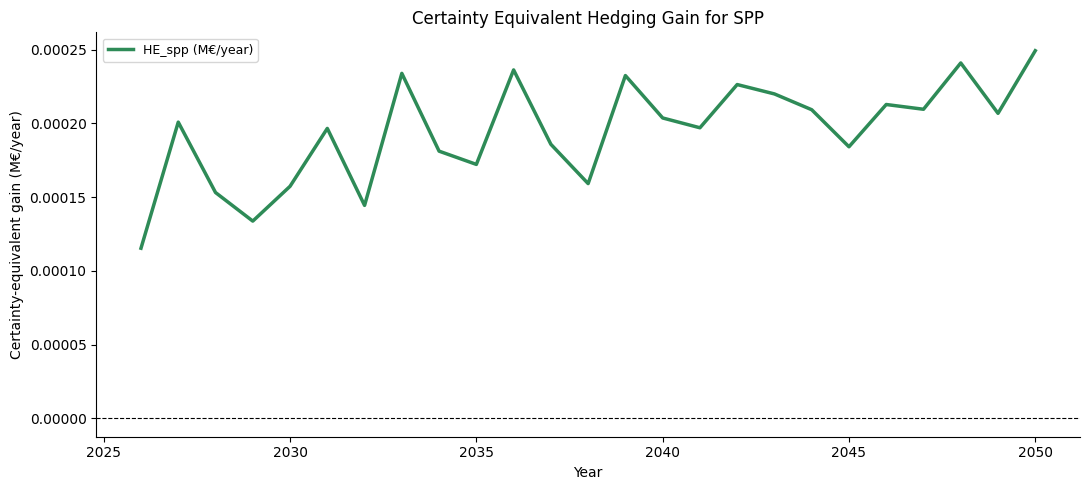

In [35]:
TARGET_YEARS_EQ = TARGET_YEARS   # no duplicate literal -- see the data-loading cell
colors_yr = {2030: "#e41a1c", 2040: "#377eb8", 2050: "#4daf4a"}


def sweep_band(sens, sweep):
    """Lowest and highest arm of a sweep, read from the frame itself -- never a
    hardcoded parameter value. Filtering on literal values (e.g. 0.01/0.1) would
    silently return an EMPTY frame the moment the grid is re-centred elsewhere,
    and the band would vanish from the figure without any error.
    Returns (lb, ub, lo, hi)."""
    s = sens[sens["sweep"] == sweep]
    assert len(s), f"sweep {sweep!r} not found in sens -- grid renamed?"
    param = [c for c in s.columns if c not in ("sweep", "ESO_MWh_month", "year", "W0", "loading_pct")][0]
    lo, hi = s[param].min(), s[param].max()
    lb = s[s[param] == lo].sort_values("year")
    ub = s[s[param] == hi].sort_values("year")
    n_y = s["year"].nunique()
    assert len(lb) == len(ub) == n_y, f"{sweep}: ragged band ({len(lb)}/{len(ub)}/{n_y})"
    return lb, ub, lo, hi


# Direction: loading = -(cov_spp + cov_eso) / (h·B1·mu_W1) and h = 1/v_spp + 1/v_eso + 1/v_m,
# so a HIGHER v_spp shrinks h and therefore RAISES the loading.
lb_vspp, ub_vspp, _lo_vspp, _hi_vspp = sweep_band(sens, "v_spp_sweep")
_band_lbl_vspp = f"v_spp sensitivity band [{_lo_vspp:g}, {_hi_vspp:g}] M€⁻¹"

# ── Plot 1: Equilibrium premium trajectory 2026–2050 ─────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(eq["year"], eq["mu_W1"] / B1, color="grey", lw=2, linestyle=":",
        label="Actuarial P^P / B1")
ax.plot(eq["year"], eq["W0"], color="steelblue", lw=2.5, label="Equilibrium W0")
ax.fill_between(lb_vspp["year"], lb_vspp["W0"], ub_vspp["W0"],
                alpha=0.15, color="steelblue", label=_band_lbl_vspp)
ax.set_xlabel("Year"); ax.set_ylabel("Annual premium (M€)")
ax.set_title("CR-Put Equilibrium Premium vs Actuarial Fair Value (PNIEC scenario)")
ax.legend(fontsize=9); sns.despine(); plt.tight_layout(); plt.show()

# ── Plot 2: Risk loading over time ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(eq["year"], eq["loading_pct"], color="darkorange", lw=2.5, label="Baseline loading")
ax.fill_between(lb_vspp["year"], lb_vspp["loading_pct"], ub_vspp["loading_pct"],
                alpha=0.2, color="darkorange", label=_band_lbl_vspp)
ax.axhline(1.0, color="black", lw=1, linestyle="--", alpha=0.6,
           label="1 % flat markup (Romagnoli reference)")
ax.set_xlabel("Year"); ax.set_ylabel("Loading above fair value (%)")
ax.set_title("Endogenous Risk Loading above Actuarial Fair Value")
ax.legend(fontsize=9); sns.despine(); plt.tight_layout(); plt.show()

# ── Plot 3: Covariance decomposition ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(eq["year"], 0, eq["cov_spp_W1"],
                alpha=0.5, color="tomato",    label="cov(I_spp, Γ) — SPP demand (negative)")
ax.fill_between(eq["year"], 0, eq["cov_eso_W1"],
                alpha=0.5, color="steelblue", label="cov(I_eso, Γ) — ESO supply (positive)")
ax.plot(eq["year"], eq["cov_spp_W1"] + eq["cov_eso_W1"],
        color="black", lw=2, label="Net covariance")
ax.axhline(0, color="black", lw=0.8, linestyle="--")
ax.set_xlabel("Year"); ax.set_ylabel("Covariance (M€²)")
ax.set_title("Covariance Structure Driving the Risk Premium")
ax.legend(fontsize=9); sns.despine(); plt.tight_layout(); plt.show()

# ── Plot 4: Market-clearing contract quantities ───────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(eq["year"], eq["alpha_spp"],       color="steelblue",  lw=2, label="α_spp (SPP long)")
ax.plot(eq["year"], eq["alpha_eso"].abs(), color="darkorange", lw=2, label="|α_eso| (ESO short)")
ax.plot(eq["year"], eq["alpha_m"],         color="grey",  lw=2, linestyle="--",
        label="α_m (desk supplied)")
ax.axhline(0, color="black", lw=0.8, linestyle="--")
ax.set_xlabel("Year"); ax.set_ylabel("Contract quantity (notional units)")
ax.set_title("Market-Clearing Contract Quantities by Agent")
ax.legend(fontsize=9); sns.despine(); plt.tight_layout(); plt.show()

# ── Plot 5: battery-to-solar ratio sensitivity on W0 ──────────────────────────
# Ratio, not absolute ESO_MWh_month: the ratio is the structural driver (see
# Part II, block 3 / the ratio surface below), and the absolute figure only makes sense
# alongside the plant size it was swept at (PLANT_MW, held fixed here).
fig, ax = plt.subplots(figsize=(8, 5))
for y in TARGET_YEARS_EQ:
    sub = (sens[(sens["sweep"] == "ratio_sweep") & (sens["year"] == y)]
           .sort_values("BATTERY_SOLAR_RATIO"))
    ax.plot(sub["BATTERY_SOLAR_RATIO"], sub["W0"], color=colors_yr[y], lw=2, label=str(y))
    ax.scatter(sub["BATTERY_SOLAR_RATIO"], sub["W0"], color=colors_yr[y], s=60, zorder=5)
ax.axvline(BATTERY_SOLAR_RATIO, color="grey", lw=1, ls=":",
           label=f"baseline ratio {BATTERY_SOLAR_RATIO:.2f}")
ax.set_xlabel(f"Battery-to-solar ratio  (MW battery / MW solar, at {PLANT_MW} MW solar)")
ax.set_ylabel("Equilibrium W0 (M€)")
ax.set_title("Equilibrium Premium Sensitivity to the Battery-to-Solar Ratio")
ax.legend(fontsize=9); sns.despine(); plt.tight_layout(); plt.show()

# ── Plot 6: Certainty-equivalent hedging gain for SPP ────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(eq["year"], eq["HE_spp"], color="seagreen", lw=2.5, label="HE_spp (M€/year)")
ax.axhline(0, color="black", lw=0.8, linestyle="--")
ax.set_xlabel("Year"); ax.set_ylabel("Certainty-equivalent gain (M€/year)")
ax.set_title("Certainty Equivalent Hedging Gain for SPP")
ax.legend(fontsize=9); sns.despine(); plt.tight_layout(); plt.show()

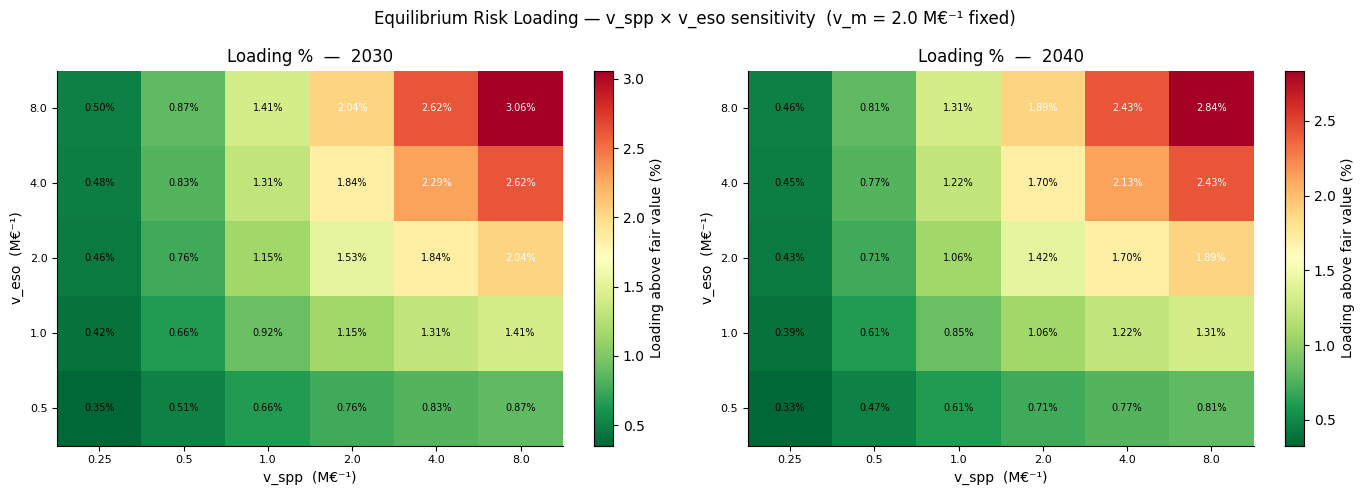

C:\Users\LucasMonero\AppData\Local\Temp\ipykernel_51764\462385071.py:113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


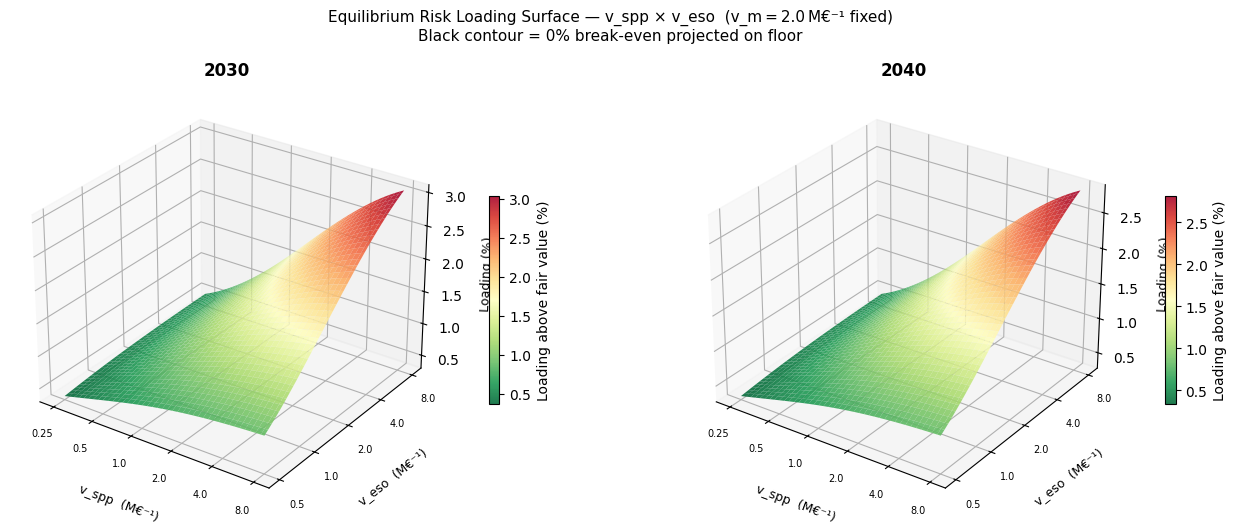

In [36]:
# ── Plot 7: 2D sensitivity — v_spp × v_eso  for 2030 and 2040 ────────────────
# Centred on the baseline v_spp=v_eso=2.0, so the grid brackets the operating
# point the model is actually evaluated at rather than a near-risk-neutral
# region far below it.
v_spp_grid = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
v_eso_grid = [0.5, 1.0, 2.0, 4.0, 8.0]
assert_brackets("v_spp_grid", v_spp_grid, v_spp)
assert_brackets("v_eso_grid", v_eso_grid, v_eso)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y in zip(axes, [2030, 2040]):
    grid_data = np.zeros((len(v_eso_grid), len(v_spp_grid)))

    for i, ve in enumerate(v_eso_grid):
        for j, vs in enumerate(v_spp_grid):
            h_local = 1/vs + 1/ve + 1/v_m   # recompute H for this (vs, ve) pair
            eq_tmp  = block3_equilibrium(mom, v_s=vs, v_e=ve, h=h_local)
            grid_data[i, j] = eq_tmp.loc[eq_tmp["year"] == y, "loading_pct"].iloc[0]

    im = ax.imshow(grid_data, aspect="auto", cmap="RdYlGn_r", origin="lower",
                   vmin=grid_data.min(), vmax=grid_data.max())

    ax.set_xticks(range(len(v_spp_grid)))
    ax.set_xticklabels([str(v) for v in v_spp_grid], fontsize=8)
    ax.set_yticks(range(len(v_eso_grid)))
    ax.set_yticklabels([str(v) for v in v_eso_grid], fontsize=8)
    ax.set_xlabel("v_spp  (M€⁻¹)")
    ax.set_ylabel("v_eso  (M€⁻¹)")
    ax.set_title(f"Loading %  —  {y}")

    # annotate every cell with its loading value
    for i in range(len(v_eso_grid)):
        for j in range(len(v_spp_grid)):
            val = grid_data[i, j]
            txt_color = "white" if abs(val) > 0.6 * grid_data.max() else "black"
            ax.text(j, i, f"{val:.2f}%", ha="center", va="center",
                    fontsize=7, color=txt_color)

    plt.colorbar(im, ax=ax, label="Loading above fair value (%)")

fig.suptitle(
    f"Equilibrium Risk Loading — v_spp × v_eso sensitivity  "
    f"(v_m = {v_m} M€⁻¹ fixed)"
)
sns.despine()
plt.tight_layout()
plt.show()

# ── Plot 7b: 3D surface — v_spp x v_eso -> loading ───────────────────────────
# Interpolate the 5x6 grid in log space for a smooth surface.
# Z-axis: equilibrium loading above fair value (%).

from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import RectBivariateSpline

vs_arr = np.array(v_spp_grid)   # shape (6,)
ve_arr = np.array(v_eso_grid)   # shape (5,)

# log10 coordinates for spline (better spacing than linear for these ranges)
log_vs = np.log10(vs_arr)
log_ve = np.log10(ve_arr)
log_vs_fine = np.linspace(log_vs.min(), log_vs.max(), 120)
log_ve_fine = np.linspace(log_ve.min(), log_ve.max(), 120)
VS_log, VE_log = np.meshgrid(log_vs_fine, log_ve_fine)  # for plotting coords

fig3d, axes3d = plt.subplots(1, 2, figsize=(16, 6),
                              subplot_kw={"projection": "3d"})

for ax3, y in zip(axes3d, [2030, 2040]):
    # rebuild loading grid for this year
    Z = np.zeros((len(ve_arr), len(vs_arr)))
    for ii, ve in enumerate(ve_arr):
        for jj, vs in enumerate(vs_arr):
            h_local = 1/vs + 1/ve + 1/v_m
            eq_tmp  = block3_equilibrium(mom, v_s=vs, v_e=ve, h=h_local)
            Z[ii, jj] = eq_tmp.loc[eq_tmp["year"] == y, "loading_pct"].iloc[0]

    spline = RectBivariateSpline(log_ve, log_vs, Z, kx=3, ky=3)
    Z_fine = spline(log_ve_fine, log_vs_fine)   # shape (120, 120)

    surf = ax3.plot_surface(VS_log, VE_log, Z_fine,
                            cmap="RdYlGn_r", alpha=0.88,
                            linewidth=0, antialiased=True)

    # project zero-loading contour onto the floor
    z_floor = Z_fine.min() - 0.5
    ax3.contour(VS_log, VE_log, Z_fine, levels=[0],
                zdir="z", offset=z_floor,
                colors=["black"], linewidths=1.8)

    # tick labels in original units (not log10)
    ax3.set_xticks(log_vs)
    ax3.set_xticklabels([str(v) for v in vs_arr], fontsize=7)
    ax3.set_yticks(log_ve)
    ax3.set_yticklabels([str(v) for v in ve_arr], fontsize=7)

    ax3.set_xlabel("v_spp  (M€⁻¹)", fontsize=9, labelpad=10)
    ax3.set_ylabel("v_eso  (M€⁻¹)", fontsize=9, labelpad=10)
    ax3.set_zlabel("Loading (%)", fontsize=9, labelpad=6)
    ax3.set_title(str(y), fontsize=12, fontweight="bold")
    ax3.view_init(elev=28, azim=-55)

    fig3d.colorbar(surf, ax=ax3, shrink=0.45, pad=0.08,
                   label="Loading above fair value (%)")

fig3d.suptitle(
    f"Equilibrium Risk Loading Surface — v_spp × v_eso  "
    f"(v_m = {v_m} M€⁻¹ fixed)\n"
    "Black contour = 0% break-even projected on floor",
    fontsize=11
)
plt.tight_layout()
plt.show()


> **Takeaway.** The equilibrium loading responds to both risk-aversion parameters, and the 2030 and 2040 surfaces share the same qualitative shape -- the sign and rough magnitude of the sensitivity are stable across the horizon.

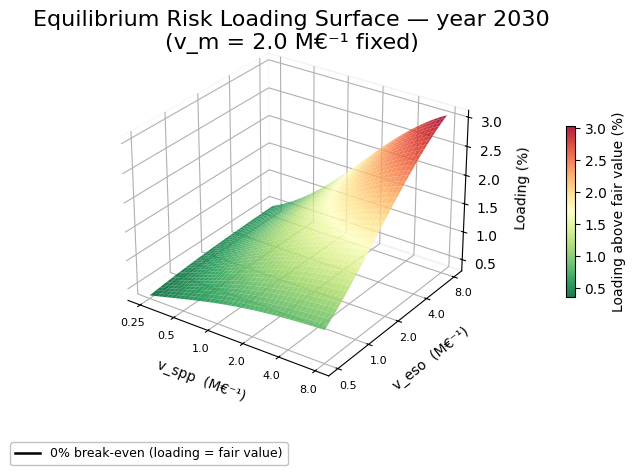

In [37]:
# -- Standalone: 3D Risk Loading Surface -- year 2030 --
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import RectBivariateSpline

YEAR_3D = 2030

vs_arr = np.array(v_spp_grid)
ve_arr = np.array(v_eso_grid)

log_vs = np.log10(vs_arr)
log_ve = np.log10(ve_arr)
log_vs_fine = np.linspace(log_vs.min(), log_vs.max(), 120)
log_ve_fine = np.linspace(log_ve.min(), log_ve.max(), 120)
VS_log, VE_log = np.meshgrid(log_vs_fine, log_ve_fine)

fig3d = plt.figure(figsize=(12, 5))
ax3   = fig3d.add_subplot(111, projection="3d")

Z = np.zeros((len(ve_arr), len(vs_arr)))
for ii, ve in enumerate(ve_arr):
    for jj, vs in enumerate(vs_arr):
        h_local = 1/vs + 1/ve + 1/v_m
        eq_tmp  = block3_equilibrium(mom, v_s=vs, v_e=ve, h=h_local)
        Z[ii, jj] = eq_tmp.loc[eq_tmp["year"] == YEAR_3D, "loading_pct"].iloc[0]

spline = RectBivariateSpline(log_ve, log_vs, Z, kx=3, ky=3)
Z_fine = spline(log_ve_fine, log_vs_fine)

surf = ax3.plot_surface(VS_log, VE_log, Z_fine,
                        cmap="RdYlGn_r", alpha=0.88,
                        linewidth=0, antialiased=True)

z_floor = Z_fine.min() - 0.5
ax3.contour(VS_log, VE_log, Z_fine, levels=[0],
            zdir="z", offset=z_floor,
            colors=["black"], linewidths=1.8)

ax3.set_xticks(log_vs)
ax3.set_xticklabels([str(v) for v in vs_arr], fontsize=8)
ax3.set_yticks(log_ve)
ax3.set_yticklabels([str(v) for v in ve_arr], fontsize=8)

ax3.set_xlabel("v_spp  (M€⁻¹)", fontsize=10, labelpad=2)
ax3.set_ylabel("v_eso  (M€⁻¹)", fontsize=10, labelpad=2)
ax3.set_zlabel("Loading (%)", fontsize=10, labelpad=4)
ax3.tick_params(axis="x", pad=-1)
ax3.tick_params(axis="y", pad=-1)
ax3.tick_params(axis="z", pad=2)
ax3.set_title(
    f"Equilibrium Risk Loading Surface — year {YEAR_3D}\n"
    f"(v_m = {v_m} M€⁻¹ fixed)",
    fontsize=16, pad=2, y=1
)
ax3.view_init(elev=28, azim=-55)

fig3d.colorbar(surf, ax=ax3, shrink=0.45, pad=0.08,
               label="Loading above fair value (%)")

# 3D surface/contour artists don't register with ax.legend() the way 2D lines
# do -- a proxy Line2D stands in for the black break-even contour, which
# otherwise has no explanation of what it is anywhere on the figure.
from matplotlib.lines import Line2D
_legend_handles = [
    Line2D([0], [0], color="black", lw=1.8, label="0% break-even (loading = fair value)"),
]
fig3d.legend(handles=_legend_handles, loc="lower center",
            bbox_to_anchor=(0.42, 0.0), fontsize=9, frameon=True,
            facecolor="white", edgecolor="0.7", ncol=1)

fig3d.patch.set_facecolor("white")
ax3.set_facecolor("white")
ax3.xaxis.pane.set_facecolor("white")
ax3.yaxis.pane.set_facecolor("white")
ax3.zaxis.pane.set_facecolor("white")

# tight_layout() does not support 3D axes reliably (it was warning "left and
# right margins cannot be made large enough to accommodate all Axes
# decorations" and silently clipping the y/z labels) -- fixed margins instead,
# with room on the left/bottom for the now-closer axis labels and on the right
# for the colorbar.
fig3d.subplots_adjust(left=0.02, right=0.90, top=0.90, bottom=0.14)
plt.show()

> **Takeaway.** The 3D surface makes the same v_spp/v_eso sensitivity from the 2D heatmap visually explicit: the loading is monotonic in both risk-aversion parameters over the grid shown.

C:\Users\LucasMonero\AppData\Local\Temp\ipykernel_51764\2136973039.py:43: UserWarning: 24/25 years have loading_pct < 0 (economically implausible negative risk premium; min=-0.30%). Two distinct causes: at BASELINE this is Monte Carlo noise flipping cov_spp_W1 marginally positive in early low-penetration years (see the tolerance note in the Block 2 sanity checks); in the Block 4 sweeps it is genuine — high ESO storage volumes raise cov_eso_W1 until it outweighs SPP hedging demand.
  warnings.warn(


C:\Users\LucasMonero\AppData\Local\Temp\ipykernel_51764\2136973039.py:43: UserWarning: 24/25 years have loading_pct < 0 (economically implausible negative risk premium; min=-0.59%). Two distinct causes: at BASELINE this is Monte Carlo noise flipping cov_spp_W1 marginally positive in early low-penetration years (see the tolerance note in the Block 2 sanity checks); in the Block 4 sweeps it is genuine — high ESO storage volumes raise cov_eso_W1 until it outweighs SPP hedging demand.
  warnings.warn(
C:\Users\LucasMonero\AppData\Local\Temp\ipykernel_51764\2136973039.py:43: UserWarning: 24/25 years have loading_pct < 0 (economically implausible negative risk premium; min=-1.19%). Two distinct causes: at BASELINE this is Monte Carlo noise flipping cov_spp_W1 marginally positive in early low-penetration years (see the tolerance note in the Block 2 sanity checks); in the Block 4 sweeps it is genuine — high ESO storage volumes raise cov_eso_W1 until it outweighs SPP hedging demand.
  warnings.

C:\Users\LucasMonero\AppData\Local\Temp\ipykernel_51764\2136973039.py:43: UserWarning: 24/25 years have loading_pct < 0 (economically implausible negative risk premium; min=-2.97%). Two distinct causes: at BASELINE this is Monte Carlo noise flipping cov_spp_W1 marginally positive in early low-penetration years (see the tolerance note in the Block 2 sanity checks); in the Block 4 sweeps it is genuine — high ESO storage volumes raise cov_eso_W1 until it outweighs SPP hedging demand.
  warnings.warn(


C:\Users\LucasMonero\AppData\Local\Temp\ipykernel_51764\2136973039.py:43: UserWarning: 24/25 years have loading_pct < 0 (economically implausible negative risk premium; min=-5.94%). Two distinct causes: at BASELINE this is Monte Carlo noise flipping cov_spp_W1 marginally positive in early low-penetration years (see the tolerance note in the Block 2 sanity checks); in the Block 4 sweeps it is genuine — high ESO storage volumes raise cov_eso_W1 until it outweighs SPP hedging demand.
  warnings.warn(


C:\Users\LucasMonero\AppData\Local\Temp\ipykernel_51764\2600694632.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


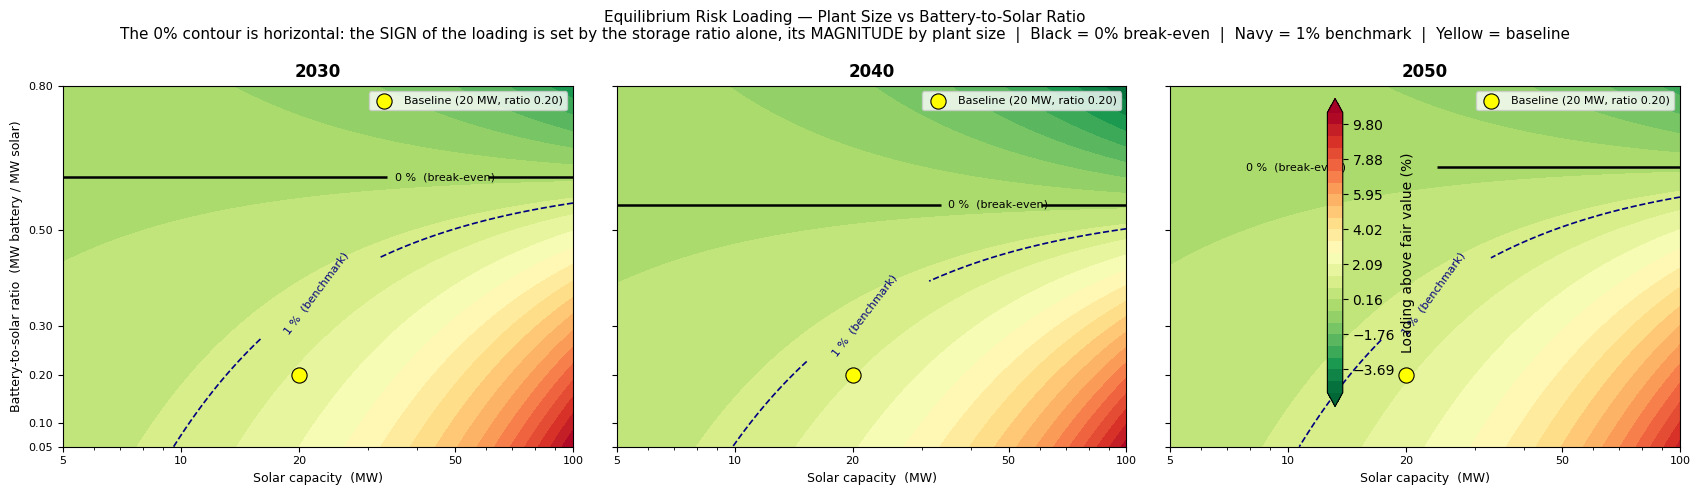

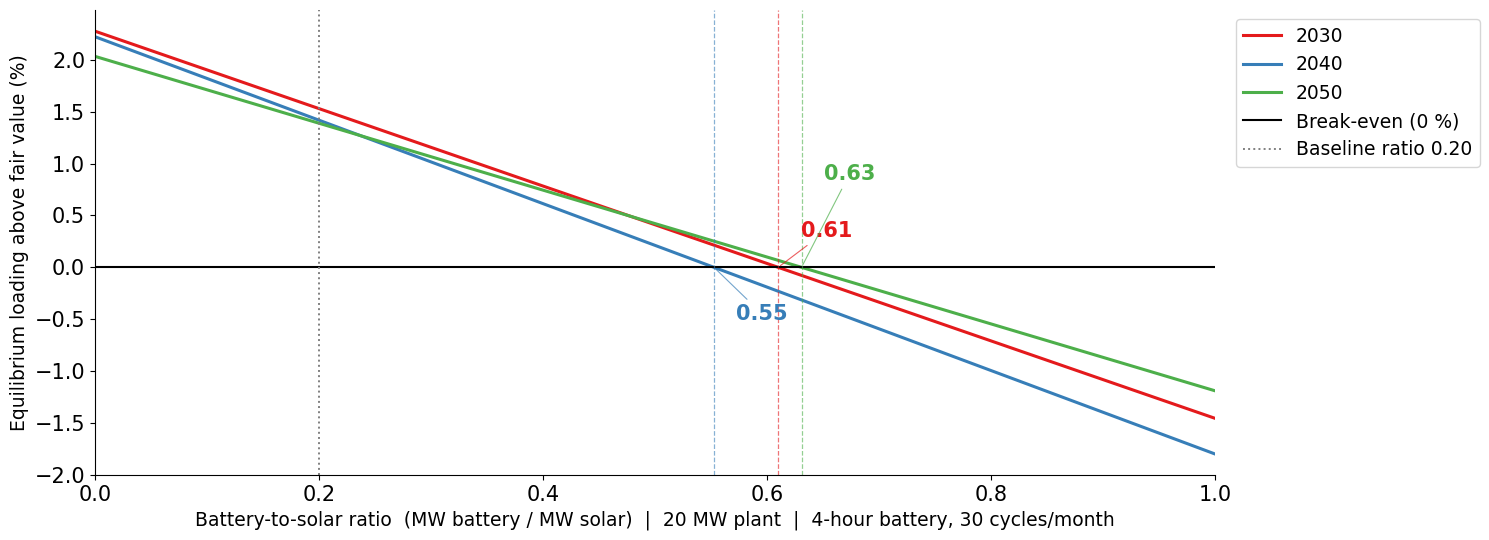

In [38]:
# ── Grid, re-axed to solar MW x battery-to-solar ratio ────────────────────────
#
# loading is proportional to -lam*(cov_spp + (r/r0)*cov_eso), where lam=nm/PLANT_MW
# and r0=BATTERY_SOLAR_RATIO: the SIGN of the loading depends only on the ratio r,
# the MAGNITUDE only on plant size lam. Absolute (MW, MWh) axes confound the two
# (a diagonal 0% contour reads as "size AND storage matter", which is exactly the
# confound Part II, block 3 documents and this ratio parameterisation exists to remove) --
# on (solar MW, ratio) axes the 0% contour comes out horizontal, which IS the
# structural result, drawn rather than asserted.
#
# The baseline is injected into both grids by set-union, so it is ALWAYS a node
# and the reference lookup in contour-2030-standalone can never miss.
from scipy.interpolate import RectBivariateSpline

solar_grid = sorted({5, 10, PLANT_MW, 50, 100})
ratio_grid = sorted({0.05, 0.10, BATTERY_SOLAR_RATIO, 0.30, 0.50, 0.80})
assert_brackets("solar_grid", solar_grid, PLANT_MW)
assert_brackets("ratio_grid", ratio_grid, BATTERY_SOLAR_RATIO)

BASE_MW    = PLANT_MW               # `mom` is measured at this plant size
BASE_RATIO = BATTERY_SOLAR_RATIO    # ...and this battery-to-solar ratio
BASE_ESO   = ESO_MWh_month
TARGET_PLOT_YEARS = TARGET_YEARS
colors_yr = {2030: "#e41a1c", 2040: "#377eb8", 2050: "#4daf4a"}

# analytical moment scaling — no Block 1 re-run needed
records_ratio = []
for nm in solar_grid:
    lam = nm / BASE_MW
    for r in ratio_grid:
        eso = r * nm * CYCLES
        mu  = eso / BASE_ESO        # == (r / BASE_RATIO) * lam
        scaled = mom.copy()
        scaled["mu_W1"]             *= lam
        scaled["sigma2_W1"]         *= lam ** 2
        scaled["cov_spp_W1"]        *= lam ** 2
        # Gamma scales with lam (contract notional) and I_eso with mu (storage
        # volume), so cov(I_eso, Gamma) scales with lam*mu — not mu alone.
        scaled["cov_eso_W1"]        *= lam * mu
        scaled["mu_I_spp"]          *= lam
        scaled["sigma2_I_spp"]      *= lam ** 2
        scaled["mu_I_eso"]          *= mu
        scaled["sigma2_I_eso"]      *= mu ** 2
        scaled["premium_mc_annual"] *= lam
        eq_tmp = block3_equilibrium(scaled, h=1/v_spp + 1/v_eso + 1/v_m)
        for y in TARGET_PLOT_YEARS:
            row = one_row(eq_tmp, year=y)
            records_ratio.append({
                "solar_mw": nm, "ratio": r, "eso_mwh": eso, "year": y,
                "loading_pct": row["loading_pct"],
            })
ratio_df = pd.DataFrame(records_ratio)
assert len(ratio_df) == len(solar_grid) * len(ratio_grid) * len(TARGET_PLOT_YEARS)

# ── Plot A — 2D interpolated contour map ──────────────────────────────────────
nm_arr = np.array(solar_grid, dtype=float)
r_arr  = np.array(ratio_grid, dtype=float)

nm_fine = np.logspace(np.log10(nm_arr.min()), np.log10(nm_arr.max()), 200)
r_fine  = np.linspace(r_arr.min(), r_arr.max(), 200)
NM_fine, R_fine = np.meshgrid(nm_fine, r_fine)

z_min = ratio_df["loading_pct"].min()
z_max = ratio_df["loading_pct"].max()
levels = np.linspace(z_min, z_max, 25)

fig1, axes1 = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

for ax, y in zip(axes1, TARGET_PLOT_YEARS):
    Z = (ratio_df[ratio_df["year"] == y]
         .pivot(index="ratio", columns="solar_mw", values="loading_pct")
         .values.astype(float))     # rows=ratio, cols=solar_mw (both ascending)

    spline = RectBivariateSpline(r_arr, nm_arr, Z, kx=3, ky=3)
    Z_fine = spline(r_fine, nm_fine)

    cf = ax.contourf(NM_fine, R_fine, Z_fine, levels=levels,
                     cmap="RdYlGn_r", extend="both")
    cs = ax.contour(NM_fine, R_fine, Z_fine,
                    levels=[0, 1], colors=["black", "navy"],
                    linewidths=[1.8, 1.2], linestyles=["-", "--"])
    ax.clabel(cs, fmt={0: "0 %  (break-even)", 1: "1 %  (benchmark)"},
              fontsize=8, inline=True)

    ax.scatter([PLANT_MW], [BATTERY_SOLAR_RATIO], color="yellow", edgecolors="black",
               s=120, zorder=5, linewidths=0.8,
               label=f"Baseline ({PLANT_MW} MW, ratio {BATTERY_SOLAR_RATIO:.2f})")

    ax.set_xscale("log")
    ax.set_xlabel("Solar capacity  (MW)", fontsize=9)
    ax.set_ylabel("Battery-to-solar ratio  (MW battery / MW solar)" if y == TARGET_PLOT_YEARS[0] else "", fontsize=9)
    ax.set_title(str(y), fontsize=12, fontweight="bold")
    ax.set_xticks(nm_arr); ax.set_xticklabels([str(int(v)) for v in nm_arr], fontsize=8)
    ax.set_yticks(r_arr); ax.set_yticklabels([f"{v:.2f}" for v in r_arr], fontsize=8)
    ax.legend(fontsize=8, loc="upper right")

fig1.colorbar(cf, ax=axes1.ravel().tolist(), label="Loading above fair value (%)",
              shrink=0.8, pad=0.02)
fig1.suptitle(
    "Equilibrium Risk Loading — Plant Size vs Battery-to-Solar Ratio\n"
    "The 0% contour is horizontal: the SIGN of the loading is set by the storage "
    "ratio alone, its MAGNITUDE by plant size  |  Black = 0% break-even  |  "
    "Navy = 1% benchmark  |  Yellow = baseline",
    fontsize=11
)
plt.tight_layout()
plt.show()

# ── Plot B — loading vs battery-to-solar ratio (fixed plant size) ────────────
# Fix solar at PLANT_MW (lam_fixed = 1 -> no scaling of cov_spp / mu_W1), vary the
# ratio r continuously. mu = (r/BASE_RATIO)*lam_fixed = r/BASE_RATIO at lam=1.

lam_fixed = 1.0
r_range   = np.linspace(0.0, 1.0, 600)

fig2, ax2 = plt.subplots(figsize=(15, 5.5))

for y in TARGET_PLOT_YEARS:
    row = one_row(mom, year=y)
    mu_arr  = r_range / BASE_RATIO
    loading = (-(lam_fixed * row["cov_spp_W1"] + mu_arr * row["cov_eso_W1"])
               / (H * B1 * row["mu_W1"])) * 100
    ax2.plot(r_range, loading, color=colors_yr[y], lw=2.2, label=str(y))

ax2.axhline(0, color="black", lw=1.5, linestyle="-", label="Break-even (0 %)")
ax2.axvline(BATTERY_SOLAR_RATIO, color="grey", lw=1.4, linestyle=":",
            label=f"Baseline ratio {BATTERY_SOLAR_RATIO:.2f}")

# break-even ratio per year -- COMPUTED, never a literal. The three r* values
# sit close together in x (~0.50-0.58), so the labels are staggered in y
# instead of x to stay legible rather than overlapping at y=0.
_r_star_y_stagger = [0.35, -0.45, 0.90]
for _i, y in enumerate(TARGET_PLOT_YEARS):
    row = one_row(mom, year=y)
    r_star = BASE_RATIO * (-row["cov_spp_W1"] / row["cov_eso_W1"])
    if 0 < r_star < r_range.max():
        ax2.axvline(r_star, color=colors_yr[y], lw=0.9, linestyle="--", alpha=0.6)
        _ys = _r_star_y_stagger[_i % len(_r_star_y_stagger)]
        ax2.annotate(f"{r_star:.2f}", xy=(r_star, 0), xytext=(r_star + 0.02, _ys),
                     color=colors_yr[y], fontsize=15, fontweight="bold",
                     va="center", ha="left",
                     arrowprops=dict(arrowstyle="-", color=colors_yr[y], lw=0.8, alpha=0.7))

ax2.set_xlabel(
    f"Battery-to-solar ratio  (MW battery / MW solar)  |  "
    f"{PLANT_MW} MW plant  |  {BATTERY_HOURS}-hour battery, {CYCLES_PER_MONTH} cycles/month",
    fontsize=13.5
)
ax2.set_ylabel("Equilibrium loading above fair value (%)", fontsize=13.5)
ax2.set_xlim(0, r_range.max())
ax2.tick_params(axis="both", labelsize=15)
ax2.legend(fontsize=13.5, loc="upper left", bbox_to_anchor=(1.01, 1.0))
sns.despine()
plt.tight_layout()
plt.show()


> **Takeaway.** Re-parameterising storage as a ratio to solar MW rather than an absolute MWh figure produces a sign-flip contour that reads as a genuine size effect, not the confound a fixed-storage sweep would show.

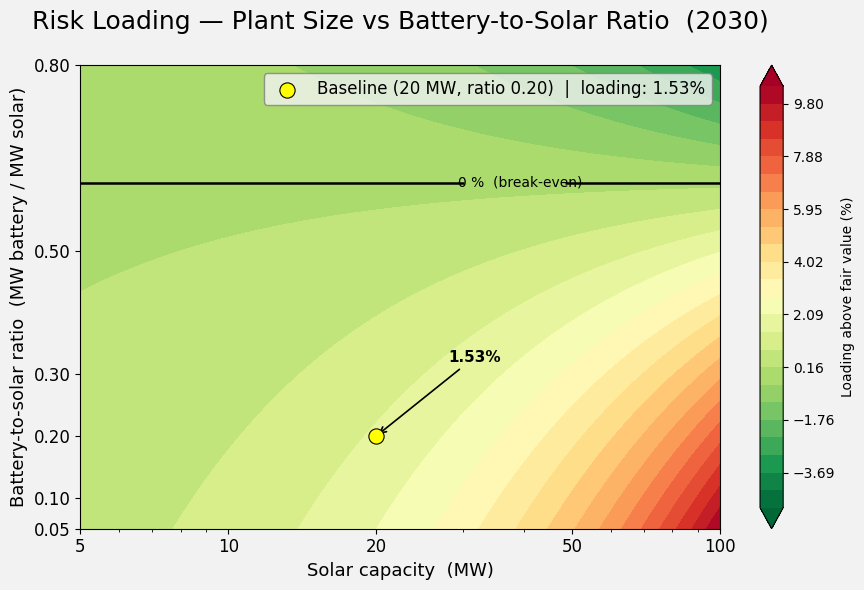

In [39]:
# -- Standalone: 2D contour map — Solar vs Battery-to-Solar Ratio (year 2030) --
# Reuses ratio_df / solar_grid / ratio_grid from the ratio_3d_surface cell above --
# run that cell first.
from scipy.interpolate import RectBivariateSpline

YEAR_SA = 2030

nm_arr = np.array(solar_grid, dtype=float)
r_arr  = np.array(ratio_grid, dtype=float)

nm_fine = np.logspace(np.log10(nm_arr.min()), np.log10(nm_arr.max()), 200)
r_fine  = np.linspace(r_arr.min(), r_arr.max(), 200)
NM_fine, R_fine = np.meshgrid(nm_fine, r_fine)

z_min  = ratio_df["loading_pct"].min()
z_max  = ratio_df["loading_pct"].max()
levels = np.linspace(z_min, z_max, 25)

fig_sa, ax_sa = plt.subplots(figsize=(9, 6))

Z = (ratio_df[ratio_df["year"] == YEAR_SA]
     .pivot(index="ratio", columns="solar_mw", values="loading_pct")
     .values.astype(float))

spline = RectBivariateSpline(r_arr, nm_arr, Z, kx=3, ky=3)
Z_fine = spline(r_fine, nm_fine)

cf = ax_sa.contourf(NM_fine, R_fine, Z_fine, levels=levels,
                    cmap="RdYlGn_r", extend="both")
cs = ax_sa.contour(NM_fine, R_fine, Z_fine,
                   levels=[0], colors=["black"],
                   linewidths=[1.8], linestyles=["-"])
ax_sa.clabel(cs, fmt={0: "0 %  (break-even)"},
             fontsize=10, inline=True)

# one_row raises a named assertion instead of an opaque IndexError if the
# baseline is ever not a node in the grid -- it always is here, by construction
# (solar_grid/ratio_grid are built by set-union with PLANT_MW/BATTERY_SOLAR_RATIO).
base = one_row(ratio_df, solar_mw=PLANT_MW, ratio=float(BATTERY_SOLAR_RATIO), year=YEAR_SA)
base_loading = base["loading_pct"]

ax_sa.scatter([PLANT_MW], [BATTERY_SOLAR_RATIO], color="yellow", edgecolors="black",
              s=120, zorder=5, linewidths=0.8,
              label=f"Baseline ({PLANT_MW} MW, ratio {BATTERY_SOLAR_RATIO:.2f})  |  "
                    f"loading: {base_loading:.2f}%")
ax_sa.annotate(f"{base_loading:.2f}%",
               xy=(PLANT_MW, BATTERY_SOLAR_RATIO),
               xytext=(PLANT_MW * 1.4, BATTERY_SOLAR_RATIO + 0.12),
               fontsize=11, fontweight="bold",
               arrowprops=dict(arrowstyle="->", color="black", lw=1.2))

ax_sa.set_xscale("log")
ax_sa.set_xlabel("Solar capacity  (MW)", fontsize=13)
ax_sa.set_ylabel("Battery-to-solar ratio  (MW battery / MW solar)", fontsize=13)
ax_sa.set_title(
    f"Risk Loading — Plant Size vs Battery-to-Solar Ratio  ({YEAR_SA})\n",
    fontsize=18
)
ax_sa.set_xticks(nm_arr)
ax_sa.set_xticklabels([str(int(v)) for v in nm_arr], fontsize=12)
ax_sa.set_yticks(r_arr)
ax_sa.set_yticklabels([f"{v:.2f}" for v in r_arr], fontsize=12)
ax_sa.legend(fontsize=12, loc="upper right",
             facecolor="#F2F2F2", edgecolor="grey")

fig_sa.colorbar(cf, ax=ax_sa, label="Loading above fair value (%)")

fig_sa.patch.set_facecolor("#F2F2F2")
ax_sa.set_facecolor("#F2F2F2")

plt.tight_layout()
plt.show()


> **Takeaway.** The contour's sign-flip boundary moves with the battery-to-solar ratio, confirming storage capacity relative to plant size, not its absolute quantity, drives whether the loading is positive or negative.

In [40]:
# ── Part II Summary Table (monetary values displayed in EUR) ─────────────────
print("\n── Part II Summary — Lee & Oren Equilibrium Pricing ─────────────────────────────────")
print(f"{'Year':<6} {'Actuarial P^P':>16} {'Equilib. W0':>14} {'Loading %':>10} "
      f"{'alpha_spp':>11} {'HE_spp':>16}")
print("-" * 78)
for y in TARGET_YEARS:
    row = eq[eq["year"] == y].iloc[0]
    print(f"{y:<6} {row['premium_mc_annual']*1e6:>14,.0f} €  "
          f"{row['W0']*1e6:>12,.0f} €  "
          f"{row['loading_pct']:>9.2f}%  "
          f"{row['alpha_spp']:>11.4f}  "
          f"{row['HE_spp']*1e6:>14,.0f} €")


── Part II Summary — Lee & Oren Equilibrium Pricing ─────────────────────────────────
Year      Actuarial P^P    Equilib. W0  Loading %   alpha_spp           HE_spp
------------------------------------------------------------------------------
2030              300 €           296 €       1.53%      19.2015             157 €
2040              422 €           415 €       1.42%      17.8534             204 €
2050              480 €           473 €       1.39%      21.3614             249 €


## Revenue Distribution — Fair vs Equilibrium Premium (2030 & 2040)

Compares three revenue scenarios per year:
- **Unhedged**: no contract, raw RI revenue
- **Hedged — fair premium**: contract priced at `premium_mc` (E[payoff], zero loading)
- **Hedged — equilibrium premium**: contract priced at `W0` (Lee & Oren loading applied)

The equilibrium case shifts the hedged distribution **left** by the risk loading
relative to the fair case. The increment is `W0·B1 − premium_mc` — both on the
undiscounted settlement basis. At the current calibration the loading is only
0.03–2%, so the two hedged curves may be visually near-identical; that is the
honest result, not a plotting failure.
VaR95 dashed lines mark the 5th-percentile outcome for each series.

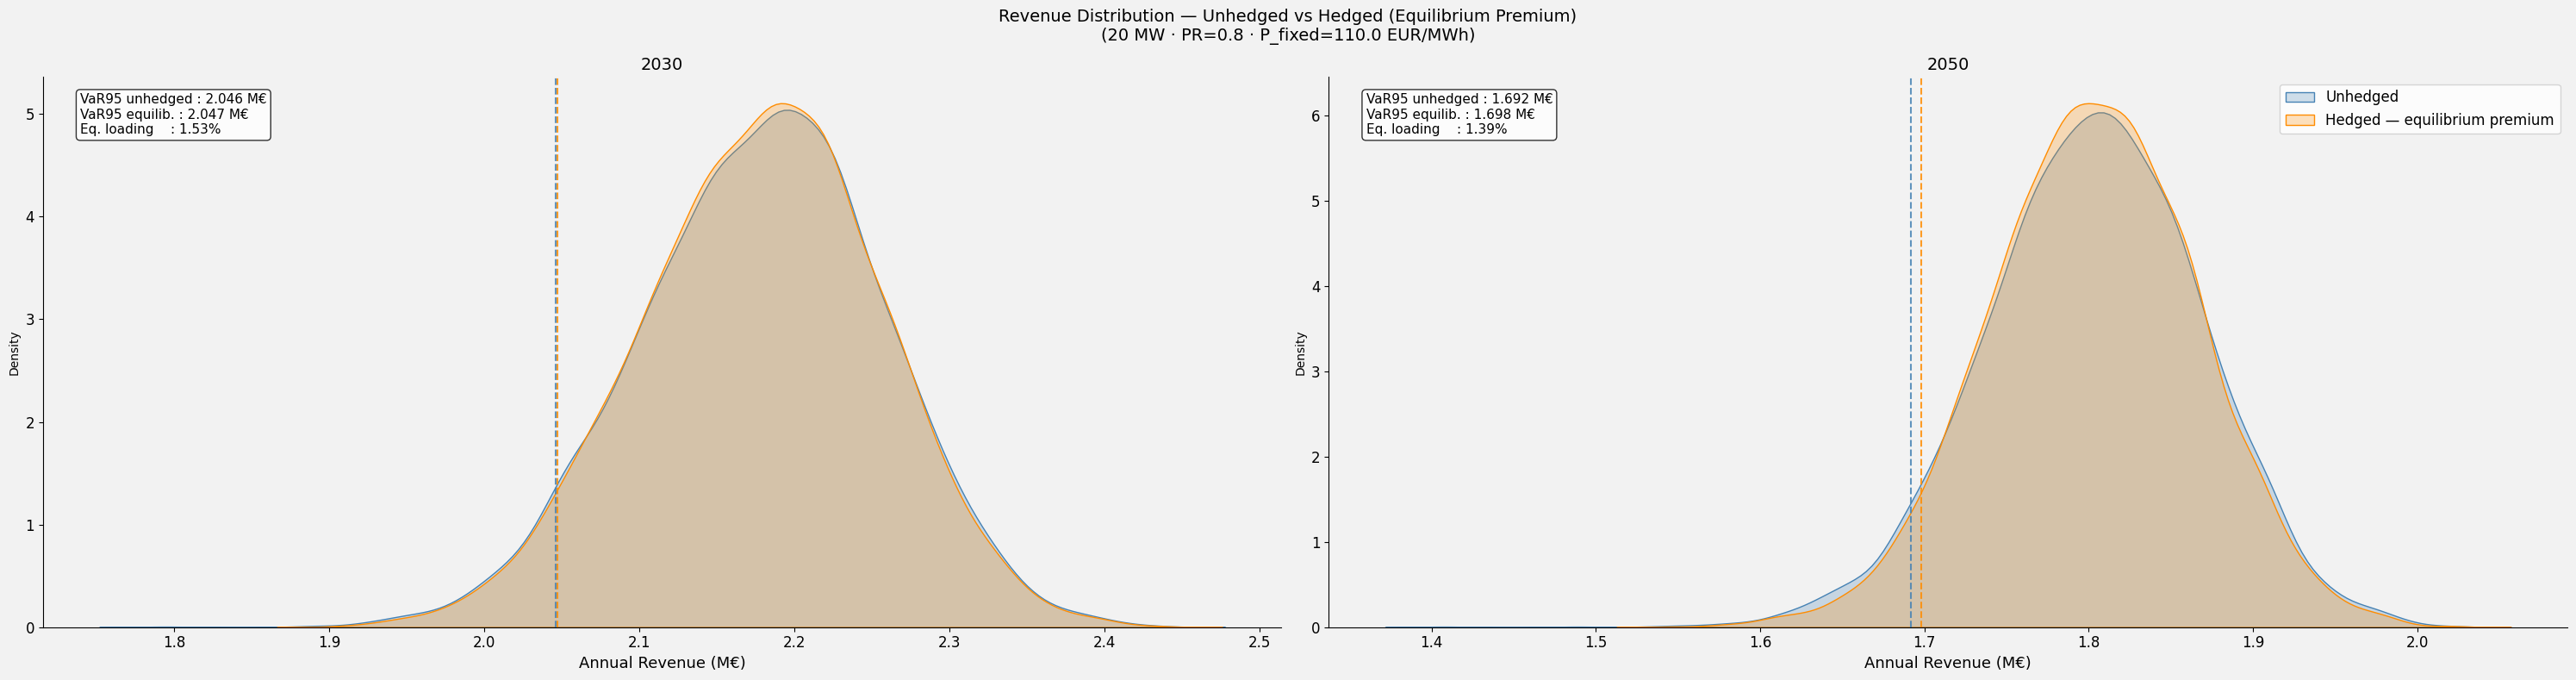

In [41]:
def plot_revenue_distributions_eq(ri_sim, eq, n_mwh_by_month,
                                   years=[2030, 2050], p_fixed=P_FIXED_EUR):
    N_MWh_annual    = n_mwh_by_month["N_MWh"].sum()
    w_CR_annual_EUR = N_MWh_annual * p_fixed

    fig, axes = plt.subplots(1, 2, figsize=(30, 8))

    for ax, y in zip(axes, years):
        sub = ri_sim[ri_sim["year"] == y].copy()

        rev_unh = sub["rev_unhedged_eur"]
        rev_eq  = sub["rev_hedged_eur"] - equilibrium_extra_charge_meur(eq, y)

        var_unh = rm.var_cvar(rev_unh, confidence=0.95)["VaR"]
        var_eq  = rm.var_cvar(rev_eq,  confidence=0.95)["VaR"]

        sns.kdeplot(rev_unh, ax=ax, color="steelblue",  fill=True, alpha=0.25,
                    label="Unhedged")
        sns.kdeplot(rev_eq,  ax=ax, color="darkorange", fill=True, alpha=0.25,
                    label="Hedged — equilibrium premium")

        for val, c in [(var_unh, "steelblue"), (var_eq, "darkorange")]:
            ax.axvline(val, color=c, lw=1.5, linestyle="--", alpha=0.85)

        loading_pct = eq.loc[eq["year"] == y, "loading_pct"].iloc[0]
        ax.text(0.03, 0.97,
                f"VaR95 unhedged : {var_unh:.3f} M€\n"
                f"VaR95 equilib. : {var_eq:.3f} M€\n"
                f"Eq. loading    : {loading_pct:.2f}%",
                transform=ax.transAxes, va="top", fontsize=11,
                bbox=dict(boxstyle="round", fc="white", alpha=0.8))
        ax.set_title(str(y), fontsize=14)
        ax.set_xlabel("Annual Revenue (M€)", fontsize=13)
        ax.tick_params(axis="both", labelsize=12)
        if y != years[0]:
            ax.legend(fontsize=12)
        ax.set_facecolor("#F2F2F2")

    fig.patch.set_facecolor("#F2F2F2")
    fig.suptitle(
        f"Revenue Distribution — Unhedged vs Hedged (Equilibrium Premium)\n"
        f"({PLANT_MW} MW · PR={PR} · P_fixed={P_FIXED_EUR} EUR/MWh)",
        fontsize=14
    )
    sns.despine()
    plt.tight_layout()
    plt.show()


plot_revenue_distributions_eq(ri_sim, eq, n_mwh_by_month)

> **Takeaway.** The fair-premium and equilibrium-priced distributions differ only by a level shift equal to the risk loading -- the shape of the hedged revenue distribution is unaffected by which price the contract is struck at.

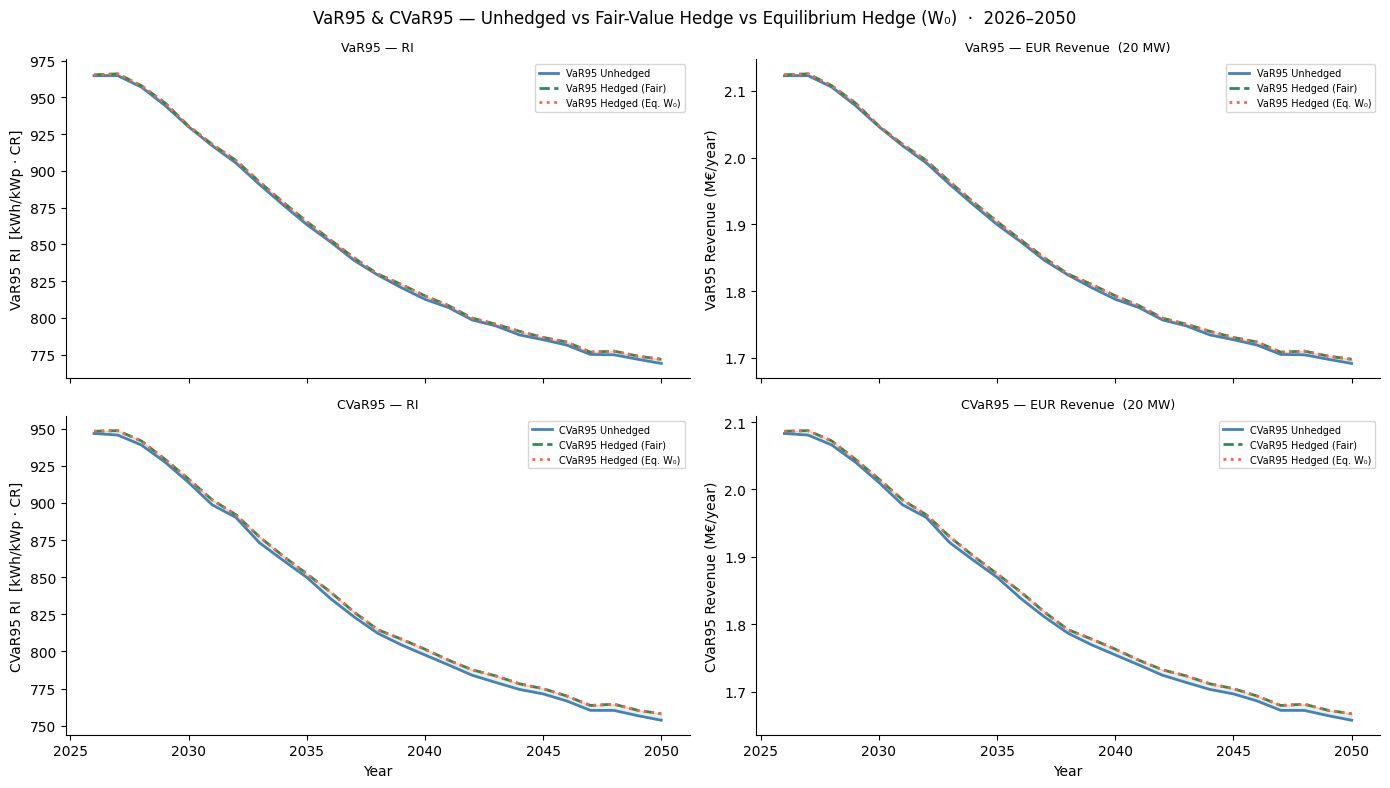

In [42]:
step7c_risk_timeseries_eq(ri_sim, n_mwh_by_month, eq)

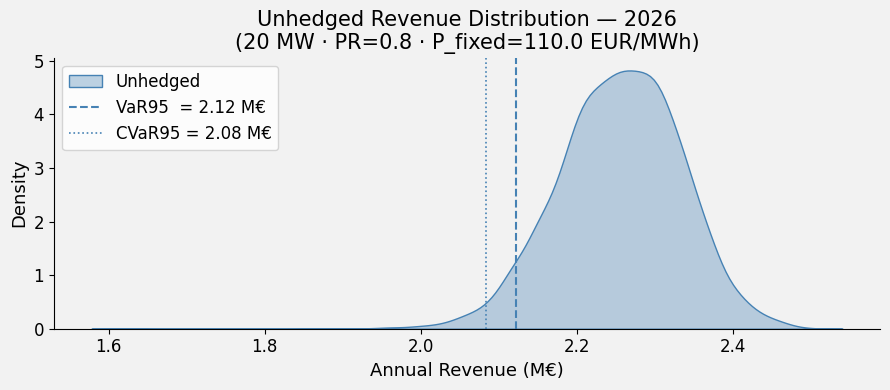

In [43]:
# ── Revenue Distribution 2026 — Unhedged ─────────────────────────────────────
sub = ri_sim[ri_sim["year"] == 2026]
rev_unh = sub["rev_unhedged_eur"]   # M€

_vc    = rm.var_cvar(rev_unh, confidence=0.95)
var95  = _vc["VaR"]
cvar95 = _vc["CVaR"]

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor("#F2F2F2")
ax.set_facecolor("#F2F2F2")

sns.kdeplot(rev_unh, ax=ax, color="steelblue", fill=True, alpha=0.35, label="Unhedged")
ax.axvline(var95,  color="steelblue", lw=1.5, linestyle="--", label=f"VaR95  = {var95:.2f} M€")
ax.axvline(cvar95, color="steelblue", lw=1.2, linestyle=":",  label=f"CVaR95 = {cvar95:.2f} M€")

ax.set_xlabel("Annual Revenue (M€)", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.set_title(f"Unhedged Revenue Distribution — 2026\n({PLANT_MW} MW · PR={PR} · P_fixed={P_FIXED_EUR} EUR/MWh)", fontsize=15)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

> **Takeaway.** The unhedged 2026 revenue distribution is the baseline every hedged comparison in this notebook is measured against; its own VaR95/CVaR95 gap is the tail risk the contract is designed to narrow.

## Conclusion & Handoff

- A monthly capture-rate put with a forward-struck annual strike schedule (D-N2)
  hedges a measurable but modest share of cannibalisation risk. The strike
  schedule is what makes premiums and risk loadings comparable across a 25-year
  horizon; a single strike drifts into the money as the forward declines.
- The seasonal notional (D-N1) dominates the flat one: same annual volume, lower
  premium, slightly higher variance reduction. That comparison is now a reported
  result rather than an assertion.
- The actuarial premium is the zero-risk-aversion limit of the Part II
  equilibrium price, so the gap between them is the risk premium the market
  charges for carrying this exposure.
- Every EUR level rests on a flat 110 EUR/MWh price assumption (D-N3) and scales
  linearly in it. Every ratio metric reported here is invariant to that
  assumption, which is why the conclusions are stated in ratios.

**Artifacts:** `Data/Results/_hedge_checkpoint.pkl` carries the Part I state into Part II and
is validated against a fingerprint of all eight input files, so a changed input
invalidates it rather than being silently reused.

This is the final notebook in the pipeline.